In [2]:
import pandas as pd
import numpy as np
import os
import glob
import re

Total records       : 12278
Valid surface areas : 8372
Min    : 2.43e+02 m²
Max    : 1.54e+09 m²
Median : 8.93e+04 m²
  Top  1% of reservoirs (84) → 58.7% of total surface area
  Top  5% of reservoirs (419) → 86.0% of total surface area
  Top 10% of reservoirs (838) → 93.0% of total surface area
  Reservoirs > 10 km²: 326 (3.9%) → 82.6% of total area


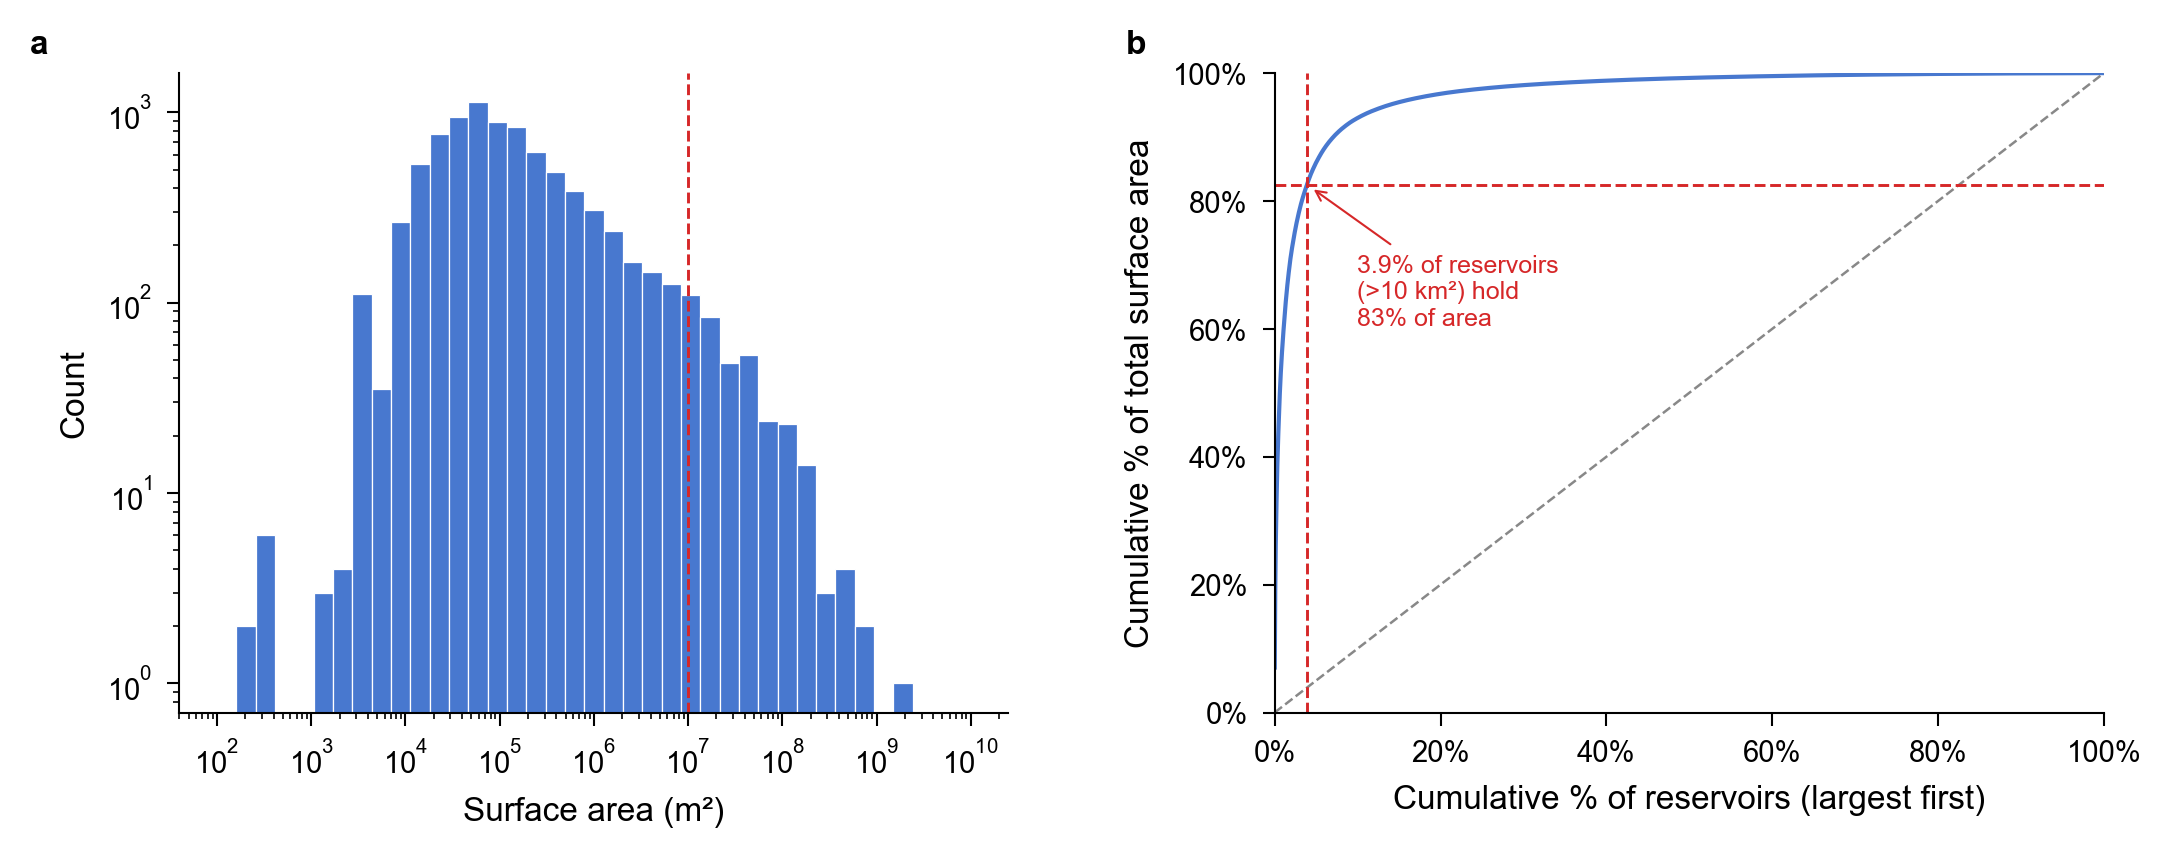


✓ Saved PDF : C:/Users/yzha1253/Desktop/UnitedStatesregion/exports/cleaned_datasets/AHP_result/surface_area_distribution.pdf
✓ Saved PNG : C:/Users/yzha1253/Desktop/UnitedStatesregion/exports/cleaned_datasets/AHP_result/surface_area_distribution.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# ============================================================================
# CONFIGURATION
# ============================================================================

input_file = 'C:/Users/yzha1253/Desktop/UnitedStatesregion/exports/nid_selected.csv'
output_dir = 'C:/Users/yzha1253/Desktop/UnitedStatesregion/exports/cleaned_datasets/AHP_result/'
os.makedirs(output_dir, exist_ok=True)

# ============================================================================
# NATURE JOURNAL STYLE SETTINGS
# Double-column width = 180 mm for two-panel figure
# Font: Arial, 6–8 pt labels, max 9 pt axis titles
# No top/right spines, no grid, 600 DPI for submission
# ============================================================================

plt.rcParams.update({
    'font.family':        'Arial',
    'font.size':          7,
    'axes.labelsize':     8,
    'axes.titlesize':     8,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'xtick.major.size':   3,
    'xtick.minor.size':   1.5,
    'ytick.major.size':   3,
    'ytick.minor.size':   1.5,
    'xtick.major.width':  0.5,
    'ytick.major.width':  0.5,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.linewidth':     0.5,
    'lines.linewidth':    0.75,
    'patch.linewidth':    0.5,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          False,
    'figure.dpi':         300,
    'savefig.dpi':        600,
    'savefig.bbox':       'tight',
})

# ============================================================================
# LOAD DATA
# ============================================================================

df = pd.read_csv(input_file)

sa = df['Surface_Area_square_meters'].dropna()
sa = sa[sa > 0]
sa_sorted = np.sort(sa.values)          # ascending order

print(f"Total records       : {len(df)}")
print(f"Valid surface areas : {len(sa)}")
print(f"Min    : {sa.min():.2e} m²")
print(f"Max    : {sa.max():.2e} m²")
print(f"Median : {sa.median():.2e} m²")

# ── Cumulative area stats ───────────────────────────────────────────────────
total_area   = sa_sorted.sum()
cum_area     = np.cumsum(sa_sorted[::-1])          # largest first
pct_reservoirs = np.arange(1, len(sa_sorted)+1) / len(sa_sorted) * 100
pct_area       = cum_area / total_area * 100

# Find: top X% of reservoirs hold Y% of area
for pct in [1, 5, 10]:
    n_top  = max(1, int(np.ceil(len(sa_sorted) * pct / 100)))
    area_held = sa_sorted[-n_top:].sum() / total_area * 100
    print(f"  Top {pct:2d}% of reservoirs ({n_top:,}) → {area_held:.1f}% of total surface area")

# Threshold: reservoirs > 10 km²
threshold_m2 = 10e6   # 10 km²
n_large      = (sa > threshold_m2).sum()
area_large   = sa[sa > threshold_m2].sum() / total_area * 100
print(f"  Reservoirs > 10 km²: {n_large} ({n_large/len(sa)*100:.1f}%) → {area_large:.1f}% of total area")

# ============================================================================
# TWO-PANEL FIGURE
# Panel a: log–log histogram
# Panel b: cumulative area curve (Lorenz-style)
# ============================================================================

mm  = 1 / 25.4
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(180*mm, 70*mm))

BLUE = '#4878CF'
RED  = '#D62728'
GREY = '#888888'

# ── Panel a: Log–log histogram ──────────────────────────────────────────────
log_min = np.floor(np.log10(sa.min()))
log_max = np.ceil(np.log10(sa.max()))
bins    = np.logspace(log_min, log_max, 40)

ax1.hist(sa, bins=bins, color=BLUE, edgecolor='white', linewidth=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Surface area (m²)')
ax1.set_ylabel('Count')

# Minor ticks on both log axes
ax1.xaxis.set_minor_locator(ticker.LogLocator(subs='all', numticks=10))
ax1.yaxis.set_minor_locator(ticker.LogLocator(subs='all', numticks=10))
ax1.tick_params(which='minor', length=1.5, width=0.4)

# Spine width consistency
for spine in ax1.spines.values():
    spine.set_linewidth(0.5)

# Reference line: 10 km² — drawn AFTER plot so ylim is stable
ax1.axvline(threshold_m2, color=RED, linestyle='--', linewidth=0.7)

# Panel label
ax1.text(-0.18, 1.02, 'a', transform=ax1.transAxes,
         fontsize=8, fontweight='bold', va='bottom', ha='left')

# ── Panel b: Cumulative area curve ──────────────────────────────────────────
pct_large_reservoirs = n_large / len(sa) * 100

ax2.plot(pct_reservoirs, pct_area, color=BLUE, linewidth=1.0)

# Diagonal: equal distribution reference
ax2.plot([0, 100], [0, 100], color=GREY, linestyle='--', linewidth=0.6)

# Red crosshair at 10 km² threshold
ax2.axvline(pct_large_reservoirs, color=RED, linestyle='--', linewidth=0.7)
ax2.axhline(area_large,           color=RED, linestyle='--', linewidth=0.7)

# Annotation — placed to avoid overlapping spines
ax2.annotate(
    f'{pct_large_reservoirs:.1f}% of reservoirs\n(>10 km²) hold\n{area_large:.0f}% of area',
    xy=(pct_large_reservoirs, area_large),
    xytext=(pct_large_reservoirs + 6, max(area_large - 22, 10)),
    fontsize=6,
    color=RED,
    arrowprops=dict(arrowstyle='->', color=RED, lw=0.5),
    bbox=dict(boxstyle='square,pad=0.2', fc='white', ec='none', alpha=0.8),
)

ax2.set_xlabel('Cumulative % of reservoirs (largest first)')
ax2.set_ylabel('Cumulative % of total surface area')
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 100)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(20))

# Add % signs to tick labels
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}%'))

for spine in ax2.spines.values():
    spine.set_linewidth(0.5)

# Panel label
ax2.text(-0.18, 1.02, 'b', transform=ax2.transAxes,
         fontsize=8, fontweight='bold', va='bottom', ha='left')

plt.tight_layout(pad=0.5, w_pad=4.0)

# Save
output_pdf = output_dir + 'surface_area_distribution.pdf'
output_png = output_dir + 'surface_area_distribution.png'
plt.savefig(output_pdf)
plt.savefig(output_png)
plt.show()

print(f"\n✓ Saved PDF : {output_pdf}")
print(f"✓ Saved PNG : {output_png}")

In [4]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Input/Output directories
input_dir = 'C:/Users/yzha1253/Desktop/UnitedStatesregion/exports/cleaned_datasets/'
output_dir = 'C:/Users/yzha1253/Desktop/UnitedStatesregion/exports/cleaned_datasets/AHP_result/'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Define variables for AHP analysis
variables = [
    'Annual_evaporation',
    'Ice_binary', 
    'max_wind_ms',
    'nearest_dist_m',
    'log_Annual_solar_GWh',
    'Capacity_Factor',
    'HAB_flag_20k',
    'Ownership',
    'State_Regulation'
]

# Define variable directions (True = higher is better, False = lower is better)
variable_direction = {
    'Annual_evaporation': True,      # Lower evaporation is worse (less water loss)
    'Ice_binary': False,              # 0 is better (no ice), 1 is worse (ice present)
    'max_wind_ms': False,             # Lower wind is better (easier construction/maintenance)
    'nearest_dist_m': False,          # Closer distance is better (easier access)
    'log_Annual_solar_GWh': True,     # Higher solar potential is better
    'Capacity_Factor': True,          # Higher capacity factor is better
    'HAB_flag_20k': True,             # 1 is better (HAB flag present), 0 is worse
    'Ownership': False,                 # Higher ownership value is worse (Federal=4 is worst)
    'State_Regulation': False
}

# Define binary variables
binary_variables = {
    'Annual_evaporation': False,
    'Ice_binary': True,               # Binary variable (0/1)
    'max_wind_ms': False,
    'nearest_dist_m': False,
    'log_Annual_solar_GWh': False,
    'Capacity_Factor': False,
    'HAB_flag_20k': True,              # Binary variable (0/1)
    'Ownership': False,                # Now numeric (0-10), treated as continuous
    'State_Regulation': False        # Numeric (1-10), treated as continuous
}

In [5]:
# ============================================================================
# STEP 1: LOAD AND INTEGRATE CSV FILES
# ============================================================================

print("\n" + "="*80)
print("STEP 1: LOADING AND INTEGRATING DATA FILES")
print("="*80 + "\n")

# Find all CSV files in input directory
csv_files = glob.glob(os.path.join(input_dir, "*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {input_dir}")

print(f"Found {len(csv_files)} CSV files:\n")

# Load and combine all CSV files
dfs = []
for file_path in csv_files:
    filename = os.path.basename(file_path)
    print(f"  Loading: {filename}")
    
    # Read CSV
    df = pd.read_csv(file_path)
    
    # Add source file column
    df['Source_File'] = filename
    
    dfs.append(df)
    print(f"    Rows: {len(df)}, Columns: {len(df.columns)}")

# Combine all dataframes
df_integrated = pd.concat(dfs, ignore_index=True)

print(f"\n✓ Integration complete")
print(f"  Total dams: {len(df_integrated)}")
print(f"  Total columns: {len(df_integrated.columns)}")

# ============================================================================
# STEP 1.5: CALCULATE OWNERSHIP SCORES
# ============================================================================

print("\n" + "="*80)
print("STEP 1.5: CALCULATING OWNERSHIP SCORES")
print("="*80 + "\n")

def calculate_ownership_score(value):
    """
    Calculate ownership score by summing all ownership types present.
    Range: 0-10
    
    Ownership types:
    - Federal: 5 points
    - State: 4 points
    - Local/Tribe/County/City/Municipal: 3 points
    - Public Utility: 2 point
    - Private: 1 points
    """
    if pd.isna(value):
        return 0
    
    value_str = str(value).lower()
    score = 0
    
    # Check for each ownership type
    if 'federal' in value_str:
        score += 5
    if 'state' in value_str:
        score += 4
    if any(word in value_str for word in ['local', 'tribe', 'tribal', 'county', 'city', 'municipal']):
        score += 3
    if 'public utility' in value_str or 'utility' in value_str:
        score += 2
    if 'private' in value_str:
        score += 1
    
    return min(score, 10)  # Cap at 10

# Preserve original ownership type before scoring
df_integrated['OwnershipType'] = df_integrated['Ownership']
# Apply ownership scoring
df_integrated['Ownership'] = df_integrated['Ownership'].apply(calculate_ownership_score)

print("Ownership score distribution:")
print(df_integrated['Ownership'].value_counts().sort_index())

# ============================================================================
# STEP 1.6: ASSIGN STATE REGULATION SCORES
# ============================================================================

print("\n" + "="*80)
print("STEP 1.6: ASSIGNING STATE REGULATION SCORES")
print("="*80 + "\n")

def assign_state_regulation_score(state):
    """
    Assign state regulation scores (1-10 scale).
    Lower score = more favorable for solar development
    
    NOTE: These are placeholder values. Update with actual regulatory data.
    """
    state_scores = {
        # Western States
        'ARIZONA': 4,
        'CALIFORNIA': 10,      # Strict environmental regs but pro-solar
        'COLORADO': 6,
        'IDAHO': 3,
        'MONTANA': 6,
        'NEVADA': 5,          # Very favorable for solar
        'NEW MEXICO': 4,
        'OREGON': 7,
        'UTAH': 4,
        'WASHINGTON': 8,
        'WYOMING': 5
    }
    
    if pd.isna(state):
        return 5  # Default middle value
    
    state_upper = str(state).upper().strip()
    return state_scores.get(state_upper, 5)  # Default to 5 if state not found

# Check if state column exists
if 'state' in df_integrated.columns:
    df_integrated['State_Regulation'] = df_integrated['state'].apply(assign_state_regulation_score)
    print("✓ State regulation scores assigned from 'state' column")
elif 'State' in df_integrated.columns:
    df_integrated['State_Regulation'] = df_integrated['State'].apply(assign_state_regulation_score)
    print("✓ State regulation scores assigned from 'State' column")
else:
    # If no state column, assign default score
    df_integrated['State_Regulation'] = 5
    print("⚠ No state column found - using default regulation score of 5")

print("\nState regulation score distribution:")
print(df_integrated['State_Regulation'].value_counts().sort_index())


STEP 1: LOADING AND INTEGRATING DATA FILES

Found 5 CSV files:

  Loading: Federal_Top30_Solar_cleaned.csv
    Rows: 30, Columns: 24
  Loading: LocalGov_Top30_Solar_cleaned.csv
    Rows: 29, Columns: 24
  Loading: Private_Top30_Solar_cleaned.csv
    Rows: 30, Columns: 24
  Loading: State_Top30_Solar_cleaned.csv
    Rows: 30, Columns: 24
  Loading: Utility_Top30_Solar_cleaned.csv
    Rows: 30, Columns: 24

✓ Integration complete
  Total dams: 149
  Total columns: 24

STEP 1.5: CALCULATING OWNERSHIP SCORES

Ownership score distribution:
Ownership
1     26
2     29
3     26
4     21
5     24
7      2
8      7
9      4
10    10
Name: count, dtype: int64

STEP 1.6: ASSIGNING STATE REGULATION SCORES

✓ State regulation scores assigned from 'state' column

State regulation score distribution:
State_Regulation
3     13
4     18
5     12
6     24
7     15
8     21
10    46
Name: count, dtype: int64


In [6]:
df_integrated.head(30)

,Name,surfaceArea_sqkm,latitude,longitude,Ownership,Primary Ownership,Annual_solar_potential,Annual_evaporation,Max_ice_depth,max_wind_ms,...,latitude_nid,longitude_nid,Ice_binary,max_wind_cat3,annual_evap_cat3,max_HAB_2020_2024,HAB_flag_20k,Source_File,OwnershipType,State_Regulation
0,Salton Sea,943.305380,33.307836,-115.773593,10,Federal,2192.263091,1.375494,0.000000,10.904522,...,NaN,NaN,0,2,2,409260.66,1,Federal_Top30_Solar_cleaned.csv,"Federal,Public Utility, Tribal",10
1,Hoover Dam,658.424122,36.016300,-114.737400,5,Federal,2120.665031,1.973181,0.000000,10.179908,...,36.016300,-114.737400,0,1,3,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,5
2,Glen Canyon Dam,650.670338,36.937900,-111.484200,5,Federal,2114.608640,1.521972,0.000000,10.296112,...,36.937900,-111.484200,0,1,2,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,4
3,Lake Tahoe Dam,485.623200,39.167100,-120.144000,5,Federal,1984.257138,1.417504,0.395752,9.617186,...,39.167100,-120.144000,1,1,2,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,10
4,Goose Lake,376.551512,41.930007,-120.432735,10,NaN,1874.454918,1.259722,0.732239,12.959312,...,NaN,NaN,1,2,1,1976969.60,1,Federal_Top30_Solar_cleaned.csv,"Federal, Private, State",10
5,Link River Diversion,343.983100,42.233900,-121.801900,5,Federal,1788.603022,1.326484,0.277527,8.628715,...,42.233900,-121.801900,1,1,1,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,7
6,Yellowstone Lake,341.724635,44.420824,-110.536514,5,NaN,1749.663322,1.014855,1.168213,10.207718,...,NaN,NaN,1,1,1,135518.94,1,Federal_Top30_Solar_cleaned.csv,Federal,6
7,Fort Peck Dam,376.357980,48.002228,-106.417987,5,Federal,1579.497244,1.231477,0.835815,18.571770,...,48.002228,-106.417987,1,3,1,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,6
8,Albeni Falls Dam,382.832956,48.179582,-116.999649,5,Federal,1464.479573,1.145577,0.587097,8.182318,...,48.179582,-116.999649,1,1,1,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,3
9,Grand Coulee Dam,333.056578,47.956600,-118.980500,5,Federal,1578.901902,1.216906,0.568542,10.238415,...,47.956600,-118.980500,1,1,1,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,8


In [7]:
# ============================================================================
# STEP 1.7: DETECT DUPLICATE WATER BODIES ACROSS OWNERSHIP FILES
# ============================================================================

print("\n" + "="*80)
print("STEP 1.7: CHECKING FOR DUPLICATE WATER BODIES ACROSS OWNERSHIP FILES")
print("="*80 + "\n")

# Group by Name and collect which source files each site appears in
name_counts = df_integrated.groupby('Name')['Source_File'].apply(list).reset_index()
name_counts.columns = ['Name', 'Source_Files']
name_counts['Occurrences'] = name_counts['Source_Files'].apply(len)

duplicates_by_name = name_counts[name_counts['Occurrences'] > 1].sort_values('Occurrences', ascending=False)

if len(duplicates_by_name) == 0:
    print("  ✓ No duplicate water bodies found — all sites are unique across files.\n")
else:
    print(f"  ⚠ Found {len(duplicates_by_name)} water bodies appearing in multiple ownership files:\n")
    print(f"  {'Name':<45s} {'Count':>5s}  Source Files")
    print("  " + "-"*90)
    for _, row in duplicates_by_name.iterrows():
        files_str = ", ".join([f.replace('_Top30_Solar_cleaned.csv', '') for f in row['Source_Files']])
        print(f"  {row['Name']:<45s} {row['Occurrences']:>5d}  {files_str}")

# Flag duplicates in df_integrated
all_dupe_names = set(duplicates_by_name['Name'].tolist())
df_integrated['Is_Duplicate'] = df_integrated['Name'].isin(all_dupe_names)

n_dupe_rows  = df_integrated['Is_Duplicate'].sum()
n_dupe_sites = df_integrated[df_integrated['Is_Duplicate']]['Name'].nunique()

print(f"\n  Unique water bodies with duplicates : {n_dupe_sites}")
print(f"  Total rows flagged                  : {n_dupe_rows}")
print(f"  Clean rows                          : {len(df_integrated) - n_dupe_rows}")

# ============================================================================
# STEP 1.8: MERGE OWNERSHIP SCORES FOR DUPLICATES, THEN DEDUPLICATE
# ============================================================================

print("\n" + "="*80)
print("STEP 1.8: MERGING OWNERSHIP SCORES + DEDUPLICATING")
print("="*80 + "\n")

# 1. Sum ownership scores across all rows of the same site, cap at 10
ownership_merged = (
    df_integrated
    .groupby('Name')['Ownership']
    .sum()
    .clip(upper=10)
    .reset_index()
    .rename(columns={'Ownership': 'Ownership_merged'})
)

# 2. Keep one row per site (alphabetical Source_File as deterministic tie-break)
df_deduped = (
    df_integrated
    .sort_values('Source_File')
    .drop_duplicates(subset='Name', keep='first')
    .reset_index(drop=True)
)

# 3. Patch in the merged (summed) ownership score
df_deduped = df_deduped.merge(ownership_merged, on='Name', how='left')
df_deduped['Ownership'] = df_deduped['Ownership_merged']
df_deduped.drop(columns=['Ownership_merged'], inplace=True)

print(f"  Rows before : {len(df_integrated)}")
print(f"  Rows after  : {len(df_deduped)}")
print(f"  Removed     : {len(df_integrated) - len(df_deduped)}")
print()

# Show ownership change for duplicate sites
if n_dupe_sites > 0:
    print("  Ownership score after merging (duplicate sites only):\n")
    print(f"  {'Name':<45s} {'Old scores':>15s}  {'Merged':>8s}")
    print("  " + "-"*72)
    for name in sorted(all_dupe_names):
        old_rows  = df_integrated[df_integrated['Name'] == name]['Ownership'].tolist()
        new_score = df_deduped[df_deduped['Name'] == name]['Ownership'].values[0]
        old_str   = " + ".join(str(int(o)) for o in old_rows)
        print(f"  {name:<45s} {old_str:>15s}  {int(new_score):>8d}")
    print()

# 4. Replace df_integrated so all downstream steps work unchanged
df_integrated = df_deduped.copy()

print("  ✓ df_integrated replaced with deduplicated dataset.")
print("  ✓ Ownership scores correctly merged (summed, capped at 10).")
print("  ✓ Ready to continue with Step 2 onwards.")
print("\n" + "="*80)
print("✓ Steps 1.7–1.8 complete")
print("="*80)


STEP 1.7: CHECKING FOR DUPLICATE WATER BODIES ACROSS OWNERSHIP FILES

  ⚠ Found 8 water bodies appearing in multiple ownership files:

  Name                                          Count  Source Files
  ------------------------------------------------------------------------------------------
  Goose Lake                                        3  Federal, State, Utility
  Honey Lake                                        3  Federal, State, Utility
  Lake Washington                                   3  LocalGov, State, Utility
  Coeur d'Alene Lake                                2  State, Utility
  Franklin D Roosevelt Lake                         2  Federal, State
  Lake Elsinore                                     2  LocalGov, State
  Mono Lake                                         2  Federal, State
  Salton Sea                                        2  Federal, Private

  Unique water bodies with duplicates : 8
  Total rows flagged                  : 19
  Clean rows              

In [8]:
df_integrated.head(30)

,Name,surfaceArea_sqkm,latitude,longitude,Ownership,Primary Ownership,Annual_solar_potential,Annual_evaporation,Max_ice_depth,max_wind_ms,...,longitude_nid,Ice_binary,max_wind_cat3,annual_evap_cat3,max_HAB_2020_2024,HAB_flag_20k,Source_File,OwnershipType,State_Regulation,Is_Duplicate
0,Salton Sea,943.305380,33.307836,-115.773593,10,Federal,2192.263091,1.375494,0.000000,10.904522,...,NaN,0,2,2,409260.66,1,Federal_Top30_Solar_cleaned.csv,"Federal,Public Utility, Tribal",10,True
1,O'Sullivan Dam,112.502708,46.982000,-119.290800,5,Federal,1642.061938,1.515578,0.415710,11.342196,...,-119.290800,1,2,2,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,8,False
2,Cascade Dam,112.098022,44.525300,-116.050800,5,Federal,1720.390116,1.160504,0.918823,7.390229,...,-116.050800,1,1,1,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,3,False
3,Malheur Lake,113.192704,43.318786,-118.798305,5,NaN,1786.674104,1.399711,0.518433,15.557846,...,NaN,1,3,2,3435579.20,1,Federal_Top30_Solar_cleaned.csv,Federal,7,False
4,Shasta Dam,122.255641,40.718600,-122.419200,5,Federal,1836.660338,1.803098,0.000000,6.628800,...,-122.419200,0,1,3,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,10,False
5,Canyon Ferry Dam,139.353624,46.648600,-111.728100,5,Federal,1626.135467,1.077666,0.949158,9.551592,...,-111.728100,1,1,1,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,6,False
6,Davis Dam,114.121452,35.195900,-114.570000,5,Federal,2157.808782,2.045213,0.000000,10.609680,...,-114.570000,0,1,3,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,4,False
7,Walker Lake,120.008459,38.695250,-118.718045,8,NaN,2072.421987,1.453963,0.000000,7.508865,...,NaN,0,1,2,2754228.80,1,Federal_Top30_Solar_cleaned.csv,"Federal, Tribe",5,False
8,McNary Lock and Dam,157.018168,45.936037,-119.297768,5,Federal,1653.659449,1.475641,0.052856,12.481229,...,-119.297768,1,2,2,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,7,False
9,Lake Abert,150.290000,42.622959,-120.232297,5,NaN,1833.424143,1.305548,0.655273,11.656658,...,NaN,1,2,1,1380384.20,1,Federal_Top30_Solar_cleaned.csv,Federal,7,False


In [9]:
# ============================================================================
# WEIGHT DETERMINATION: LOAD FROM EXCEL PAIRWISE COMPARISON MATRIX
# ============================================================================

print("\n" + "="*80)
print("CONFIGURATION: AHP WEIGHTS")
print("="*80 + "\n")

# Path to pairwise comparison Excel file
pairwise_excel_path = "C:/Users/yzha1253/Desktop/UnitedStatesregion/exports/cleaned_datasets/scale/CF438420.xlsx"

# Set use_pairwise_comparison = True to derive weights from Excel pairwise comparisons                
# Set use_pairwise_comparison = False to use manually assigned weights below
use_pairwise_comparison = True

if use_pairwise_comparison:
    print("DERIVING AHP WEIGHTS FROM EXCEL PAIRWISE COMPARISON MATRIX")
    print("="*80 + "\n")
    
    try:
        # Load pairwise comparison matrix from Excel
        print(f"Loading pairwise comparisons from: {pairwise_excel_path}\n")
        
        # Check which sheets are available
        xls = pd.ExcelFile(pairwise_excel_path)
        print(f"Available sheets in Excel file: {xls.sheet_names}\n")
        
        # Read the pairwise comparison matrix
        # Try first sheet
        sheet_name = xls.sheet_names[0]
        print(f"Reading from sheet: '{sheet_name}'\n")
        
        df_pairwise = pd.read_excel(pairwise_excel_path, sheet_name=sheet_name, index_col=0)
        
        print(f"Loaded pairwise comparison matrix shape: {df_pairwise.shape}")
        print(f"Columns: {df_pairwise.columns.tolist()}")
        print(f"Index: {df_pairwise.index.tolist()}\n")
        
        print("Matrix preview:")
        print(df_pairwise.head())
        print("\n" + "="*80 + "\n")
        
        # Map Excel criterion names to variable names in your script
        criterion_mapping = {
            # Excel name -> Script variable name
            'Solar Radiation': 'log_Annual_solar_GWh',
            
            'Water body Evaporation': 'Annual_evaporation',

            
            'Ice Issue': 'Ice_binary',
            
            'Wind Load': 'max_wind_ms',

            
            'Distance to Transmission Line': 'nearest_dist_m',

            
            'Solar Capacity': 'Capacity_Factor',

            
            'Algae Issue': 'HAB_flag_20k',
            
            'Water Body Ownership': 'Ownership',
            
            'State': 'State_Regulation',
        }
        
        # Clean column and index names (remove extra spaces, etc.)
        df_pairwise.columns = df_pairwise.columns.str.strip()
        df_pairwise.index = df_pairwise.index.str.strip()
        
        print("Attempting to map criterion names...")
        print(f"Script variables needed: {variables}\n")
        
        # Try to map column names
        new_columns = []
        for col in df_pairwise.columns:
            mapped_name = criterion_mapping.get(col, col)
            new_columns.append(mapped_name)
            print(f"  Column: '{col}' → '{mapped_name}'")
        
        df_pairwise.columns = new_columns
        
        # Try to map index names
        print()
        new_index = []
        for idx in df_pairwise.index:
            mapped_name = criterion_mapping.get(idx, idx)
            new_index.append(mapped_name)
            print(f"  Index: '{idx}' → '{mapped_name}'")
        
        df_pairwise.index = new_index
        
        print("\nAfter mapping:")
        print(f"Columns: {df_pairwise.columns.tolist()}")
        print(f"Index: {df_pairwise.index.tolist()}\n")
        
        # Find intersection of available criteria and our variables
        available_in_columns = [v for v in variables if v in df_pairwise.columns]
        available_in_index = [v for v in variables if v in df_pairwise.index]
        available_criteria = [v for v in variables if v in available_in_columns and v in available_in_index]
        
        print(f"Available criteria in both columns and index: {available_criteria}")
        print(f"Number of matching criteria: {len(available_criteria)}\n")
        
        if len(available_criteria) == 0:
            print("✗ ERROR: No matching criteria found!")
            print("  The Excel column/index names don't match script variable names.")
            print("  Please check the criterion_mapping dictionary.")
            print("\n  Falling back to manual weights...\n")
            use_pairwise_comparison = False
        
        elif len(available_criteria) < len(variables):
            missing_criteria = set(variables) - set(available_criteria)
            print(f"⚠ WARNING: Some criteria not found in Excel file:")
            print(f"  Missing: {missing_criteria}")
            print(f"  Available: {available_criteria}\n")
            print("  Will continue with available criteria and assign default weights to missing ones.\n")
            variables_to_use = available_criteria
        else:
            variables_to_use = available_criteria
            print("✓ All criteria found in Excel file\n")
        
        if use_pairwise_comparison:  # Only continue if we have data
            # Extract matrix for our variables
            pairwise_matrix = df_pairwise.loc[variables_to_use, variables_to_use].values
            
            print(f"Extracted pairwise comparison matrix ({pairwise_matrix.shape[0]}×{pairwise_matrix.shape[1]}):")
            print(pd.DataFrame(pairwise_matrix, 
                              index=variables_to_use, 
                              columns=variables_to_use).to_string())
            print("\n" + "="*80 + "\n")
            
            # Check for NaN or invalid values
            if np.isnan(pairwise_matrix).any():
                print("✗ ERROR: Matrix contains NaN values!")
                print("  Please check your Excel file for missing data.")
                use_pairwise_comparison = False
            elif pairwise_matrix.shape[0] == 0 or pairwise_matrix.shape[1] == 0:
                print("✗ ERROR: Matrix is empty!")
                use_pairwise_comparison = False
            else:
                # ================================================================
                # CALCULATE WEIGHTS FROM PAIRWISE MATRIX
                # ================================================================
                
                def calculate_weights_from_pairwise_excel(matrix, criterion_names):
                    """
                    Calculate AHP weights from pairwise comparison matrix.
                    
                    Returns:
                    - weights: Dictionary of weights
                    - CR: Consistency Ratio
                    - lambda_max: Maximum eigenvalue
                    """
                    n = len(criterion_names)
                    
                    # Calculate eigenvalues and eigenvectors
                    eigenvalues, eigenvectors = np.linalg.eig(matrix)
                    
                    # Find maximum eigenvalue (real part)
                    max_eigenvalue_idx = np.argmax(np.abs(eigenvalues.real))
                    lambda_max = eigenvalues[max_eigenvalue_idx].real
                    principal_eigenvector = eigenvectors[:, max_eigenvalue_idx].real
                    
                    # Make sure eigenvector is positive
                    if principal_eigenvector[0] < 0:
                        principal_eigenvector = -principal_eigenvector
                    
                    # Normalize eigenvector to get weights (sum = 1)
                    weights_array = principal_eigenvector / principal_eigenvector.sum()
                    
                    # Create weights dictionary
                    weights_dict = {name: abs(weight) for name, weight in zip(criterion_names, weights_array)}
                    
                    # Normalize again to ensure sum = 1 (in case of negative values)
                    total = sum(weights_dict.values())
                    weights_dict = {k: v/total for k, v in weights_dict.items()}
                    
                    # Calculate Consistency Index (CI)
                    CI = (lambda_max - n) / (n - 1) if n > 1 else 0
                    
                    # Random Index (RI) values for different matrix sizes
                    RI_values = {
                        1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12,
                        6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49,
                        11: 1.51, 12: 1.48, 13: 1.56, 14: 1.57, 15: 1.59
                    }
                    
                    RI = RI_values.get(n, 1.49)
                    
                    # Calculate Consistency Ratio (CR)
                    CR = CI / RI if RI > 0 else 0
                    
                    return weights_dict, CR, lambda_max
                
                # Calculate weights
                weights, CR, lambda_max = calculate_weights_from_pairwise_excel(pairwise_matrix, variables_to_use)
                
                # If some variables were missing, add them with default low weight
                if len(variables_to_use) < len(variables):
                    missing_vars = set(variables) - set(variables_to_use)
                    remaining_weight = 0.05  # Reserve 5% for missing criteria
                    
                    # Renormalize existing weights to 95%
                    total_existing = sum(weights.values())
                    weights = {k: v * (1 - remaining_weight) / total_existing for k, v in weights.items()}
                    
                    # Distribute remaining weight equally among missing criteria
                    weight_per_missing = remaining_weight / len(missing_vars)
                    for var in missing_vars:
                        weights[var] = weight_per_missing
                    
                    print(f"⚠ Added missing criteria with default weights ({weight_per_missing:.4f} each)\n")
                
                # Display results
                print("="*80)
                print("DERIVED WEIGHTS FROM EXCEL PAIRWISE COMPARISONS")
                print("="*80 + "\n")
                
                # Sort by weight for display
                sorted_weights = sorted(weights.items(), key=lambda x: x[1], reverse=True)
                
                for var, weight in sorted_weights:
                    bar_length = int(weight * 100)
                    bar = "█" * bar_length
                    print(f"  {var:25s}: {weight:.4f} ({weight*100:5.2f}%)  {bar}")
                
                print(f"\n  {'TOTAL':25s}: {sum(weights.values()):.4f} ({sum(weights.values())*100:5.2f}%)")
                
                print(f"\n" + "="*80)
                print("CONSISTENCY CHECK")
                print("="*80)
                print(f"\n  Matrix Size (n):              {len(variables_to_use)}")
                print(f"  Maximum Eigenvalue (λmax):    {lambda_max:.6f}")
                
                n = len(variables_to_use)
                CI = (lambda_max - n) / (n - 1) if n > 1 else 0
                RI_lookup = {1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
                RI = RI_lookup.get(n, 1.49)
                
                print(f"  Consistency Index (CI):       {CI:.6f}")
                print(f"  Random Index (RI):            {RI:.2f}")
                print(f"  Consistency Ratio (CR):       {CR:.6f}")
                
                print(f"\n  Interpretation:")
                if CR <= 0.05:
                    print(f"    ✓✓ CR ≤ 0.05: EXCELLENT consistency")
                elif CR <= 0.10:
                    print(f"    ✓ CR ≤ 0.10: ACCEPTABLE consistency")
                elif CR <= 0.20:
                    print(f"    ⚠ CR ≤ 0.20: MARGINAL consistency - consider revision")
                else:
                    print(f"    ✗ CR > 0.20: POOR consistency - should revise pairwise comparisons")
                
                print("\n" + "="*80 + "\n")
                
                # Save weights to file for reference
                weights_df = pd.DataFrame([
                    {'Criterion': k, 'Weight': v, 'Percentage': f'{v*100:.2f}%'} 
                    for k, v in sorted_weights
                ])
                weights_df.to_csv(output_dir + 'ahp_weights_from_pairwise.csv', index=False)
                print(f"✓ Weights saved to: {output_dir}ahp_weights_from_pairwise.csv\n")
    
    except Exception as e:
        print(f"✗ ERROR loading Excel file: {e}")
        print(f"  Falling back to manual weights...\n")
        use_pairwise_comparison = False

# Fallback to manual weights if Excel loading failed
if not use_pairwise_comparison:
    print("="*80)
    print("USING MANUALLY ASSIGNED WEIGHTS")
    print("="*80 + "\n")
    
    weights = {
        'log_Annual_solar_GWh': 0.20,
        'Annual_evaporation': 0.15,
        'Capacity_Factor': 0.15,
        'Ice_binary': 0.10,
        'max_wind_ms': 0.10,
        'nearest_dist_m': 0.10,
        'Ownership': 0.10,
        'HAB_flag_20k': 0.05,
        'State_Regulation': 0.05
    }
    
    print("Assigned Weights:")
    for var, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
        bar_length = int(weight * 100)
        bar = "█" * bar_length
        print(f"  {var:25s}: {weight:.4f} ({weight*100:5.2f}%)  {bar}")
    
    print(f"\n  {'TOTAL':25s}: {sum(weights.values()):.4f}")
    print("\n" + "="*80 + "\n")

# Verify weights sum to 1.0
total_weight = sum(weights.values())
if abs(total_weight - 1.0) > 0.001:
    print(f"⚠ WARNING: Weights sum to {total_weight:.6f}, not 1.0")
    print("   Normalizing weights to sum to 1.0...")
    weights = {k: v/total_weight for k, v in weights.items()}
    print(f"✓ Weights normalized. New sum: {sum(weights.values()):.6f}\n")


CONFIGURATION: AHP WEIGHTS

DERIVING AHP WEIGHTS FROM EXCEL PAIRWISE COMPARISON MATRIX

Loading pairwise comparisons from: C:/Users/yzha1253/Desktop/UnitedStatesregion/exports/cleaned_datasets/scale/CF438420.xlsx

Available sheets in Excel file: ['GeometricMean_Aggregated']

Reading from sheet: 'GeometricMean_Aggregated'

Loaded pairwise comparison matrix shape: (9, 9)
Columns: ['Ice Issue', 'Algae Issue', 'Wind Load', 'Solar Radiation', 'Distance to Transmission Line', 'Water body Evaporation', 'Solar Capacity', 'Water Body Ownership', 'State']
Index: ['Ice Issue', 'Algae Issue', 'Wind Load', 'Solar Radiation', 'Distance to Transmission Line', 'Water body Evaporation', 'Solar Capacity', 'Water Body Ownership', 'State']

Matrix preview:
                               Ice Issue  Algae Issue  Wind Load  \
Ice Issue                       1.000000     0.774048   0.835855   
Algae Issue                     1.291909     1.000000   1.060110   
Wind Load                       1.196380     0.9

In [10]:
# ============================================================================
# STEP 2: PREPARE WORKING DATAFRAME
# ============================================================================

print("\n" + "="*80)
print("STEP 2: PREPARING WORKING DATAFRAME")
print("="*80 + "\n")

# Create working dataframe - KEEP ALL COLUMNS from source files
df_work = df_integrated.copy()

# Verify the variables exist
missing_vars = [v for v in variables if v not in df_work.columns]
if missing_vars:
    print(f"⚠ WARNING: Missing variables: {missing_vars}")
    print(f"Available columns: {df_work.columns.tolist()}")
    raise ValueError("Required variables are missing from the dataset")
else:
    print(f"✓ All required variables present")
    print(f"✓ Total columns in dataset: {len(df_work.columns)}")
    extra_cols = [c for c in df_work.columns if c not in variables + ['Name', 'Source_File']]
    print(f"✓ Extra columns preserved: {extra_cols[:10]}..." if len(extra_cols) > 10 else f"✓ Extra columns preserved: {extra_cols}")


STEP 2: PREPARING WORKING DATAFRAME

✓ All required variables present
✓ Total columns in dataset: 27
✓ Extra columns preserved: ['surfaceArea_sqkm', 'latitude', 'longitude', 'Primary Ownership', 'Annual_solar_potential', 'Max_ice_depth', 'state', 'Annual_solar_potential_witharea_GWh', 'purposeIds', 'latitude_nid']...


In [11]:
df_work.head(30)

,Name,surfaceArea_sqkm,latitude,longitude,Ownership,Primary Ownership,Annual_solar_potential,Annual_evaporation,Max_ice_depth,max_wind_ms,...,longitude_nid,Ice_binary,max_wind_cat3,annual_evap_cat3,max_HAB_2020_2024,HAB_flag_20k,Source_File,OwnershipType,State_Regulation,Is_Duplicate
0,Salton Sea,943.305380,33.307836,-115.773593,10,Federal,2192.263091,1.375494,0.000000,10.904522,...,NaN,0,2,2,409260.66,1,Federal_Top30_Solar_cleaned.csv,"Federal,Public Utility, Tribal",10,True
1,O'Sullivan Dam,112.502708,46.982000,-119.290800,5,Federal,1642.061938,1.515578,0.415710,11.342196,...,-119.290800,1,2,2,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,8,False
2,Cascade Dam,112.098022,44.525300,-116.050800,5,Federal,1720.390116,1.160504,0.918823,7.390229,...,-116.050800,1,1,1,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,3,False
3,Malheur Lake,113.192704,43.318786,-118.798305,5,NaN,1786.674104,1.399711,0.518433,15.557846,...,NaN,1,3,2,3435579.20,1,Federal_Top30_Solar_cleaned.csv,Federal,7,False
4,Shasta Dam,122.255641,40.718600,-122.419200,5,Federal,1836.660338,1.803098,0.000000,6.628800,...,-122.419200,0,1,3,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,10,False
5,Canyon Ferry Dam,139.353624,46.648600,-111.728100,5,Federal,1626.135467,1.077666,0.949158,9.551592,...,-111.728100,1,1,1,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,6,False
6,Davis Dam,114.121452,35.195900,-114.570000,5,Federal,2157.808782,2.045213,0.000000,10.609680,...,-114.570000,0,1,3,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,4,False
7,Walker Lake,120.008459,38.695250,-118.718045,8,NaN,2072.421987,1.453963,0.000000,7.508865,...,NaN,0,1,2,2754228.80,1,Federal_Top30_Solar_cleaned.csv,"Federal, Tribe",5,False
8,McNary Lock and Dam,157.018168,45.936037,-119.297768,5,Federal,1653.659449,1.475641,0.052856,12.481229,...,-119.297768,1,2,2,NaN,0,Federal_Top30_Solar_cleaned.csv,Federal,7,False
9,Lake Abert,150.290000,42.622959,-120.232297,5,NaN,1833.424143,1.305548,0.655273,11.656658,...,NaN,1,2,1,1380384.20,1,Federal_Top30_Solar_cleaned.csv,Federal,7,False


In [12]:
# ============================================================================
# STEP 3: CATEGORIZE VARIABLES (1-10 SCALE)
# ============================================================================

print("\n" + "="*80)
print("STEP 3: CATEGORIZING VARIABLES INTO 1-10 SCALE")
print("="*80 + "\n")

def categorize_variable(series, higher_is_better=True, is_binary=False):
    """
    Categorize values into 1 (best) to 10 (worst) scale
    For continuous variables: Uses deciles (10%, 20%, ..., 90%) as thresholds
    For binary variables (0/1): Maps to 1 (best) or 10 (worst)
    
    Note: Ownership is now pre-processed as numeric scores, so it's treated as continuous
    """
    if is_binary:
        # For binary variables, directly map 0 and 1 to extremes
        if higher_is_better:
            # 1 is better, 0 is worse
            # Map: 1 -> 1 (best), 0 -> 10 (worst)
            categories = series.map({1: 1, 0: 10})
        else:
            # 0 is better, 1 is worse
            # Map: 0 -> 1 (best), 1 -> 10 (worst)
            categories = series.map({0: 1, 1: 10})
        return categories.astype(int)
    
    else:
        # For continuous variables (including Ownership), use deciles
        # Calculate 9 percentile thresholds (10%, 20%, ..., 90%)
        percentiles = [series.quantile(i/10) for i in range(1, 10)]
        
        # Create bins
        bins = [-np.inf] + percentiles + [np.inf]
        
        # First, create categories WITHOUT labels to let pandas handle duplicates
        categories = pd.cut(series, 
                           bins=bins,
                           labels=False,  # Use False to get numeric indices
                           include_lowest=True,
                           duplicates='drop')
        
        # Now we have numeric categories starting from 0
        # Get the number of unique bins created
        num_bins = categories.max() + 1  # +1 because it's 0-indexed
        
        # Remap to 1-10 scale based on direction
        if higher_is_better:
            # Higher values are better
            # Map bins to descending categories: highest bin -> 1, lowest bin -> high number
            # If num_bins = 10: bins 0-9 map to categories 10-1
            # If num_bins = 5:  bins 0-4 map to categories 10,8,6,4,2 (spread across 1-10)
            if num_bins == 10:
                # Perfect case: 10 bins, use all 10 categories
                final_categories = 10 - categories
            else:
                # Fewer bins: spread across 1-10 scale
                # Map bin 0 (lowest) to highest category number
                # Map bin (num_bins-1) (highest) to category 1
                max_category = 10
                min_category = 1
                step = (max_category - min_category) / (num_bins - 1) if num_bins > 1 else 0
                final_categories = max_category - (categories * step)
                final_categories = final_categories.round().astype(int)
        else:
            # Lower values are better
            # Map bins to ascending categories: lowest bin -> 1, highest bin -> high number
            # If num_bins = 10: bins 0-9 map to categories 1-10
            # If num_bins = 5:  bins 0-4 map to categories 1,3,5,7,9 (spread across 1-10)
            if num_bins == 10:
                # Perfect case: 10 bins, use all 10 categories
                final_categories = categories + 1  # Convert 0-9 to 1-10
            else:
                # Fewer bins: spread across 1-10 scale
                # Map bin 0 (lowest) to category 1
                # Map bin (num_bins-1) (highest) to category 10
                min_category = 1
                max_category = 10
                step = (max_category - min_category) / (num_bins - 1) if num_bins > 1 else 0
                final_categories = min_category + (categories * step)
                final_categories = final_categories.round().astype(int)
        
        return final_categories

print("Categorizing variables into 1 (best) to 10 (worst) scale...\n")

for var in variables:
    print(f"  Processing: {var}")
    df_work[f'{var}_category'] = categorize_variable(
        df_work[var], 
        higher_is_better=variable_direction[var],
        is_binary=binary_variables[var]
    )
    
    # Show category distribution
    cat_dist = df_work[f'{var}_category'].value_counts().sort_index()
    print(f"    Categories used: {sorted(cat_dist.index.tolist())}")
    print(f"    Range: {df_work[var].min():.2f} to {df_work[var].max():.2f}")

print("\n✓ Categorization complete")


STEP 3: CATEGORIZING VARIABLES INTO 1-10 SCALE

Categorizing variables into 1 (best) to 10 (worst) scale...

  Processing: Annual_evaporation
    Categories used: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    Range: 0.02 to 2.10
  Processing: Ice_binary
    Categories used: [1, 10]
    Range: 0.00 to 1.00
  Processing: max_wind_ms
    Categories used: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    Range: 5.24 to 20.36
  Processing: nearest_dist_m
    Categories used: [1, 2, 4, 6, 7, 8, 10]
    Range: 0.00 to 32728.55
  Processing: log_Annual_solar_GWh
    Categories used: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    Range: 3.05 to 5.81
  Processing: Capacity_Factor
    Categories used: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    Range: 0.11 to 0.20
  Processing: HAB_flag_20k
    Categories used: [1, 10]
    Range: 0.00 to 1.00
  Processing: Ownership
    Categories used: [1, 2, 6, 7, 8, 10]
    Range: 1.00 to 10.00
  Processing: State_Regulation
    Categories used: [1, 3, 6, 8, 10]
    Range: 3.00 to 10.00

✓ Categorizat

In [13]:
# ============================================================================
# STEP 4: CALCULATE AHP SCORES
# ============================================================================

print("\n" + "="*80)
print("STEP 4: CALCULATING AHP SCORES")
print("="*80 + "\n")

# Calculate weighted score for each dam
df_work['AHP_Score'] = sum(
    df_work[f'{var}_category'] * weights[var] 
    for var in variables
)

# ← Restore OwnershipType from df_integrated if it was dropped
if 'OwnershipType' not in df_work.columns:
    df_work['OwnershipType'] = df_integrated.loc[df_work.index, 'OwnershipType']

print("AHP Score Statistics:")
print(f"  Minimum (Best): {df_work['AHP_Score'].min():.3f}")
print(f"  Maximum (Worst): {df_work['AHP_Score'].max():.3f}")
print(f"  Mean: {df_work['AHP_Score'].mean():.3f}")
print(f"  Median: {df_work['AHP_Score'].median():.3f}")


STEP 4: CALCULATING AHP SCORES

AHP Score Statistics:
  Minimum (Best): 3.011
  Maximum (Worst): 8.234
  Mean: 5.885
  Median: 5.919


In [14]:
# ============================================================================
# STEP 5: RANK DAMS
# ============================================================================

print("\n" + "="*80)
print("STEP 5: RANKING DAMS")
print("="*80 + "\n")

# Assign ranks (1 = best, higher = worse)
df_work['Rank'] = df_work['AHP_Score'].rank(method='min')

# Sort by rank
df_ranked = df_work.sort_values('Rank').reset_index(drop=True)

print("✓ Ranking complete")
print(f"  Total dams ranked: {len(df_ranked)}")


STEP 5: RANKING DAMS

✓ Ranking complete
  Total dams ranked: 138


In [15]:
# ============================================================================
# STEP 6: DISPLAY RESULTS
# ============================================================================

print("\n" + "="*80)
print("STEP 6: ANALYSIS RESULTS")
print("="*80 + "\n")

# Top 10 dams
print("TOP 10 OVERALL DAMS:")
print("="*80)
top_10 = df_ranked.head(10)[['Rank', 'Name', 'Source_File', 'AHP_Score']]
print(top_10.to_string(index=False))

# Bottom 10 dams
print("\n\nBOTTOM 10 OVERALL DAMS:")
print("="*80)
bottom_10 = df_ranked.tail(10)[['Rank', 'Name', 'Source_File', 'AHP_Score']]
print(bottom_10.to_string(index=False))

# Top 5 from each source file
print("\n\nTOP 5 DAMS BY SOURCE FILE:")
print("="*80)
for source in df_ranked['Source_File'].unique():
    source_dams = df_ranked[df_ranked['Source_File'] == source].head(5)
    print(f"\n{source}:")
    print(source_dams[['Rank', 'Name', 'AHP_Score']].to_string(index=False))

# Average scores by source
print("\n\nAVERAGE AHP SCORES BY SOURCE FILE:")
print("="*80)
source_avg = df_ranked.groupby('Source_File')['AHP_Score'].agg(['mean', 'min', 'max', 'count']).round(3)
source_avg.columns = ['Avg_Score', 'Best_Score', 'Worst_Score', 'Count']
print(source_avg.sort_values('Avg_Score').to_string())

# Detailed breakdown for top dam
print("\n" + "="*80)
print("DETAILED BREAKDOWN FOR TOP RANKED DAM")
print("="*80)

top_dam = df_ranked.iloc[0]
print(f"\nDam Name: {top_dam['Name']}")
print(f"Source File: {top_dam['Source_File']}")
print(f"Overall AHP Score: {top_dam['AHP_Score']:.3f}")
print(f"Rank: {int(top_dam['Rank'])}")

print("\nCategory Scores and Contributions:")
for var in variables:
    category = top_dam[f'{var}_category']
    weight = weights[var]
    contribution = category * weight
    
    # Determine category meaning
    if category == 1:
        category_meaning = "Best (Top 10%)"
    elif category <= 3:
        category_meaning = f"Excellent (Top {category*10}%)"
    elif category <= 5:
        category_meaning = f"Good (Top {category*10}%)"
    elif category <= 7:
        category_meaning = f"Fair (Top {category*10}%)"
    elif category <= 9:
        category_meaning = f"Poor (Top {category*10}%)"
    else:
        category_meaning = "Worst (Bottom 10%)"
    
    print(f"  {var}:")
    print(f"    Original value: {top_dam[var]:.4f}")
    print(f"    Category: {category} ({category_meaning})")
    print(f"    Weight: {weight:.2f}")
    print(f"    Contribution to score: {contribution:.3f}")


STEP 6: ANALYSIS RESULTS

TOP 10 OVERALL DAMS:
 Rank                        Name                      Source_File  AHP_Score
  1.0      Theodore Roosevelt Dam  Federal_Top30_Solar_cleaned.csv   3.010654
  2.0               Lake Pleasant LocalGov_Top30_Solar_cleaned.csv   3.384804
  3.0                   Davis Dam  Federal_Top30_Solar_cleaned.csv   3.445465
  4.0                  Hoover Dam  Federal_Top30_Solar_cleaned.csv   3.482402
  5.0                 Walker Lake  Federal_Top30_Solar_cleaned.csv   3.534072
  6.0             Glen Canyon Dam  Federal_Top30_Solar_cleaned.csv   3.687171
  7.0          Elephant Butte Dam  Federal_Top30_Solar_cleaned.csv   3.859033
  8.0                   Alamo Dam  Federal_Top30_Solar_cleaned.csv   4.002923
  9.0 Southwest Laguna Grande Dam  Utility_Top30_Solar_cleaned.csv   4.020654
 10.0                    Mcmicken LocalGov_Top30_Solar_cleaned.csv   4.120171


BOTTOM 10 OVERALL DAMS:
 Rank                      Name                      Source_File  AH

In [16]:
# ============================================================================
# STEP 7: SAVE RESULTS
# ============================================================================

print("\n" + "="*80)
print("STEP 7: SAVING RESULTS")
print("="*80 + "\n")

# Save integrated rankings
output_file = os.path.join(output_dir, 'integrated_dam_rankings_ahp.csv')
df_ranked.to_csv(output_file, index=False)
print(f"✓ Integrated rankings saved to: {output_file}")


STEP 7: SAVING RESULTS

✓ Integrated rankings saved to: C:/Users/yzha1253/Desktop/UnitedStatesregion/exports/cleaned_datasets/AHP_result/integrated_dam_rankings_ahp.csv


In [17]:
# # ============================================================================
# # STEP 8: EXPORT RANKED RESULTS BACK TO SEPARATE SOURCE FILES
# # ============================================================================

# print("\n" + "="*80)
# print("STEP 8: EXPORTING RANKED RESULTS TO SEPARATE SOURCE FILES")
# print("="*80 + "\n")

# # Get unique source files
# source_files = df_ranked['Source_File'].unique()

# print(f"Found {len(source_files)} source files to export:\n")

# for source_file in source_files:
#     # Filter data for this source
#     source_data = df_ranked[df_ranked['Source_File'] == source_file].copy()
    
#     # Sort by rank (best to worst)
#     source_data = source_data.sort_values('Rank')
    
#     # Create output filename
#     # Example: "Federal.csv" → "Federal_AHP_ranked.csv"
#     source_basename = os.path.splitext(os.path.basename(source_file))[0]
#     output_filename = f"{source_basename}_AHP_ranked.csv"
#     output_path = os.path.join(output_dir, output_filename)
    
#     # Save to CSV
#     source_data.to_csv(output_path, index=False)
    
#     # Print summary 
#     print(f"✓ {output_filename}")
#     print(f"  - Dams: {len(source_data)}")
#     print(f"  - Best rank: #{int(source_data['Rank'].min())}")
#     print(f"  - Best dam: {source_data.iloc[0]['Name']}")
#     print(f"  - Avg AHP Score: {source_data['AHP_Score'].mean():.2f}")
#     print()

# print("="*80)
# print(f"All ranked source files saved to: {output_dir}")
# print("="*80 + "\n")


STEP 9: CREATING SPATIAL MAPS AND REGIONAL ANALYSIS

✓ Found coordinates: latitude, longitude
  Latitude range: 32.29 to 48.93
  Longitude range: -124.15 to -102.66

1. Creating geographic map of Western US reservoirs...
   Loading state boundaries shapefile...
   Shapefile columns: ['FID', 'OBJECTID', 'NAME', 'STATE_ABBR', 'STATE_FIPS', 'ORDER_ADM', 'MONTH_ADM', 'DAY_ADM', 'YEAR_ADM', 'TYPE', 'POP', 'SQ_MILES', 'PRIM_MILES', 'Shape_Leng', 'Shape__Are', 'Shape__Len', 'geometry']
   Found 11 Western states in shapefile
   Found 138 dams in Western US region
   Using numeric Ownership score column for colors
   Dams with mixed ownership (score > 5): 12
   Ownership score distribution:
Ownership
1     26
2     29
3     26
4     21
5     24
8      2
9      2
10     8
Name: count, dtype: int64
   ✓ Map saved: Western_US_Reservoirs_AHP_Analysis_Enhanced.png



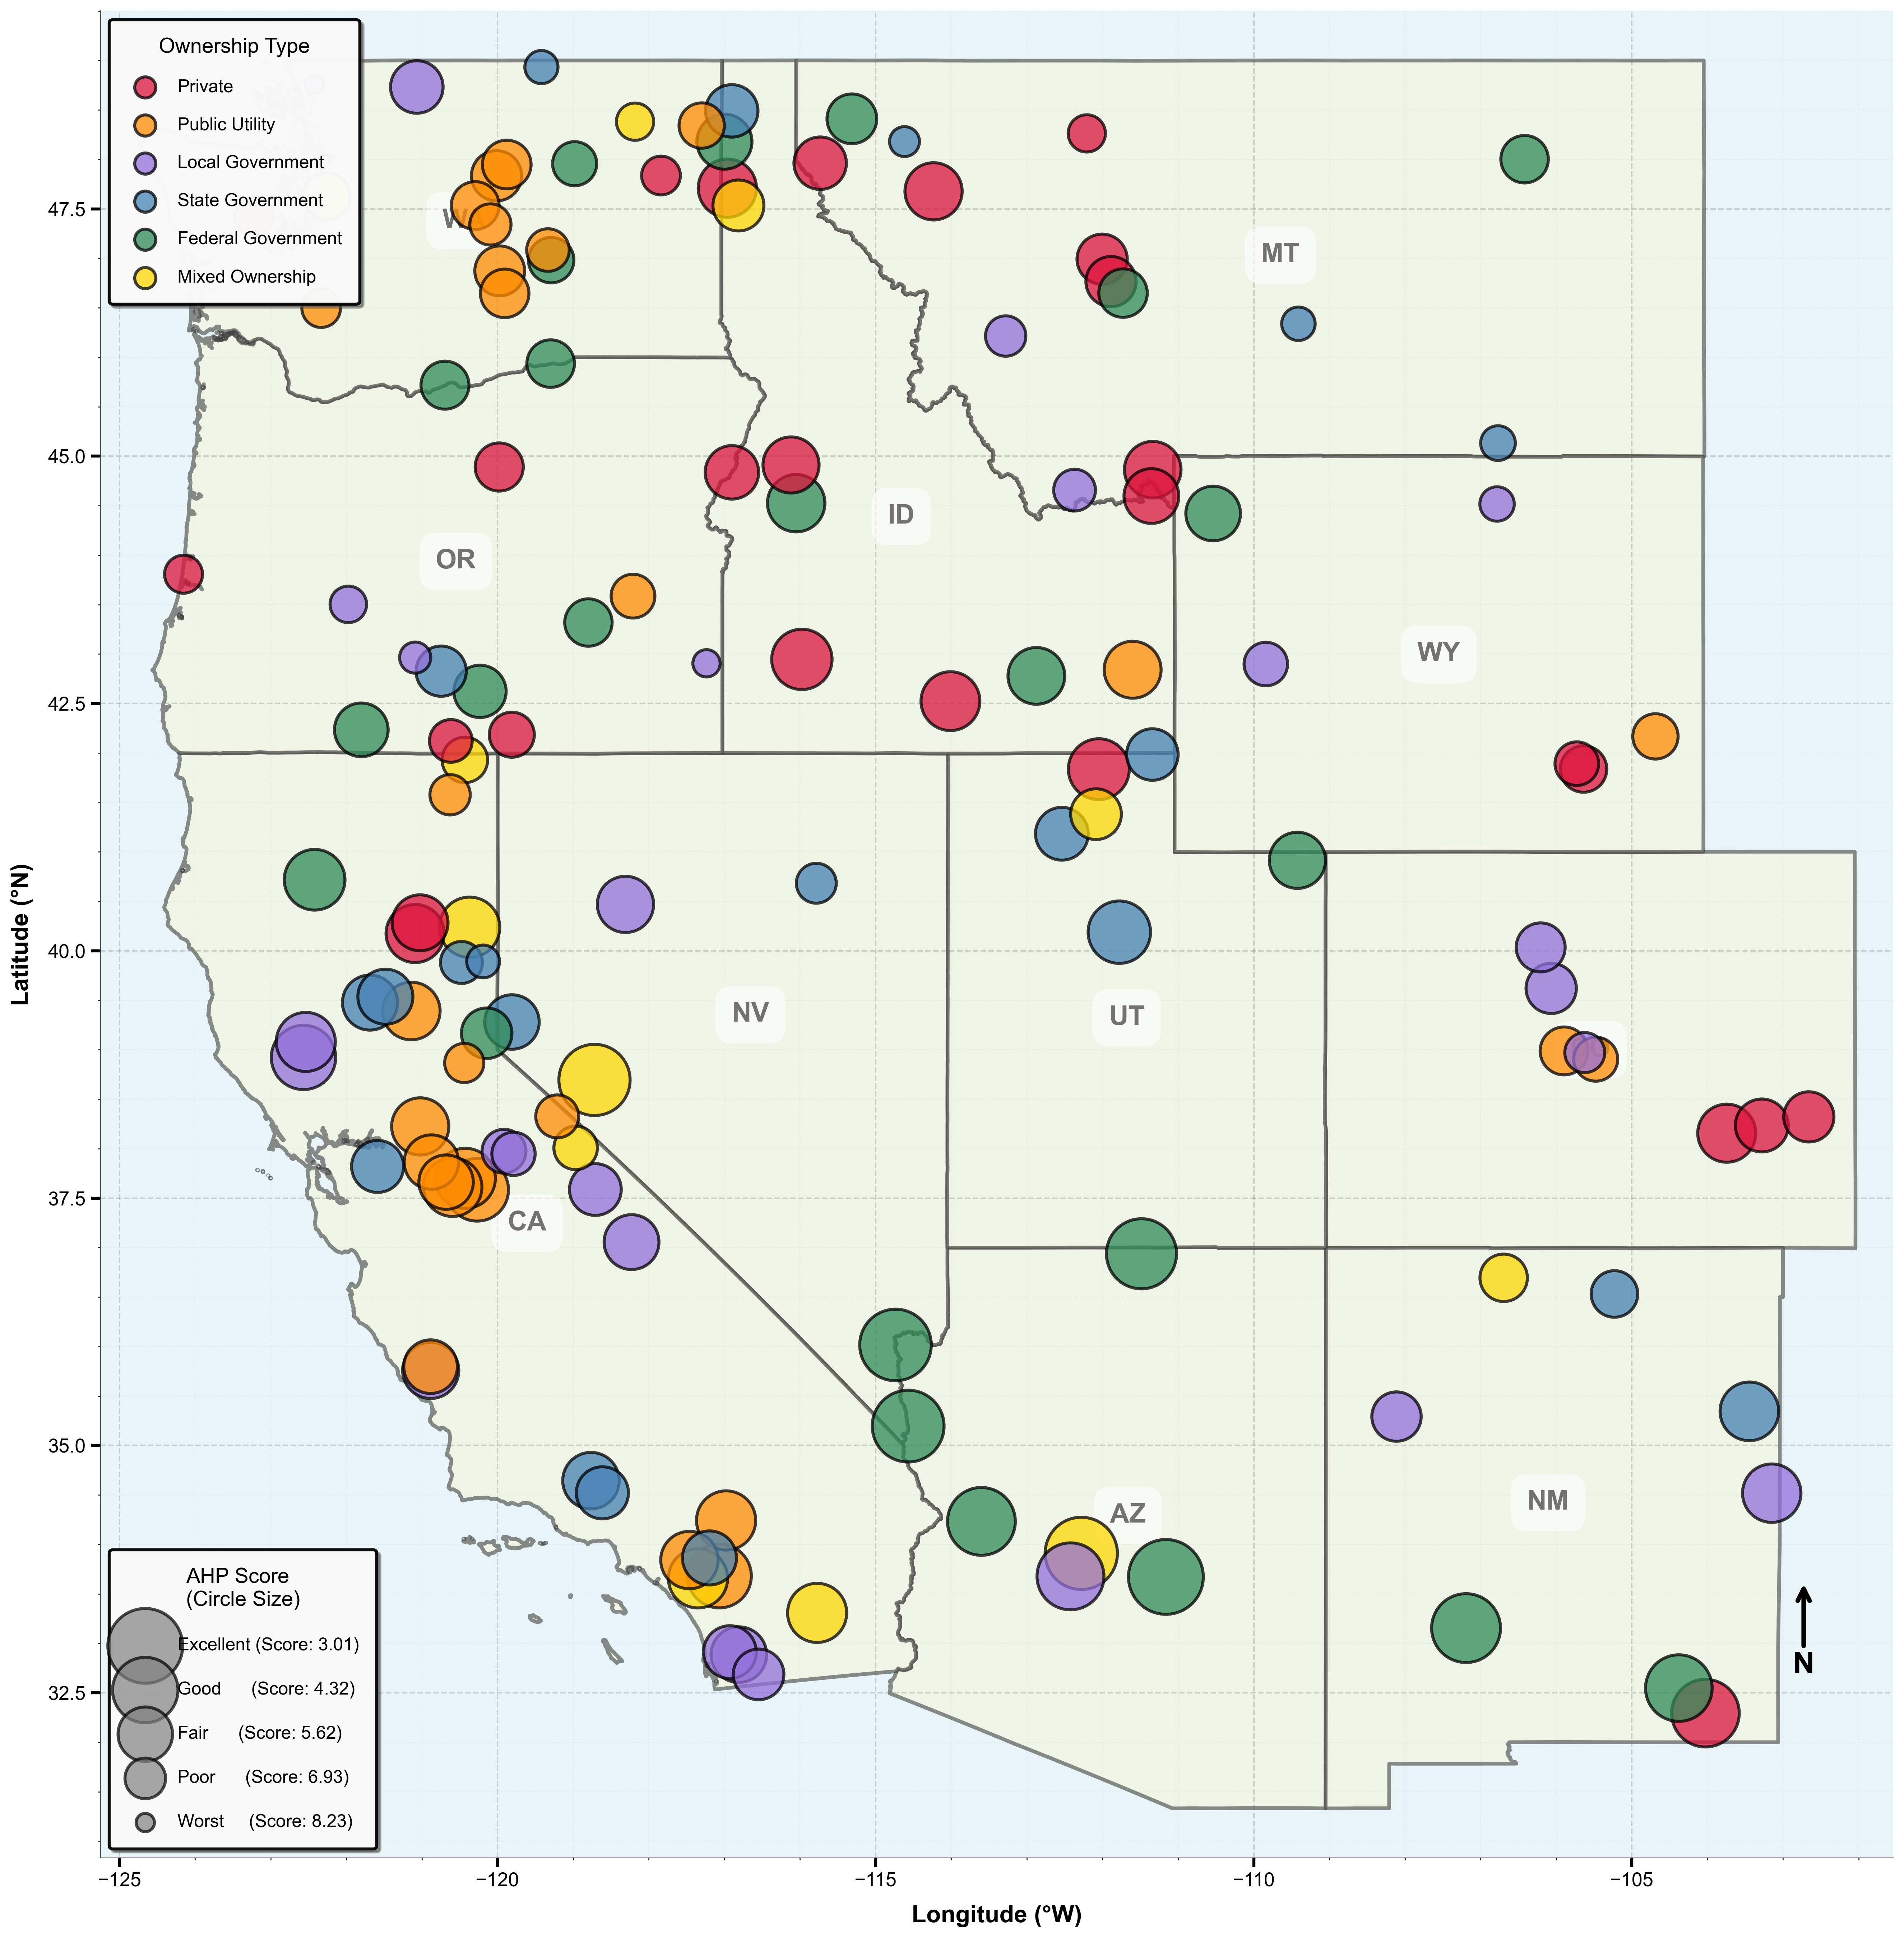


✓ Step 9 completed successfully!


In [18]:
# ========================================================================
# STEP 9: SPATIAL MAPPING AND REGIONAL ANALYSIS (MODIFIED)
# ========================================================================

print("\n" + "="*80)
print("STEP 9: CREATING SPATIAL MAPS AND REGIONAL ANALYSIS")
print("="*80 + "\n")

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ========================================================================
# CHECK FOR GEOGRAPHIC COORDINATES
# ========================================================================

has_coords = False
lat_col = None
lon_col = None

# Check for latitude/longitude columns (case-insensitive)
for col in df_ranked.columns:
    col_lower = col.lower()
    if 'lat' in col_lower and lat_col is None:
        lat_col = col
    if 'lon' in col_lower and lon_col is None:
        lon_col = col

if lat_col and lon_col:
    has_coords = True
    print(f"✓ Found coordinates: {lat_col}, {lon_col}")
    print(f"  Latitude range: {df_ranked[lat_col].min():.2f} to {df_ranked[lat_col].max():.2f}")
    print(f"  Longitude range: {df_ranked[lon_col].min():.2f} to {df_ranked[lon_col].max():.2f}\n")
else:
    print("⚠ No latitude/longitude columns found")
    print("  Available columns:", df_ranked.columns.tolist())
    print("  Skipping geographic maps...\n")

# ========================================================================
# MAP 1: GEOGRAPHIC MAP - WESTERN US WITH COLORS BY OWNERSHIP
# ========================================================================

if has_coords:
    print("1. Creating geographic map of Western US reservoirs...")
    
    import geopandas as gpd
    import numpy as np
    from matplotlib.colors import to_rgb
    
    # Load US state boundaries shapefile
    print("   Loading state boundaries shapefile...")
    states = gpd.read_file("C:/Users/yzha1253/Desktop/UnitedStatesregion/US_State_Boundaries/US_State_Boundaries.shp")
    
    # Define Western US states
    western_states = [
        "California", "Oregon", "Washington", "Nevada", "Utah", "Arizona",
        "New Mexico", "Colorado", "Idaho", "Montana", "Wyoming"
    ]
    
    print(f"   Shapefile columns: {states.columns.tolist()}")
    
    if "NAME" in states.columns:
        states_west = states[states["NAME"].isin(western_states)]
    elif "STATE_NAME" in states.columns:
        states_west = states[states["STATE_NAME"].isin(western_states)]
    elif "STUSPS" in states.columns:
        western_abbrev = ["CA", "OR", "WA", "NV", "UT", "AZ", "NM", "CO", "ID", "MT", "WY"]
        states_west = states[states["STUSPS"].isin(western_abbrev)]
    else:
        text_col = states.select_dtypes(include=['object']).columns[0]
        states_west = states[states[text_col].isin(western_states)]
    
    print(f"   Found {len(states_west)} Western states in shapefile")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(22, 18), facecolor='white')
    ax.set_facecolor('#E8F4F8')
    
    # Plot state boundaries
    states_west.plot(ax=ax, 
                     facecolor='#F5F5DC',
                     edgecolor='#404040',
                     linewidth=2.5,
                     alpha=0.6,
                     zorder=1)
    
    # Filter dams within Western states boundaries
    bounds = states_west.total_bounds  # [minx, miny, maxx, maxy]
    
    western_dams = df_ranked[
        (df_ranked[lon_col] >= bounds[0]) & 
        (df_ranked[lon_col] <= bounds[2]) &
        (df_ranked[lat_col] >= bounds[1]) & 
        (df_ranked[lat_col] <= bounds[3])
    ].copy()
    
    print(f"   Found {len(western_dams)} dams in Western US region")
    
    # ====================================================================
    # OWNERSHIP COLOR DEFINITIONS (based on numeric Ownership score)
    # ====================================================================
    # Score → (legend label, color)
    #   1 = Private            → Crimson
    #   2 = Public Utility     → Dark orange
    #   3 = Local Government   → Medium purple
    #   4 = State Government   → Steel blue
    #   5 = Federal Government → Sea green
    #  >5 = Mixed Ownership    → Gold

    ownership_score_map = {
        1: ('Private',            '#DC143C'),
        2: ('Public Utility',     '#FF8C00'),
        3: ('Local Government',   '#9370DB'),
        4: ('State Government',   '#4682B4'),
        5: ('Federal Government', '#2E8B57'),
    }
    MULTI_OWNERSHIP_COLOR = '#FFD700'   # Gold for mixed (score > 5)

    def get_ownership_color_from_score(score):
        """Map numeric Ownership score → (color, is_multi)."""
        try:
            score = int(score)
        except (ValueError, TypeError):
            return '#808080', False
        if score in ownership_score_map:
            return ownership_score_map[score][1], False
        elif score > 5:
            return MULTI_OWNERSHIP_COLOR, True
        else:
            return '#808080', False   # score 0 or unexpected

    # ====================================================================
    # ASSIGN COLORS USING NUMERIC Ownership COLUMN
    # ====================================================================
    print("   Using numeric Ownership score column for colors")
    result = western_dams['Ownership'].apply(get_ownership_color_from_score)
    western_dams['color']    = result.apply(lambda x: x[0])
    western_dams['is_multi'] = result.apply(lambda x: x[1])

    n_multi = western_dams['is_multi'].sum()
    print(f"   Dams with mixed ownership (score > 5): {n_multi}")
    print(f"   Ownership score distribution:\n{western_dams['Ownership'].value_counts().sort_index()}")

    # ====================================================================
    # CIRCLE SIZES BASED ON AHP SCORE (larger = better)
    # ====================================================================
    score_min = western_dams['AHP_Score'].min()
    score_max = western_dams['AHP_Score'].max()
    size_min, size_max = 150, 2500

    normalized_scores = 1 - ((western_dams['AHP_Score'] - score_min) / (score_max - score_min))
    circle_sizes = size_min + (normalized_scores * (size_max - size_min))

    # ====================================================================
    # PLOT RESERVOIRS
    # ====================================================================
    scatter = ax.scatter(
        western_dams[lon_col],
        western_dams[lat_col],
        s=circle_sizes,
        c=western_dams['color'],
        alpha=0.75,
        edgecolors='black',
        linewidth=2,
        zorder=4
    )

    # State labels
    state_abbrev = {
        "California": "CA", "Oregon": "OR", "Washington": "WA",
        "Nevada": "NV", "Utah": "UT", "Arizona": "AZ",
        "New Mexico": "NM", "Colorado": "CO", "Idaho": "ID",
        "Montana": "MT", "Wyoming": "WY"
    }

    for idx, row in states_west.iterrows():
        centroid = row.geometry.centroid
        for name_col in ["NAME", "STATE_NAME", "STUSPS"]:
            if name_col in states_west.columns:
                state_name = row[name_col]
                break
        else:
            state_name = ""
        display_name = state_abbrev.get(state_name, state_name)
        ax.text(centroid.x, centroid.y, display_name,
                fontsize=18, ha='center', va='center',
                color='#505050', alpha=0.8, fontweight='bold',
                zorder=2,
                bbox=dict(boxstyle='round,pad=0.6',
                          facecolor='white', edgecolor='none', alpha=0.6))

    # ====================================================================
    # LEGEND 1: OWNERSHIP TYPE COLORS
    # ====================================================================
    legend_elements_ownership = []

    # Single ownership types in score order (1→5)
    for score in sorted(ownership_score_map.keys()):
        label, color = ownership_score_map[score]
        if (western_dams['color'] == color).any():
            legend_elements_ownership.append(
                plt.scatter([], [], s=200, c=color, alpha=0.75,
                            edgecolors='black', linewidth=2,
                            label=label)
            )

    # Mixed ownership (score > 5)
    if n_multi > 0:
        legend_elements_ownership.append(
            plt.scatter([], [], s=200, c=MULTI_OWNERSHIP_COLOR, alpha=0.75,
                        edgecolors='black', linewidth=2,
                        label='Mixed Ownership')
        )

    # Unknown (score 0 or unrecognized)
    if (western_dams['color'] == '#808080').any():
        legend_elements_ownership.append(
            plt.scatter([], [], s=200, c='#808080', alpha=0.75,
                        edgecolors='black', linewidth=2,
                        label='Unknown')
        )

    legend_ownership = ax.legend(
        handles=legend_elements_ownership,
        loc='upper left',
        fontsize=12,
        title='Ownership Type',
        title_fontsize=14,
        framealpha=0.95,
        edgecolor='black',
        fancybox=True,
        shadow=True,
        borderpad=1,
        labelspacing=1.2
    )
    legend_ownership.get_frame().set_linewidth(2)
    ax.add_artist(legend_ownership)

    # ====================================================================
    # LEGEND 2: CIRCLE SIZE (AHP SCORE)
    # ====================================================================
    legend_sizes = [
        (score_min,                                    f'Excellent (Score: {score_min:.2f})'),
        (score_min + (score_max - score_min) * 0.25,  f'Good      (Score: {score_min + (score_max - score_min) * 0.25:.2f})'),
        ((score_min + score_max) / 2,                 f'Fair      (Score: {(score_min + score_max) / 2:.2f})'),
        (score_min + (score_max - score_min) * 0.75,  f'Poor      (Score: {score_min + (score_max - score_min) * 0.75:.2f})'),
        (score_max,                                    f'Worst     (Score: {score_max:.2f})'),
    ]
    legend_elements_size = []
    for score, label in legend_sizes:
        norm = 1 - ((score - score_min) / (score_max - score_min))
        size = size_min + (norm * (size_max - size_min))
        legend_elements_size.append(
            plt.scatter([], [], s=size, c='gray', alpha=0.7,
                        edgecolors='black', linewidth=2, label=label)
        )

    legend_size = ax.legend(
        handles=legend_elements_size,
        loc='lower left',
        fontsize=12,
        title='AHP Score\n(Circle Size)',
        title_fontsize=14,
        framealpha=0.95,
        edgecolor='black',
        fancybox=True,
        shadow=True,
        borderpad=1,
        labelspacing=1.5
    )
    legend_size.get_frame().set_linewidth(2)

    # ====================================================================
    # MAP FORMATTING
    # ====================================================================
    padding = 0.5
    ax.set_xlim(bounds[0] - padding, bounds[2] + padding)
    ax.set_ylim(bounds[1] - padding, bounds[3] + padding)

    ax.set_xlabel('Longitude (°W)', fontsize=16, fontweight='bold', labelpad=10)
    ax.set_ylabel('Latitude (°N)', fontsize=16, fontweight='bold', labelpad=10)


    ax.tick_params(axis='both', which='major', labelsize=13, width=2, length=6)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=1, color='#606060', zorder=0)
    ax.minorticks_on()
    ax.grid(True, which='minor', alpha=0.1, linestyle=':', linewidth=0.5, color='#808080', zorder=0)



    # North arrow
    ax.annotate('N',
                xy=(0.95, 0.15), xytext=(0.95, 0.10),
                xycoords='axes fraction',
                fontsize=20, fontweight='bold', ha='center',
                arrowprops=dict(arrowstyle='->', lw=3, color='black'))

    plt.tight_layout()
    plt.savefig('Western_US_Reservoirs_AHP_Analysis_Enhanced.png', dpi=300, bbox_inches='tight')
    print("   ✓ Map saved: Western_US_Reservoirs_AHP_Analysis_Enhanced.png\n")
    plt.show()

print("\n✓ Step 9 completed successfully!")

In [19]:
# ============================================================================
# STEP 10: GLOBAL SENSITIVITY ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("STEP 10: GLOBAL SENSITIVITY ANALYSIS")
print("="*80 + "\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================================
# CONFIGURATION
# ============================================================================

n_simulations = 10000
print(f"Running {n_simulations} Monte Carlo simulations...")

perturbation_factor = 0.5
top_n = 30
np.random.seed(42)

# ============================================================================
# MONTE CARLO SIMULATION
# ============================================================================

print("\n1. Performing Monte Carlo weight perturbations...")

simulation_results = {
    'simulation_id': [],
    'dam_name': [],
    'rank': [],
    'ahp_score': []
}

simulation_weights = []

for sim_id in range(n_simulations):
    if (sim_id + 1) % 1000 == 0:
        print(f"   Progress: {sim_id + 1}/{n_simulations} simulations...")

    perturbed_weights = {}
    for var in variables:
        base_weight = weights[var]
        perturbation = np.random.uniform(-perturbation_factor, perturbation_factor)
        perturbed = base_weight * (1 + perturbation)
        perturbed_weights[var] = max(0.01, perturbed)

    total = sum(perturbed_weights.values())
    perturbed_weights = {k: v/total for k, v in perturbed_weights.items()}
    simulation_weights.append(perturbed_weights.copy())

    df_sim = df_ranked.copy()
    df_sim['AHP_Score_Sim'] = sum(
        df_sim[f'{var}_category'] * perturbed_weights[var]
        for var in variables
    )
    df_sim['Rank_Sim'] = df_sim['AHP_Score_Sim'].rank(method='min')

    for idx, row in df_sim.iterrows():
        simulation_results['simulation_id'].append(sim_id)
        simulation_results['dam_name'].append(row['Name'])
        simulation_results['rank'].append(row['Rank_Sim'])
        simulation_results['ahp_score'].append(row['AHP_Score_Sim'])

df_simulations = pd.DataFrame(simulation_results)
df_weights_all = pd.DataFrame(simulation_weights)

print(f"\n✓ Completed {n_simulations} simulations")
print(f"  Total observations: {len(df_simulations)}")

# ============================================================================
# ROBUSTNESS METRICS CALCULATION
# ============================================================================

print("\n2. Calculating robustness metrics...")

robustness_metrics = []

for dam_name in df_ranked['Name'].unique():
    dam_sims = df_simulations[df_simulations['dam_name'] == dam_name]

    top_n_count = (dam_sims['rank'] <= top_n).sum()
    top_n_probability = top_n_count / n_simulations

    ranks = dam_sims['rank'].values
    rank_mean   = np.mean(ranks)
    rank_median = np.median(ranks)
    rank_std    = np.std(ranks)
    rank_min    = np.min(ranks)
    rank_max    = np.max(ranks)
    rank_range  = rank_max - rank_min
    rank_q25    = np.percentile(ranks, 25)
    rank_q75    = np.percentile(ranks, 75)
    rank_iqr    = rank_q75 - rank_q25

    scores     = dam_sims['ahp_score'].values
    score_mean = np.mean(scores)
    score_std  = np.std(scores)

    base_rank  = df_ranked[df_ranked['Name'] == dam_name]['Rank'].iloc[0]
    base_score = df_ranked[df_ranked['Name'] == dam_name]['AHP_Score'].iloc[0]

    if top_n_probability >= 0.8 and rank_iqr <= 10:
        robustness_class = 'Highly Robust'
    elif top_n_probability >= 0.5 and rank_iqr <= 20:
        robustness_class = 'Moderately Robust'
    elif top_n_probability >= 0.2:
        robustness_class = 'Partially Robust'
    else:
        robustness_class = 'Weight-Sensitive'

    robustness_metrics.append({
        'Dam_Name':         dam_name,
        'Base_Rank':        base_rank,
        'Base_Score':       base_score,
        'Mean_Rank':        rank_mean,
        'Median_Rank':      rank_median,
        'Rank_Std':         rank_std,
        'Rank_Min':         rank_min,
        'Rank_Max':         rank_max,
        'Rank_Range':       rank_range,
        'Rank_IQR':         rank_iqr,
        'Rank_Q25':         rank_q25,
        'Rank_Q75':         rank_q75,
        'Top30_Probability': top_n_probability,
        'Score_Mean':       score_mean,
        'Score_Std':        score_std,
        'Robustness_Class': robustness_class
    })

df_robustness = pd.DataFrame(robustness_metrics)
df_robustness = df_robustness.sort_values('Base_Rank')

print("✓ Robustness metrics calculated")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*80)
print("SENSITIVITY ANALYSIS SUMMARY")
print("="*80 + "\n")

print("ROBUSTNESS CLASSIFICATION:")
print(df_robustness['Robustness_Class'].value_counts().to_string())

highly_robust = df_robustness[df_robustness['Robustness_Class'] == 'Highly Robust']
print(f"\n\nHIGHLY ROBUST SITES (n={len(highly_robust)}):")
print("Sites with P(Top-30) ≥ 0.8 and Rank IQR ≤ 10")
print(highly_robust.head(20)[['Dam_Name', 'Base_Rank', 'Top30_Probability', 'Rank_IQR', 'Rank_Range']].to_string(index=False))

weight_sensitive = df_robustness[df_robustness['Robustness_Class'] == 'Weight-Sensitive']
print(f"\n\nWEIGHT-SENSITIVE SITES (n={len(weight_sensitive)}):")
print("Sites with P(Top-30) < 0.2 or high rank variability")
print(weight_sensitive.head(20)[['Dam_Name', 'Base_Rank', 'Top30_Probability', 'Rank_IQR', 'Rank_Range']].to_string(index=False))

print("\n\nOVERALL ROBUSTNESS STATISTICS:")
print(f"  Median Rank IQR: {df_robustness['Rank_IQR'].median():.1f}")
print(f"  Mean Top-30 Probability (for base Top-30): {df_robustness.head(30)['Top30_Probability'].mean():.3f}")
print(f"  Sites with P(Top-30) ≥ 0.8: {(df_robustness['Top30_Probability'] >= 0.8).sum()}")
print(f"  Sites with Rank IQR ≤ 10: {(df_robustness['Rank_IQR'] <= 10).sum()}")

print("\n\nWEIGHT PERTURBATION STATISTICS:")
for var in variables:
    var_weights = df_weights_all[var]
    print(f"  {var}:")
    print(f"    Base: {weights[var]:.3f}")
    print(f"    Range: [{var_weights.min():.3f}, {var_weights.max():.3f}]")
    print(f"    Mean: {var_weights.mean():.3f} ± {var_weights.std():.3f}")

# ============================================================================
# VISUALIZATION 1: RANK UNCERTAINTY PLOT (4 panels, no titles)
# ============================================================================

print("\n3. Creating rank uncertainty visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# --- Panel 1: Rank Range for Top 50 ---
ax1 = axes[0, 0]

top_50_robust = df_robustness.head(50)
y_pos = np.arange(len(top_50_robust))

for i, row in enumerate(top_50_robust.itertuples()):
    ax1.plot([row.Rank_Min, row.Rank_Max], [i, i],
             linewidth=8, alpha=0.6, color='steelblue')
    ax1.plot([row.Rank_Q25, row.Rank_Q75], [i, i],
             linewidth=12, alpha=0.9, color='navy')
    ax1.scatter([row.Base_Rank], [i], s=100, c='red',
                marker='D', zorder=5, edgecolors='black', linewidth=1.5)

ax1.set_yticks(y_pos)
ax1.set_yticklabels([name[:30] for name in top_50_robust['Dam_Name']], fontsize=8)
ax1.set_xlabel('Rank', fontsize=12, fontweight='bold')
ax1.set_ylabel('Reservoir', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# --- Panel 2: Top-30 Membership Probability ---
ax2 = axes[0, 1]

top_100_prob = df_robustness.head(100)
colors_prob = []
for prob in top_100_prob['Top30_Probability']:
    if prob >= 0.8:
        colors_prob.append('darkgreen')
    elif prob >= 0.5:
        colors_prob.append('lightgreen')
    elif prob >= 0.2:
        colors_prob.append('orange')
    else:
        colors_prob.append('red')

ax2.barh(range(len(top_100_prob)), top_100_prob['Top30_Probability'],
         color=colors_prob, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.axvline(0.8, color='darkgreen', linestyle='--', linewidth=2, label='P=0.8 (Robust)')
ax2.axvline(0.5, color='orange',    linestyle='--', linewidth=2, label='P=0.5')
ax2.axvline(0.2, color='red',       linestyle='--', linewidth=2, label='P=0.2 (Sensitive)')

ax2.set_yticks(range(0, len(top_100_prob), 10))
ax2.set_yticklabels(range(1, len(top_100_prob)+1, 10), fontsize=10)
ax2.set_xlabel('P(Top-30 Membership)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Base Rank', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='x')
ax2.invert_yaxis()

# --- Panel 3: Robustness Scatter Plot ---
ax3 = axes[1, 0]

scatter_colors = {
    'Highly Robust':     'darkgreen',
    'Moderately Robust': 'lightgreen',
    'Partially Robust':  'orange',
    'Weight-Sensitive':  'red'
}

for robustness_class, color in scatter_colors.items():
    subset = df_robustness[df_robustness['Robustness_Class'] == robustness_class]
    ax3.scatter(subset['Rank_IQR'], subset['Top30_Probability'],
                c=color, s=100, alpha=0.7, edgecolors='black', linewidth=1,
                label=f'{robustness_class} (n={len(subset)})')

ax3.axhline(0.8, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax3.axvline(10,  color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax3.set_xlabel('Rank Interquartile Range (IQR)', fontsize=12, fontweight='bold')
ax3.set_ylabel('P(Top-30 Membership)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9, loc='upper right')
ax3.grid(True, alpha=0.3)

# --- Panel 4: Rank Distribution for Selected Sites ---
ax4 = axes[1, 1]

robust_examples   = df_robustness[df_robustness['Robustness_Class'] == 'Highly Robust'].head(2)
sensitive_examples = df_robustness[df_robustness['Robustness_Class'] == 'Weight-Sensitive'].head(2)
moderate_examples  = df_robustness[df_robustness['Robustness_Class'] == 'Moderately Robust'].head(1)

example_sites = (list(robust_examples['Dam_Name']) +
                 list(moderate_examples['Dam_Name']) +
                 list(sensitive_examples['Dam_Name']))

positions_box = []
box_data      = []
box_labels    = []

for i, dam_name in enumerate(example_sites):
    dam_ranks = df_simulations[df_simulations['dam_name'] == dam_name]['rank'].values
    box_data.append(dam_ranks)
    positions_box.append(i)
    rob_class = df_robustness[df_robustness['Dam_Name'] == dam_name]['Robustness_Class'].iloc[0]
    box_labels.append(f"{dam_name[:20]}\n({rob_class})")

bp = ax4.boxplot(box_data, positions=positions_box, vert=True,
                 patch_artist=True, widths=0.6)

for patch, dam_name in zip(bp['boxes'], example_sites):
    rob_class = df_robustness[df_robustness['Dam_Name'] == dam_name]['Robustness_Class'].iloc[0]
    patch.set_facecolor(scatter_colors[rob_class])
    patch.set_alpha(0.7)

ax4.set_xticks(positions_box)
ax4.set_xticklabels(box_labels, fontsize=9, rotation=15, ha='right')
ax4.set_ylabel('Rank', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig(output_dir + 'sensitivity_rank_uncertainty.png',
            dpi=300, bbox_inches='tight')
print(f"   ✓ Saved: {output_dir}sensitivity_rank_uncertainty.png")
plt.close()

# ============================================================================
# VISUALIZATION 2: GEOGRAPHIC ROBUSTNESS MAP (no titles)
# ============================================================================

if has_coords:
    print("4. Creating geographic robustness map...")

    df_map = df_ranked.merge(
        df_robustness[['Dam_Name', 'Top30_Probability', 'Rank_IQR', 'Robustness_Class']],
        left_on='Name', right_on='Dam_Name', how='left'
    )

    western_map = df_map[
        (df_map[lon_col] >= bounds[0]) &
        (df_map[lon_col] <= bounds[2]) &
        (df_map[lat_col] >= bounds[1]) &
        (df_map[lat_col] <= bounds[3])
    ].copy()

    fig, axes = plt.subplots(1, 2, figsize=(24, 12))

    # --- Panel 1: Top-30 Probability Map ---
    ax1 = axes[0]
    states_west.plot(ax=ax1, facecolor='#F5F5DC', edgecolor='#404040',
                     linewidth=2, alpha=0.6, zorder=1)
    sizes_map = 2500 / (western_map['Rank'] + 1)
    scatter1 = ax1.scatter(western_map[lon_col], western_map[lat_col],
                           s=sizes_map,
                           c=western_map['Top30_Probability'],
                           cmap='RdYlGn',
                           alpha=0.75, edgecolors='black', linewidth=1.5,
                           vmin=0, vmax=1, zorder=3)
    cbar1 = plt.colorbar(scatter1, ax=ax1, fraction=0.025, pad=0.03)
    cbar1.set_label('P(Top-30 Membership)', fontsize=13, fontweight='bold')
    ax1.set_xlim(bounds[0] - 0.5, bounds[2] + 0.5)
    ax1.set_ylim(bounds[1] - 0.5, bounds[3] + 0.5)
    ax1.set_xlabel('Longitude', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Latitude',  fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')

    # --- Panel 2: Rank IQR Map ---
    ax2 = axes[1]
    states_west.plot(ax=ax2, facecolor='#F5F5DC', edgecolor='#404040',
                     linewidth=2, alpha=0.6, zorder=1)
    scatter2 = ax2.scatter(western_map[lon_col], western_map[lat_col],
                           s=sizes_map,
                           c=western_map['Rank_IQR'],
                           cmap='RdYlGn_r',
                           alpha=0.75, edgecolors='black', linewidth=1.5,
                           vmin=0, vmax=western_map['Rank_IQR'].quantile(0.95),
                           zorder=3)
    cbar2 = plt.colorbar(scatter2, ax=ax2, fraction=0.025, pad=0.03)
    cbar2.set_label('Rank Interquartile Range (IQR)', fontsize=13, fontweight='bold')
    ax2.set_xlim(bounds[0] - 0.5, bounds[2] + 0.5)
    ax2.set_ylim(bounds[1] - 0.5, bounds[3] + 0.5)
    ax2.set_xlabel('Longitude', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Latitude',  fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')

    plt.tight_layout()
    plt.savefig(output_dir + 'sensitivity_geographic_robustness.png',
                dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved: {output_dir}sensitivity_geographic_robustness.png")
    plt.close()

# ============================================================================
# VISUALIZATION 3: CRITERION CONTRIBUTION ANALYSIS (no title)
# ============================================================================

print("5. Analyzing criterion contributions...")

top_robust_sites = df_robustness[df_robustness['Robustness_Class'] == 'Highly Robust'].head(10)

fig, ax = plt.subplots(figsize=(16, 10))

contributions_data = []
for dam_name in top_robust_sites['Dam_Name']:
    dam_row = df_ranked[df_ranked['Name'] == dam_name].iloc[0]
    for var in variables:
        category     = dam_row[f'{var}_category']
        weight       = weights[var]
        contribution = category * weight
        contributions_data.append({
            'Dam':          dam_name[:25],
            'Criterion':    var.replace('_', ' '),
            'Contribution': contribution
        })

df_contributions = pd.DataFrame(contributions_data)

dam_names_unique = df_contributions['Dam'].unique()
criterion_names  = df_contributions['Criterion'].unique()
n_dams           = len(dam_names_unique)
n_criteria       = len(criterion_names)

x     = np.arange(n_dams)
width = 0.8 / n_criteria
colors_criteria = plt.cm.Set3(np.linspace(0, 1, n_criteria))

for i, criterion in enumerate(criterion_names):
    criterion_data = df_contributions[df_contributions['Criterion'] == criterion]
    values = [criterion_data[criterion_data['Dam'] == dam]['Contribution'].values[0]
              for dam in dam_names_unique]
    ax.bar(x + i*width, values, width, label=criterion,
           color=colors_criteria[i], alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Reservoir', fontsize=13, fontweight='bold')
ax.set_ylabel('Contribution to AHP Score', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * (n_criteria-1) / 2)
ax.set_xticklabels(dam_names_unique, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=10, ncol=3, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(output_dir + 'sensitivity_criterion_contributions.png',
            dpi=300, bbox_inches='tight')
print(f"   ✓ Saved: {output_dir}sensitivity_criterion_contributions.png")
plt.close()

# ============================================================================
# SAVE RESULTS
# ============================================================================

print("\n6. Saving sensitivity analysis results...")

df_robustness.to_csv(output_dir + 'sensitivity_robustness_metrics.csv', index=False)
print(f"   ✓ Saved: {output_dir}sensitivity_robustness_metrics.csv")

weight_stats = df_weights_all.describe()
weight_stats.to_csv(output_dir + 'sensitivity_weight_statistics.csv')
print(f"   ✓ Saved: {output_dir}sensitivity_weight_statistics.csv")

df_simulations.to_csv(output_dir + 'sensitivity_all_simulations.csv.gz',
                      index=False, compression='gzip')
print(f"   ✓ Saved: {output_dir}sensitivity_all_simulations.csv.gz")

print("\n" + "="*80)
print("SENSITIVITY ANALYSIS COMPLETE")
print("="*80)
print(f"\nFiles created:")
print("  1. sensitivity_rank_uncertainty.png")
print("  2. sensitivity_geographic_robustness.png")
print("  3. sensitivity_criterion_contributions.png")
print("  4. sensitivity_robustness_metrics.csv")
print("  5. sensitivity_weight_statistics.csv")
print("  6. sensitivity_all_simulations.csv.gz")
print("="*80 + "\n")


STEP 10: GLOBAL SENSITIVITY ANALYSIS

Running 10000 Monte Carlo simulations...

1. Performing Monte Carlo weight perturbations...
   Progress: 1000/10000 simulations...
   Progress: 2000/10000 simulations...
   Progress: 3000/10000 simulations...
   Progress: 4000/10000 simulations...
   Progress: 5000/10000 simulations...
   Progress: 6000/10000 simulations...
   Progress: 7000/10000 simulations...
   Progress: 8000/10000 simulations...
   Progress: 9000/10000 simulations...
   Progress: 10000/10000 simulations...

✓ Completed 10000 simulations
  Total observations: 1380000

2. Calculating robustness metrics...
✓ Robustness metrics calculated

SENSITIVITY ANALYSIS SUMMARY

ROBUSTNESS CLASSIFICATION:
Robustness_Class
Weight-Sensitive     96
Partially Robust     17
Highly Robust        14
Moderately Robust    11


HIGHLY ROBUST SITES (n=14):
Sites with P(Top-30) ≥ 0.8 and Rank IQR ≤ 10
                   Dam_Name  Base_Rank  Top30_Probability  Rank_IQR  Rank_Range
     Theodore Rooseve

In [20]:
median_iqr_sensitive = df_robustness[df_robustness['Robustness_Class'] == 'Weight-Sensitive']['Rank_IQR'].median()
print(f"Weight-Sensitive sites median Rank IQR = {median_iqr_sensitive:.1f}")

Weight-Sensitive sites median Rank IQR = 18.0


In [21]:
median_iqr_sensitive = df_robustness[df_robustness['Robustness_Class'] == 'Weight-Sensitive']['Rank_IQR'].median()
print(f"Weight-Sensitive sites median Rank IQR = {median_iqr_sensitive:.1f}")

median_iqr_robust = df_robustness[df_robustness['Robustness_Class'] == 'Highly Robust']['Rank_IQR'].median()
print(f"Highly Robust sites median Rank IQR    = {median_iqr_robust:.1f}")

Weight-Sensitive sites median Rank IQR = 18.0
Highly Robust sites median Rank IQR    = 3.0


In [22]:
# ============================================================================
# SUMMARY STATISTICS FOR MANUSCRIPT TEXT
# ============================================================================

print("\n" + "="*80)
print("SUMMARY STATISTICS FOR MANUSCRIPT")
print("="*80 + "\n")

# 1. Analyze dominant traits of the 18 highly robust sites (P >= 0.8)
highly_robust_p80 = df_robustness[df_robustness['Top30_Probability'] >= 0.8]
print(f"Number of sites with P(Top-30) ≥ 0.8: {len(highly_robust_p80)}\n")

print("Analyzing dominant traits of these {len(highly_robust_p80)} highly robust sites:")
trait_counts = {var: 0 for var in variables}

for dam_name in highly_robust_p80['Dam_Name']:
    dam_row = df_ranked[df_ranked['Name'] == dam_name].iloc[0]
    for var in variables:
        if dam_row[f'{var}_category'] <= 2:  # Excellent performance
            trait_counts[var] += 1

trait_percentages = {k: (v/len(highly_robust_p80))*100 for k, v in trait_counts.items()}
sorted_traits = sorted(trait_percentages.items(), key=lambda x: x[1], reverse=True)

print("\nDominant traits (% of robust sites excelling in each criterion):")
for var, pct in sorted_traits:
    print(f"  {var:30s}: {pct:5.1f}% ({trait_counts[var]}/{len(highly_robust_p80)} sites)")

top_3_traits = sorted_traits[:3]
print(f"\n📝 FOR MANUSCRIPT - Top 3 dominant traits:")
trait_text = ", ".join([f"{var.replace('_', ' ')}" for var, pct in top_3_traits[:2]])
trait_text += f", and {top_3_traits[2][0].replace('_', ' ')}"
print(f"   These robust sites are typically characterized by: {trait_text}")

# 2. Calculate median IQR for highly robust sites
median_iqr_highly_robust = df_robustness[df_robustness['Robustness_Class'] == 'Highly Robust']['Rank_IQR'].median()
print(f"\n📝 FOR MANUSCRIPT:")
print(f"   Median rank IQR (9 highly robust sites): {median_iqr_highly_robust:.1f}")

# 3. Median IQR for all sites
overall_median_iqr = df_robustness['Rank_IQR'].median()
print(f"   Median rank IQR (all 150 sites): {overall_median_iqr:.1f}")

# 4. Weight-sensitive sites statistics
weight_sensitive = df_robustness[df_robustness['Top30_Probability'] < 0.2]
print(f"\n📝 FOR MANUSCRIPT:")
print(f"   Sites with P(Top-30) < 0.2: {len(weight_sensitive)}")
median_iqr_sensitive = weight_sensitive['Rank_IQR'].median()
print(f"   Median rank IQR (weight-sensitive sites): {median_iqr_sensitive:.1f}")

print("\n" + "="*80)
print("FINAL MANUSCRIPT SENTENCE:")
print("="*80)
print(f"\n'These robust sites are typically characterized by {trait_text},")
print(f"leading to small rank dispersion (median rank IQR = {median_iqr_highly_robust:.1f}).")
print(f"By contrast, a second group shows substantial sensitivity to weights:")
print(f"{len(weight_sensitive)} sites exhibit low membership probability (P ≤ 0.3)")
print(f"and/or high rank variability (median rank IQR = {median_iqr_sensitive:.1f})...'")
print("\n" + "="*80 + "\n")


SUMMARY STATISTICS FOR MANUSCRIPT

Number of sites with P(Top-30) ≥ 0.8: 17

Analyzing dominant traits of these {len(highly_robust_p80)} highly robust sites:

Dominant traits (% of robust sites excelling in each criterion):
  Ice_binary                    :  88.2% (15/17 sites)
  Annual_evaporation            :  70.6% (12/17 sites)
  Capacity_Factor               :  70.6% (12/17 sites)
  nearest_dist_m                :  64.7% (11/17 sites)
  State_Regulation              :  64.7% (11/17 sites)
  log_Annual_solar_GWh          :  47.1% (8/17 sites)
  max_wind_ms                   :  35.3% (6/17 sites)
  Ownership                     :  23.5% (4/17 sites)
  HAB_flag_20k                  :  17.6% (3/17 sites)

📝 FOR MANUSCRIPT - Top 3 dominant traits:
   These robust sites are typically characterized by: Ice binary, Annual evaporation, and Capacity Factor

📝 FOR MANUSCRIPT:
   Median rank IQR (9 highly robust sites): 3.0
   Median rank IQR (all 150 sites): 17.0

📝 FOR MANUSCRIPT:
   Sites

In [23]:
# ============================================================================
# ANALYZE WHAT MAKES TOP-30 SITES SPECIAL
# ============================================================================

print("\n" + "="*80)
print("TOP-30 SITES: DETAILED CHARACTERISTICS ANALYSIS")
print("="*80 + "\n")

from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

# ============================================================================
# 1. GET TOP-30 SITES FROM ROBUSTNESS ANALYSIS
# ============================================================================

top30_sites = df_robustness[df_robustness['Base_Rank'] <= 30].copy()
print(f"Analyzing {len(top30_sites)} Top-30 sites\n")

# ============================================================================
# 2. CALCULATE AVERAGE CRITERION PERFORMANCE FOR TOP-30 VS REST
# ============================================================================

print("Criterion Performance Comparison:")
print("="*80)

# Get category columns
category_cols = [f'{var}_category' for var in variables]

# Top-30 profiles
top30_profiles = df_ranked[df_ranked['Rank'] <= 30][category_cols].describe()
rest_profiles = df_ranked[df_ranked['Rank'] > 30][category_cols].describe()

print("\nTop-30 Sites - Average Category Values (1=best, 10=worst):")
print("-"*80)
for var in variables:
    cat_col = f'{var}_category'
    if cat_col in df_ranked.columns:
        top30_mean = df_ranked[df_ranked['Rank'] <= 30][cat_col].mean()
        rest_mean = df_ranked[df_ranked['Rank'] > 30][cat_col].mean()
        difference = rest_mean - top30_mean
        print(f"  {var.replace('_', ' '):<35s}: {top30_mean:>6.2f} (Top-30) vs {rest_mean:>6.2f} (Rest) | Δ={difference:>6.2f}")

# ============================================================================
# 3. STABILITY WITHIN TOP-30
# ============================================================================

print("\n\nStability Analysis Within Top-30:")
print("="*80)
print("How stable are rankings WITHIN the Top-30?")
print("(Do sites 1-10 stay in 1-10, or do they drop to 20-30?)\n")

stability_results = []

for dam in top30_sites['Dam_Name']:
    dam_sims = df_simulations[df_simulations['dam_name'] == dam]
    base_rank = top30_sites[top30_sites['Dam_Name'] == dam]['Base_Rank'].iloc[0]
    
    pct_stayed_top10 = (dam_sims['rank'] <= 10).sum() / n_simulations
    pct_stayed_top30 = (dam_sims['rank'] <= 30).sum() / n_simulations
    pct_dropped_out = (dam_sims['rank'] > 30).sum() / n_simulations
    
    stability_results.append({
        'Dam_Name': dam,
        'Base_Rank': base_rank,
        'Pct_Top10': pct_stayed_top10,
        'Pct_Top30': pct_stayed_top30,
        'Pct_Dropped': pct_dropped_out
    })

df_stability = pd.DataFrame(stability_results).sort_values('Base_Rank')

print("Top 10 Sites - Probability of Staying in Top-10:")
print("-"*80)
print(df_stability.head(10)[['Dam_Name', 'Base_Rank', 'Pct_Top10', 'Pct_Top30']].to_string(index=False))

print("\n\nSites 21-30 - Probability of Staying in Top-30:")
print("-"*80)
print(df_stability.tail(10)[['Dam_Name', 'Base_Rank', 'Pct_Top30', 'Pct_Dropped']].to_string(index=False))

# ============================================================================
# 4. CONSENSUS VS BORDERLINE SITES
# ============================================================================

print("\n\nConsensus vs Borderline Classification:")
print("="*80)

# Consensus picks: appear in Top-30 >95% of time
top30_consensus = top30_sites[top30_sites['Top30_Probability'] > 0.95]
print(f"\nCONSENSUS PICKS (P(Top-30) > 95%): {len(top30_consensus)} sites")
print("-"*80)
if len(top30_consensus) > 0:
    print(top30_consensus[['Dam_Name', 'Base_Rank', 'Top30_Probability', 'Rank_IQR']].to_string(index=False))

# Borderline sites: appear in Top-30 50-80% of time
top30_borderline = top30_sites[(top30_sites['Top30_Probability'] >= 0.5) & 
                                (top30_sites['Top30_Probability'] <= 0.8)]
print(f"\n\nBORDERLINE SITES (50% ≤ P(Top-30) ≤ 80%): {len(top30_borderline)} sites")
print("-"*80)
if len(top30_borderline) > 0:
    print(top30_borderline[['Dam_Name', 'Base_Rank', 'Top30_Probability', 'Rank_IQR']].to_string(index=False))

# Vulnerable sites: appear in Top-30 <50% of time
top30_vulnerable = top30_sites[top30_sites['Top30_Probability'] < 0.5]
print(f"\n\nVULNERABLE SITES (P(Top-30) < 50%): {len(top30_vulnerable)} sites")
print("-"*80)
if len(top30_vulnerable) > 0:
    print(top30_vulnerable[['Dam_Name', 'Base_Rank', 'Top30_Probability', 'Rank_IQR']].to_string(index=False))

# ============================================================================
# 5. STATISTICAL TESTS: WHICH CRITERIA DISTINGUISH TOP-30?
# ============================================================================

print("\n\nStatistical Significance Tests:")
print("="*80)
print("Which criteria most distinguish Top-30 from rest?")
print("(Mann-Whitney U test, p < 0.05 = significantly different)\n")

significance_results = []

for var in variables:
    cat_col = f'{var}_category'
    if cat_col in df_ranked.columns:
        top30_vals = df_ranked[df_ranked['Rank'] <= 30][cat_col]
        rest_vals = df_ranked[df_ranked['Rank'] > 30][cat_col]
        
        stat, pval = mannwhitneyu(top30_vals, rest_vals, alternative='two-sided')
        
        top30_median = top30_vals.median()
        rest_median = rest_vals.median()
        
        significance_results.append({
            'Criterion': var.replace('_', ' '),
            'Top30_Median': top30_median,
            'Rest_Median': rest_median,
            'U_Statistic': stat,
            'P_Value': pval,
            'Significant': 'Yes' if pval < 0.05 else 'No'
        })

df_significance = pd.DataFrame(significance_results).sort_values('P_Value')

print("Criteria ranked by statistical significance:")
print("-"*80)
print(df_significance.to_string(index=False))

print("\n\nMost distinguishing criteria (p < 0.05):")
print("-"*80)
significant_criteria = df_significance[df_significance['Significant'] == 'Yes']
if len(significant_criteria) > 0:
    for idx, row in significant_criteria.iterrows():
        print(f"  {row['Criterion']:<35s}: p={row['P_Value']:.4f} (Top-30 median={row['Top30_Median']:.1f}, Rest median={row['Rest_Median']:.1f})")
else:
    print("  No criteria show significant differences at p < 0.05")

# ============================================================================
# 6. TRANSITION MATRIX
# ============================================================================

print("\n\nRank Transition Matrix:")
print("="*80)
print("If baseline rank is in tier X, what % of simulations end up in each tier?\n")

bins = [0, 10, 20, 30, 150]
labels = ['1-10', '11-20', '21-30', '31+']

transition_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
transition_matrix.fillna(0, inplace=True)

for i, (start_bin, end_bin) in enumerate(zip(bins[:-1], bins[1:])):
    tier_label_from = labels[i]
    
    # Get sites in this baseline tier
    baseline_in_tier = df_ranked[(df_ranked['Rank'] > start_bin) & 
                                 (df_ranked['Rank'] <= end_bin)]
    
    if len(baseline_in_tier) == 0:
        continue
    
    # For each site in this tier, see where they end up
    for dam_name in baseline_in_tier['Name']:
        dam_sims = df_simulations[df_simulations['dam_name'] == dam_name]
        
        for j, (dest_start, dest_end) in enumerate(zip(bins[:-1], bins[1:])):
            tier_label_to = labels[j]
            
            # Count simulations in destination tier
            count_in_dest = ((dam_sims['rank'] > dest_start) & 
                           (dam_sims['rank'] <= dest_end)).sum()
            
            transition_matrix.loc[tier_label_from, tier_label_to] += count_in_dest
    
    # Convert counts to percentages
    total_sims = len(baseline_in_tier) * n_simulations
    if total_sims > 0:
        transition_matrix.loc[tier_label_from, :] = (transition_matrix.loc[tier_label_from, :] / total_sims) * 100

print("Transition Probabilities (%):")
print("Rows = Baseline Rank Tier, Columns = Simulated Rank Tier")
print("-"*80)
print(transition_matrix.round(1).to_string())

print("\n\nKey Insights:")
print("-"*80)
# Sites ranked 1-10
tier_1_10_stay = transition_matrix.loc['1-10', '1-10']
print(f"  • Sites ranked 1-10 stay in 1-10:    {tier_1_10_stay:.1f}% of simulations")

# Sites ranked 11-20
tier_11_20_stay = transition_matrix.loc['11-20', '11-20']
tier_11_20_top10 = transition_matrix.loc['11-20', '1-10']
print(f"  • Sites ranked 11-20 stay in 11-20:  {tier_11_20_stay:.1f}% of simulations")
print(f"  • Sites ranked 11-20 move to 1-10:   {tier_11_20_top10:.1f}% of simulations")

# Sites ranked 21-30
tier_21_30_stay = transition_matrix.loc['21-30', '21-30']
tier_21_30_drop = transition_matrix.loc['21-30', '31+']
print(f"  • Sites ranked 21-30 stay in 21-30:  {tier_21_30_stay:.1f}% of simulations")
print(f"  • Sites ranked 21-30 drop out:       {tier_21_30_drop:.1f}% of simulations")

# ============================================================================
# 7. GEOGRAPHIC CLUSTERING (if coordinates available)
# ============================================================================

if has_coords:
    print("\n\nGeographic Clustering Analysis:")
    print("="*80)
    print("Are Top-30 sites geographically clustered?\n")
    
    from scipy.spatial.distance import pdist, squareform
    
    # Get coordinates for Top-30 sites
    top30_coords = df_ranked[df_ranked['Rank'] <= 30][[lat_col, lon_col]].values
    
    # Calculate pairwise distances (in degrees)
    distances = pdist(top30_coords, metric='euclidean')
    distance_matrix = squareform(distances)
    
    # Find nearest neighbor distances
    np.fill_diagonal(distance_matrix, np.inf)  # Ignore self-distances
    nearest_distances = distance_matrix.min(axis=1)
    
    avg_nearest = nearest_distances.mean()
    median_nearest = np.median(nearest_distances)
    
    print(f"  Average distance to nearest Top-30 neighbor: {avg_nearest:.2f}°")
    print(f"  Median distance to nearest Top-30 neighbor:  {median_nearest:.2f}°")
    
    # Compare with random expectation
    all_coords = df_ranked[[lat_col, lon_col]].values
    all_distances = pdist(all_coords, metric='euclidean')
    expected_nearest = np.percentile(all_distances, 100 * 30 / len(df_ranked))
    
    print(f"  Expected distance (random selection):        {expected_nearest:.2f}°")
    
    if avg_nearest < expected_nearest:
        print(f"\n  ✓ Top-30 sites ARE clustered (avg distance < expected)")
    else:
        print(f"\n  ✗ Top-30 sites are NOT particularly clustered")

print("\n" + "="*80)
print("✓ Top-30 Analysis Complete!")
print("="*80)


TOP-30 SITES: DETAILED CHARACTERISTICS ANALYSIS

Analyzing 30 Top-30 sites

Criterion Performance Comparison:

Top-30 Sites - Average Category Values (1=best, 10=worst):
--------------------------------------------------------------------------------
  Annual evaporation                 :   2.63 (Top-30) vs   6.30 (Rest) | Δ=  3.66
  Ice binary                         :   3.10 (Top-30) vs   8.33 (Rest) | Δ=  5.23
  max wind ms                        :   5.47 (Top-30) vs   5.51 (Rest) | Δ=  0.04
  nearest dist m                     :   3.60 (Top-30) vs   4.23 (Rest) | Δ=  0.63
  log Annual solar GWh               :   4.27 (Top-30) vs   5.84 (Rest) | Δ=  1.58
  Capacity Factor                    :   3.23 (Top-30) vs   6.13 (Rest) | Δ=  2.90
  HAB flag 20k                       :   8.20 (Top-30) vs   9.08 (Rest) | Δ=  0.88
  Ownership                          :   5.60 (Top-30) vs   4.92 (Rest) | Δ= -0.68
  State Regulation                   :   4.50 (Top-30) vs   5.94 (Rest) | Δ=  1.44




TOP 30 CANDIDATES: STATE & OWNERSHIP ANALYSIS

✓ Selected top 30 candidates based on AHP Score
  Score range: 3.0107 to 5.2063

Top 30 Reservoirs:
  # 1. Theodore Roosevelt Dam                   - Score: 3.0107
  # 2. Lake Pleasant                            - Score: 3.3848
  # 3. Davis Dam                                - Score: 3.4455
  # 4. Hoover Dam                               - Score: 3.4824
  # 5. Walker Lake                              - Score: 3.5341
  # 6. Glen Canyon Dam                          - Score: 3.6872
  # 7. Elephant Butte Dam                       - Score: 3.8590
  # 8. Alamo Dam                                - Score: 4.0029
  # 9. Southwest Laguna Grande Dam              - Score: 4.0207
  #10. Mcmicken                                 - Score: 4.1202
  #11. Brantley Dam                             - Score: 4.1663
  #12. Clear Lake                               - Score: 4.4558
  #13. Diamond Valley Lake                      - Score: 4.5240
  #14. Exchequer Mai

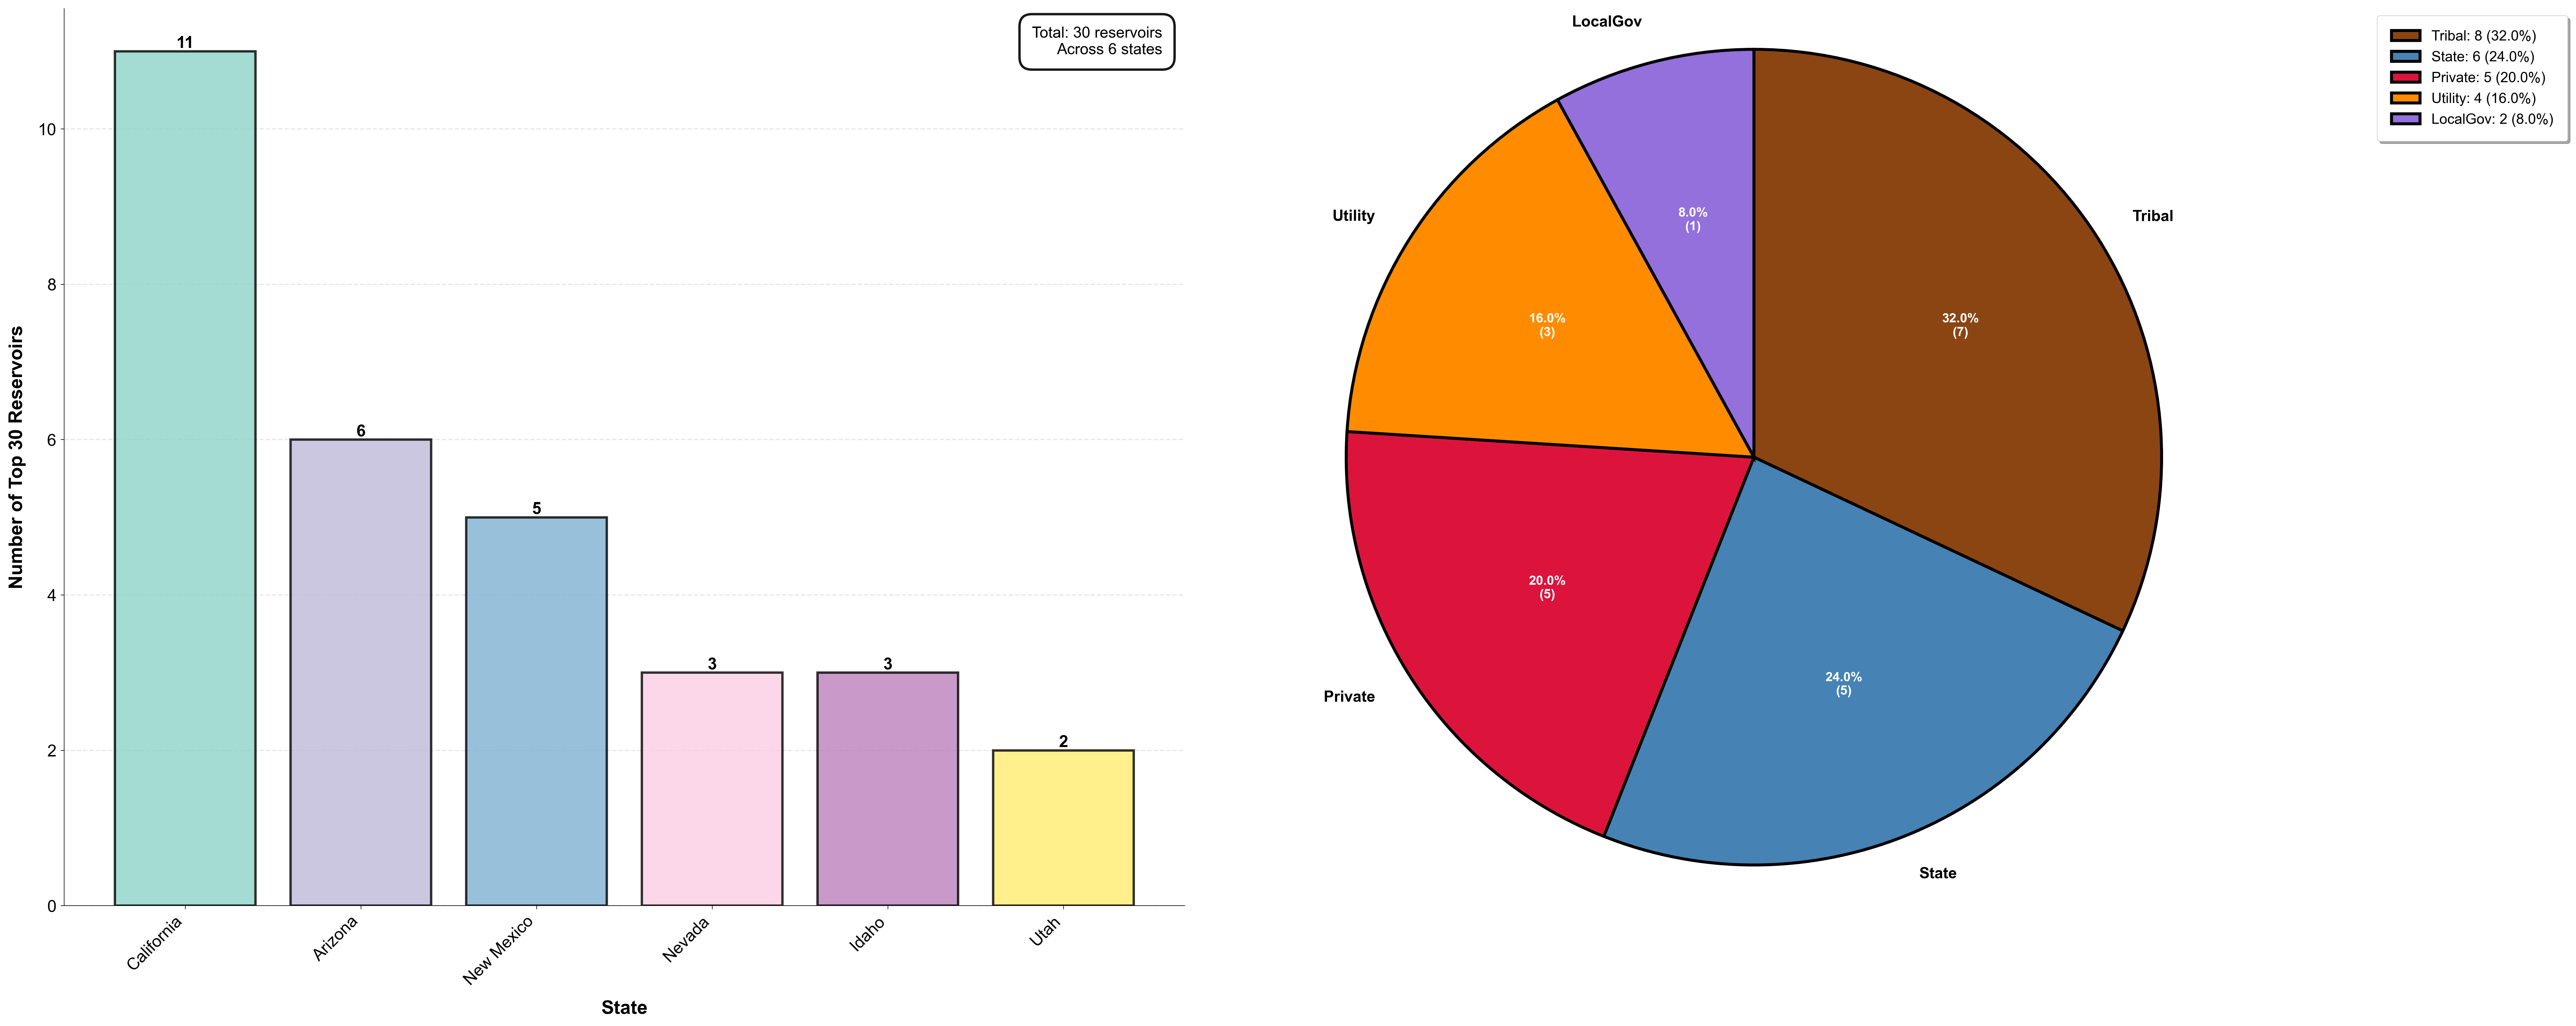


✓ Top 30 analysis completed successfully!
✓ Pie chart shows COUNT of ownership types (NOT scores)


In [24]:
# ========================================================================
# TOP 30 CANDIDATES ANALYSIS: STATE DISTRIBUTION & OWNERSHIP BREAKDOWN
# PIE CHART SHOWS COUNT OF OWNERSHIP TYPES (NOT SCORES!)
# ========================================================================

print("\n" + "="*80)
print("TOP 30 CANDIDATES: STATE & OWNERSHIP ANALYSIS")
print("="*80 + "\n")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ========================================================================
# GET TOP 30 CANDIDATES
# ========================================================================

top_30 = df_ranked.nsmallest(30, 'AHP_Score').copy()
print(f"✓ Selected top 30 candidates based on AHP Score")
print(f"  Score range: {top_30['AHP_Score'].min():.4f} to {top_30['AHP_Score'].max():.4f}\n")

# Display the top 30 list
print("Top 30 Reservoirs:")
print("="*80)
for idx, row in top_30.iterrows():
    rank = int(row['Rank'])
    name = row['Name']
    score = row['AHP_Score']
    # Try to get state info if available
    state_info = ""
    if 'State' in row.index and pd.notna(row['State']):
        state_info = f" ({row['State']})"
    print(f"  #{rank:2d}. {name:40s} - Score: {score:.4f}{state_info}")
print("="*80 + "\n")

# ========================================================================
# EXTRACT STATE INFORMATION
# ========================================================================

# Try to find state column (case-insensitive)
state_col = None
for col in top_30.columns:
    if col.lower() in ['state', 'state_name', 'st', 'state_abbr']:
        state_col = col
        break

if state_col is None:
    print("⚠ No 'State' column found. Attempting to extract from other fields...")
    
    # If coordinates are available, we could map them to states
    if has_coords and lat_col and lon_col:
        print("  Attempting to determine states from coordinates...")
        
        # Simple coordinate-based state assignment (approximate)
        def get_state_from_coords(lat, lon):
            """Rough state assignment based on coordinates"""
            # California
            if lon < -114 and lat > 32 and lat < 42:
                return 'California'
            # Oregon
            elif lon < -116 and lat > 42 and lat < 46:
                return 'Oregon'
            # Washington
            elif lon < -116 and lat > 45:
                return 'Washington'
            # Nevada
            elif lon > -120 and lon < -114 and lat > 35 and lat < 42:
                return 'Nevada'
            # Utah
            elif lon > -114 and lon < -109 and lat > 37 and lat < 42:
                return 'Utah'
            # Arizona
            elif lon > -115 and lon < -109 and lat > 31 and lat < 37:
                return 'Arizona'
            # New Mexico
            elif lon > -109 and lon < -103 and lat > 31 and lat < 37:
                return 'New Mexico'
            # Colorado
            elif lon > -109 and lon < -102 and lat > 37 and lat < 41:
                return 'Colorado'
            # Idaho
            elif lon > -117 and lon < -111 and lat > 42 and lat < 49:
                return 'Idaho'
            # Montana
            elif lon > -116 and lon < -104 and lat > 45:
                return 'Montana'
            # Wyoming
            elif lon > -111 and lon < -104 and lat > 41 and lat < 45:
                return 'Wyoming'
            else:
                return 'Unknown'
        
        top_30['State'] = top_30.apply(lambda row: get_state_from_coords(row[lat_col], row[lon_col]), axis=1)
        state_col = 'State'
        print(f"  ✓ Assigned states based on coordinates\n")
    else:
        # Create Unknown state
        top_30['State'] = 'Unknown'
        state_col = 'State'
        print("  ⚠ Could not determine states. Using 'Unknown'\n")
else:
    print(f"✓ Found state column: {state_col}\n")

# ========================================================================
# EXTRACT OWNERSHIP INFORMATION (KEEP RAW FORMAT)
# ========================================================================

# Try to find ownership column
ownership_col = None
for col in top_30.columns:
    col_lower = col.lower()
    if 'ownership' in col_lower or 'owner' in col_lower:
        ownership_col = col
        break

# Check if we need to decode numeric ownership values
print("\nChecking ownership data format...")
if ownership_col:
    print(f"✓ Found ownership column: {ownership_col}")
    
    # Check if ownership values are numeric
    sample_value = top_30[ownership_col].iloc[0]
    print(f"  Sample ownership value: {sample_value} (type: {type(sample_value).__name__})")
    
    # If numeric, we need to map to text labels
    if pd.api.types.is_numeric_dtype(top_30[ownership_col]):
        print("  ⚠ Ownership values are NUMERIC - need to map to text labels")
        print("\nPlease provide the mapping for these numeric codes:")
        print("Unique ownership values found:", sorted(top_30[ownership_col].unique()))
        
        # Common ownership type mapping (you may need to adjust this!)
        # This is a GUESS - please verify with your data dictionary
        ownership_mapping = {
            0: 'Federal',
            1: 'State', 
            2: 'Private',
            3: 'Utility',
            4: 'LocalGov',
            5: 'Tribal',
            6: 'Federal_State',
            7: 'Private_Utility',
            # Add more mappings as needed
        }
        
        print("\n⚠ USING ASSUMED MAPPING (please verify!):")
        for code, name in ownership_mapping.items():
            if code in top_30[ownership_col].values:
                count = (top_30[ownership_col] == code).sum()
                print(f"  {code} → {name:20s} ({count} sites)")
        
        # Apply mapping
        top_30['Ownership_Raw'] = top_30[ownership_col].map(ownership_mapping)
        
        # Fill any unmapped values
        top_30['Ownership_Raw'] = top_30['Ownership_Raw'].fillna('Unknown')
        
        ownership_col = 'Ownership_Raw'
        print(f"\n  ✓ Mapped numeric codes to ownership names\n")
    else:
        # Keep the raw ownership
        top_30['Ownership_Raw'] = top_30[ownership_col]
        ownership_col = 'Ownership_Raw'
        print(f"  ✓ Preserved raw ownership data\n")

else:
    # No ownership column found, try Source_File
    if 'Source_File' in top_30.columns:
        print("Using Source_File to extract ownership...")
        
        def extract_ownership_raw(source_file):
            """Extract ownership from Source_File name - KEEP RAW FORMAT"""
            if pd.isna(source_file):
                return 'Unknown'
            
            # Convert to string to be safe
            source_file = str(source_file)
            
            # Extract ownership, keeping underscores intact (raw format)
            ownership = source_file.replace('_Top30_Solar_cleaned.csv', '')
            
            # Map common variations to standard names
            ownership_mapping = {
                'PublicUtility': 'Utility',
                'Public_Utility': 'Utility',
                'Local': 'LocalGov',
                'Tribe': 'Tribal'
            }
            
            # Check if it's a simple replacement
            if ownership in ownership_mapping:
                return ownership_mapping[ownership]
            
            return ownership
        
        top_30['Ownership_Raw'] = top_30['Source_File'].apply(extract_ownership_raw)
        ownership_col = 'Ownership_Raw'
        print(f"  ✓ Extracted raw ownership from Source_File\n")
    else:
        top_30['Ownership_Raw'] = 'Unknown'
        ownership_col = 'Ownership_Raw'
        print("⚠ No ownership information found. Using 'Unknown'\n")

# ========================================================================
# PREPARE DATA FOR PLOTS
# ========================================================================

# State distribution
state_counts = top_30[state_col].value_counts().sort_values(ascending=False)

print("State Distribution:")
print("-" * 40)
for state, count in state_counts.items():
    print(f"  {state:30s}: {count:2d} ({count/len(top_30)*100:.1f}%)")
print()

# ========================================================================
# CREATE FIGURE WITH TWO SUBPLOTS
# ========================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 12), facecolor='white')

# ========================================================================
# PLOT 1: STATE DISTRIBUTION (HISTOGRAM/BAR CHART)
# ========================================================================

# Color palette for states
state_colors = plt.cm.Set3(np.linspace(0, 1, len(state_counts)))

bars = ax1.bar(range(len(state_counts)), 
               state_counts.values,
               color=state_colors,
               edgecolor='black',
               linewidth=2,
               alpha=0.8)

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, state_counts.values)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom',
            fontsize=14, fontweight='bold')

# Formatting
ax1.set_xlabel('State', fontsize=16, fontweight='bold', labelpad=10)
ax1.set_ylabel('Number of Top 30 Reservoirs', fontsize=16, fontweight='bold', labelpad=10)

ax1.set_xticks(range(len(state_counts)))
ax1.set_xticklabels(state_counts.index, rotation=45, ha='right', fontsize=14)
ax1.tick_params(axis='y', labelsize=14)

# Add grid
ax1.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=1)
ax1.set_axisbelow(True)

# Add total count annotation
total_text = f"Total: {len(top_30)} reservoirs\nAcross {len(state_counts)} states"
ax1.text(0.98, 0.98, total_text,
        transform=ax1.transAxes,
        fontsize=13,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.8', 
                 facecolor='white',
                 edgecolor='black',
                 linewidth=2,
                 alpha=0.9))

# ========================================================================
# PLOT 2: OWNERSHIP TYPE DISTRIBUTION (PIE CHART)
# COUNT INDIVIDUAL OWNERSHIP TYPES (SPLIT MULTIPLE OWNERSHIP)
# NO SCORES - JUST COUNTS!
# ========================================================================

# First, let's check what the ownership values actually look like
print("\n" + "="*80)
print("CHECKING OWNERSHIP DATA")
print("="*80)
print("\nSample ownership values from top 30:")
print(top_30[ownership_col].value_counts())
print("\nUnique ownership values:")
print(top_30[ownership_col].unique())
print()

# Define mapping from numeric codes to ownership names
# You may need to adjust this mapping based on your data
ownership_code_to_name = {
    0: 'Federal',
    1: 'State',
    2: 'Private',
    3: 'Utility',
    4: 'LocalGov',
    5: 'Tribal',
    6: 'Federal_State',
    7: 'Private_Utility',
    # Add more mappings as needed
}

# Define colors for ownership types (matching the map colors from step 9)
ownership_color_map = {
    'Federal': '#2E8B57',          # Sea green
    'State': '#4682B4',            # Steel blue
    'Private': '#DC143C',          # Crimson
    'Utility': '#FF8C00',          # Dark orange
    'LocalGov': '#9370DB',         # Medium purple
    'Tribal': '#8B4513',           # Saddle brown
}

# Count individual ownership types (splitting multiple ownership)
print("\n" + "="*80)
print("COUNTING INDIVIDUAL OWNERSHIP TYPES FOR PIE CHART")
print("(Sites with multiple ownership counted for each type)")
print("="*80 + "\n")

ownership_type_counts = {}

for idx, row in top_30.iterrows():
    ownership_raw = row[ownership_col]
    
    # Convert numeric code to name if needed
    if pd.notna(ownership_raw):
        # Check if it's numeric
        try:
            ownership_code = int(ownership_raw)
            if ownership_code in ownership_code_to_name:
                ownership_name = ownership_code_to_name[ownership_code]
            else:
                ownership_name = f'Unknown_{ownership_code}'
        except (ValueError, TypeError):
            # It's already a string
            ownership_name = str(ownership_raw)
    else:
        continue  # Skip NaN values
    
    # Split by underscore to get individual ownership types
    if '_' in ownership_name:
        parts = ownership_name.split('_')
    else:
        parts = [ownership_name]
    
    # Count each ownership type
    for part in parts:
        part = part.strip()
        if part and part != 'Unknown' and not part.startswith('Unknown_'):
            # Normalize the ownership type
            if part in ['PublicUtility', 'Public_Utility']:
                part = 'Utility'
            elif part == 'Local':
                part = 'LocalGov'
            elif part == 'Tribe':
                part = 'Tribal'
            
            if part in ownership_type_counts:
                ownership_type_counts[part] += 1
            else:
                ownership_type_counts[part] = 1

# Sort by count (descending)
ownership_type_counts = dict(sorted(ownership_type_counts.items(), 
                                   key=lambda x: x[1], 
                                   reverse=True))

print("Individual Ownership Type Counts:")
print("-"*60)
total_ownership_instances = sum(ownership_type_counts.values())
for ownership_type, count in ownership_type_counts.items():
    percentage = count/total_ownership_instances*100
    print(f"  {ownership_type:30s}: {count:2d} instances ({percentage:5.1f}%)")
print("-"*60)
print(f"Total ownership instances: {total_ownership_instances}")
print("(Note: This may be > 30 because sites with multiple ownership")
print(" are counted for each type they have)\n")

# Prepare pie chart data - COUNTS ONLY, NO SCORES!
pie_labels = list(ownership_type_counts.keys())
pie_values = list(ownership_type_counts.values())  # THIS IS THE COUNT!
pie_colors = []

for ownership_type in pie_labels:
    # Get color
    if ownership_type in ownership_color_map:
        pie_colors.append(ownership_color_map[ownership_type])
    else:
        # Check for partial match
        color_found = False
        for key, color in ownership_color_map.items():
            if ownership_type.lower() == key.lower():
                pie_colors.append(color)
                color_found = True
                break
        if not color_found:
            pie_colors.append('#808080')  # Gray for unknown

# Create pie chart
print("Creating pie chart with:")
print(f"  Labels: {pie_labels}")
print(f"  Values (COUNTS): {pie_values}")
print(f"  Total: {sum(pie_values)}\n")

wedges, texts, autotexts = ax2.pie(
    pie_values,  # THESE ARE COUNTS, NOT SCORES!
    labels=pie_labels,
    colors=pie_colors,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(pie_values))})',
    startangle=90,
    counterclock=False,
    wedgeprops=dict(edgecolor='black', linewidth=2.5),
    textprops=dict(fontsize=13, fontweight='bold'))

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Enhance the label text
for text in texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')


# Add legend with counts
legend_labels = [f'{ownership_type}: {count} ({count/total_ownership_instances*100:.1f}%)' 
                for ownership_type, count in ownership_type_counts.items()]
ax2.legend(legend_labels,
          loc='upper left',
          bbox_to_anchor=(1.05, 1),
          fontsize=12,
          frameon=True,
          fancybox=True,
          shadow=True,
          borderpad=1)

# Equal aspect ratio ensures that pie is drawn as a circle
ax2.axis('equal')

# ========================================================================
# FINAL FORMATTING AND SAVE
# ========================================================================

plt.tight_layout()
plt.savefig('Top30_State_Ownership_Analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved: Top30_State_Ownership_Analysis.png\n")
plt.show()

print("\n" + "="*80)
print("✓ Top 30 analysis completed successfully!")
print("✓ Pie chart shows COUNT of ownership types (NOT scores)")
print("="*80)

In [25]:
top_30.head(30)

,Name,surfaceArea_sqkm,latitude,longitude,Ownership,Primary Ownership,Annual_solar_potential,Annual_evaporation,Max_ice_depth,max_wind_ms,...,max_wind_ms_category,nearest_dist_m_category,log_Annual_solar_GWh_category,Capacity_Factor_category,HAB_flag_20k_category,Ownership_category,State_Regulation_category,AHP_Score,Rank,Ownership_Raw
0,Theodore Roosevelt Dam,128.900585,33.671500,-111.161500,5,Federal,2116.064853,1.952207,0.000000,7.933907,...,2,1,2,2,10,8,1,3.010654,1.0,Tribal
1,Lake Pleasant,37.173000,33.909308,-112.280544,8,NaN,2134.673308,2.082242,0.000000,10.815744,...,7,7,4,1,1,10,1,3.384804,2.0,Unknown
2,Davis Dam,114.121452,35.195900,-114.570000,5,Federal,2157.808782,2.045213,0.000000,10.609680,...,6,1,3,1,10,8,1,3.445465,3.0,Tribal
3,Hoover Dam,658.424122,36.016300,-114.737400,5,Federal,2120.665031,1.973181,0.000000,10.179908,...,5,1,1,2,10,8,3,3.482402,4.0,Tribal
4,Walker Lake,120.008459,38.695250,-118.718045,8,NaN,2072.421987,1.453963,0.000000,7.508865,...,2,7,3,2,1,10,3,3.534072,5.0,Unknown
5,Glen Canyon Dam,650.670338,36.937900,-111.484200,5,Federal,2114.608640,1.521972,0.000000,10.296112,...,6,1,1,2,10,8,1,3.687171,6.0,Tribal
6,Elephant Butte Dam,173.003265,33.154100,-107.191900,5,Federal,2181.622613,1.860510,0.000000,17.245079,...,10,1,2,1,10,8,1,3.859033,7.0,Tribal
7,Alamo Dam,167.944690,34.232797,-113.601267,5,Federal,2157.595022,2.037123,0.000000,10.186151,...,5,10,2,1,10,8,1,4.002923,8.0,Tribal
8,Southwest Laguna Grande Dam,19.060711,32.294589,-104.026587,1,Private,2129.070364,1.933629,0.000000,17.179020,...,10,6,6,1,10,1,1,4.020654,9.0,State
9,Mcmicken,9.024498,33.677500,-112.423330,3,Local Government,2150.867627,2.100596,0.000000,10.669303,...,6,2,9,1,10,6,1,4.120171,10.0,Utility



TOP 30 CANDIDATES: STATE & OWNERSHIP ANALYSIS

✓ Selected top 30 candidates based on AHP Score
  Score range: 3.0107 to 5.2063

Top 30 Reservoirs:
  # 1. Theodore Roosevelt Dam                   - Score: 3.0107
  # 2. Lake Pleasant                            - Score: 3.3848
  # 3. Davis Dam                                - Score: 3.4455
  # 4. Hoover Dam                               - Score: 3.4824
  # 5. Walker Lake                              - Score: 3.5341
  # 6. Glen Canyon Dam                          - Score: 3.6872
  # 7. Elephant Butte Dam                       - Score: 3.8590
  # 8. Alamo Dam                                - Score: 4.0029
  # 9. Southwest Laguna Grande Dam              - Score: 4.0207
  #10. Mcmicken                                 - Score: 4.1202
  #11. Brantley Dam                             - Score: 4.1663
  #12. Clear Lake                               - Score: 4.4558
  #13. Diamond Valley Lake                      - Score: 4.5240
  #14. Exchequer Mai

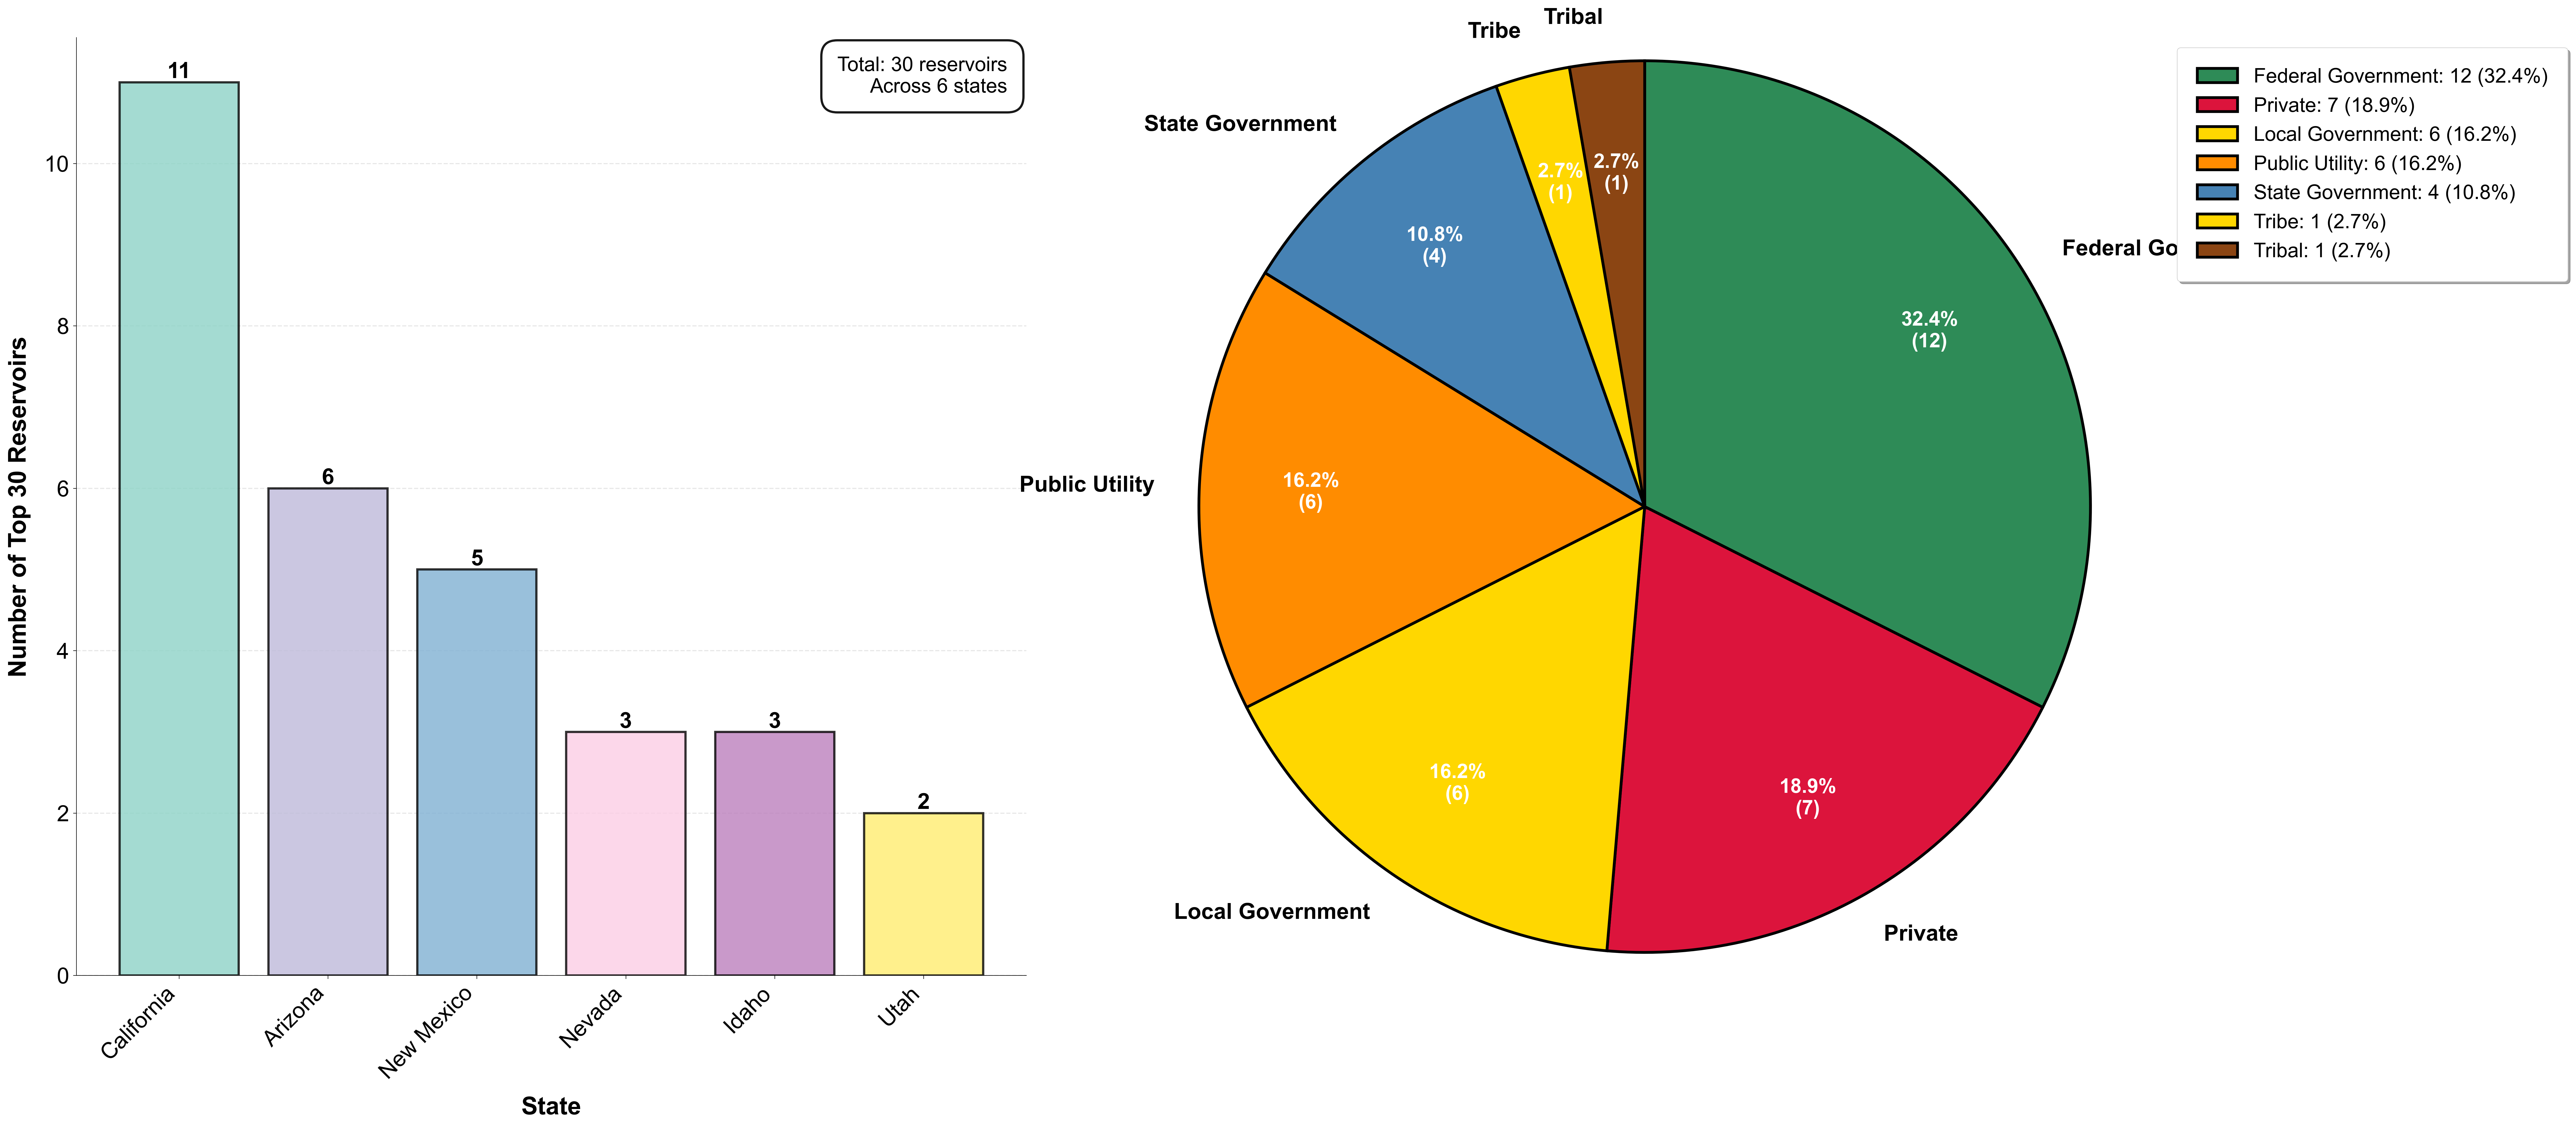


✓ Top 30 analysis completed successfully!
✓ Pie chart shows COUNT of ownership types (NOT scores)


In [27]:
# ========================================================================
# TOP 30 CANDIDATES ANALYSIS: STATE DISTRIBUTION & OWNERSHIP BREAKDOWN
# PIE CHART SHOWS COUNT OF OWNERSHIP TYPES (NOT SCORES!)
# ========================================================================

print("\n" + "="*80)
print("TOP 30 CANDIDATES: STATE & OWNERSHIP ANALYSIS")
print("="*80 + "\n")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ========================================================================
# GET TOP 30 CANDIDATES
# ========================================================================

top_30 = df_ranked.nsmallest(30, 'AHP_Score').copy()
print(f"✓ Selected top 30 candidates based on AHP Score")
print(f"  Score range: {top_30['AHP_Score'].min():.4f} to {top_30['AHP_Score'].max():.4f}\n")

# Display the top 30 list
print("Top 30 Reservoirs:")
print("="*80)
for idx, row in top_30.iterrows():
    rank = int(row['Rank'])
    name = row['Name']
    score = row['AHP_Score']
    state_info = ""
    if 'State' in row.index and pd.notna(row['State']):
        state_info = f" ({row['State']})"
    print(f"  #{rank:2d}. {name:40s} - Score: {score:.4f}{state_info}")
print("="*80 + "\n")

# ========================================================================
# EXTRACT STATE INFORMATION
# ========================================================================

state_col = None
for col in top_30.columns:
    if col.lower() in ['state', 'state_name', 'st', 'state_abbr']:
        state_col = col
        break

if state_col is None:
    print("⚠ No 'State' column found. Attempting to extract from other fields...")
    if has_coords and lat_col and lon_col:
        print("  Attempting to determine states from coordinates...")

        def get_state_from_coords(lat, lon):
            if lon < -114 and lat > 32 and lat < 42:
                return 'California'
            elif lon < -116 and lat > 42 and lat < 46:
                return 'Oregon'
            elif lon < -116 and lat > 45:
                return 'Washington'
            elif lon > -120 and lon < -114 and lat > 35 and lat < 42:
                return 'Nevada'
            elif lon > -114 and lon < -109 and lat > 37 and lat < 42:
                return 'Utah'
            elif lon > -115 and lon < -109 and lat > 31 and lat < 37:
                return 'Arizona'
            elif lon > -109 and lon < -103 and lat > 31 and lat < 37:
                return 'New Mexico'
            elif lon > -109 and lon < -102 and lat > 37 and lat < 41:
                return 'Colorado'
            elif lon > -117 and lon < -111 and lat > 42 and lat < 49:
                return 'Idaho'
            elif lon > -116 and lon < -104 and lat > 45:
                return 'Montana'
            elif lon > -111 and lon < -104 and lat > 41 and lat < 45:
                return 'Wyoming'
            else:
                return 'Unknown'

        top_30['State'] = top_30.apply(lambda row: get_state_from_coords(row[lat_col], row[lon_col]), axis=1)
        state_col = 'State'
        print(f"  ✓ Assigned states based on coordinates\n")
    else:
        top_30['State'] = 'Unknown'
        state_col = 'State'
        print("  ⚠ Could not determine states. Using 'Unknown'\n")
else:
    print(f"✓ Found state column: {state_col}\n")

# ========================================================================
# EXTRACT OWNERSHIP INFORMATION
# ========================================================================

print("\nChecking OwnershipType data...")
if 'OwnershipType' in top_30.columns:
    print(f"✓ Found OwnershipType column")
    print(f"  Unique values: {sorted(top_30['OwnershipType'].dropna().unique())}")
    print(f"  Null count: {top_30['OwnershipType'].isna().sum()}\n")
else:
    print("⚠ OwnershipType column not found — re-join from df_ranked")
    top_30['OwnershipType'] = df_ranked.loc[top_30.index, 'OwnershipType']

# ========================================================================
# PREPARE DATA FOR PLOTS
# ========================================================================

state_counts = top_30[state_col].value_counts().sort_values(ascending=False)

print("State Distribution:")
print("-" * 40)
for state, count in state_counts.items():
    print(f"  {state:30s}: {count:2d} ({count/len(top_30)*100:.1f}%)")
print()

# ========================================================================
# CREATE FIGURE WITH TWO SUBPLOTS
# ========================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(32, 14), facecolor='white')

# ========================================================================
# PLOT 1: STATE DISTRIBUTION (BAR CHART)
# ========================================================================

state_colors = plt.cm.Set3(np.linspace(0, 1, len(state_counts)))

bars = ax1.bar(range(len(state_counts)),
               state_counts.values,
               color=state_colors,
               edgecolor='black',
               linewidth=2,
               alpha=0.8)

# Value labels on bars
for bar, count in zip(bars, state_counts.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(count)}',
             ha='center', va='bottom',
             fontsize=20, fontweight='bold')          # ↑ was 14

ax1.set_xlabel('State', fontsize=22, fontweight='bold', labelpad=12)           # ↑ was 16
ax1.set_ylabel('Number of Top 30 Reservoirs', fontsize=22, fontweight='bold', labelpad=12)  # ↑ was 16

ax1.set_xticks(range(len(state_counts)))
ax1.set_xticklabels(state_counts.index, rotation=45, ha='right', fontsize=20)  # ↑ was 14
ax1.tick_params(axis='y', labelsize=20)                                          # ↑ was 14

ax1.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=1)
ax1.set_axisbelow(True)

total_text = f"Total: {len(top_30)} reservoirs\nAcross {len(state_counts)} states"
ax1.text(0.98, 0.98, total_text,
         transform=ax1.transAxes,
         fontsize=18,                                                             # ↑ was 13
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.8',
                   facecolor='white', edgecolor='black',
                   linewidth=2, alpha=0.9))

# ========================================================================
# PLOT 2: OWNERSHIP TYPE PIE CHART
# ========================================================================

print("\n" + "="*80)
print("CHECKING OWNERSHIP DATA")
print("="*80)
print("\nSample OwnershipType values from top 30:")
print(top_30['OwnershipType'].value_counts())
print("\nUnique OwnershipType values:")
print(top_30['OwnershipType'].unique())
print()

# Map raw OwnershipType strings → (display label, color)
ownership_string_map = {
    'Private':          ('Private',            '#DC143C'),
    'Utility':          ('Public Utility',     '#FF8C00'),
    'PublicUtility':    ('Public Utility',     '#FF8C00'),
    'Public Utility':   ('Public Utility',     '#FF8C00'),
    'LocalGov':         ('Local Government',   '#9370DB'),
    'Local':            ('Local Government',   '#9370DB'),
    'State':            ('State Government',   '#4682B4'),
    'Federal':          ('Federal Government', '#2E8B57'),
    'Tribal':           ('Tribal',             '#8B4513'),
}
MULTI_OWNERSHIP_COLOR = '#FFD700'  # Gold for mixed/multi

print("\n" + "="*80)
print("COUNTING INDIVIDUAL OWNERSHIP TYPES FOR PIE CHART")
print("="*80 + "\n")

ownership_type_counts = {}
ownership_type_colors = {}

for idx, row in top_30.iterrows():
    ownership_raw = row['OwnershipType']

    if pd.isna(ownership_raw):
        continue

    raw_str = str(ownership_raw).strip()

    if raw_str.lower() in ('unknown', ''):
        continue

    # Split comma-separated values e.g. 'Federal, Public Utility, Tribal'
    parts = [p.strip() for p in raw_str.replace(';', ',').split(',')]

    for part in parts:
        if not part:
            continue

        if part in ownership_string_map:
            label, color = ownership_string_map[part]
        elif '_' in part:
            label, color = 'Multi-Ownership', MULTI_OWNERSHIP_COLOR
        else:
            label, color = part, MULTI_OWNERSHIP_COLOR  # fallback

        ownership_type_counts[label] = ownership_type_counts.get(label, 0) + 1
        ownership_type_colors[label] = color

# Sort descending by count
ownership_type_counts = dict(
    sorted(ownership_type_counts.items(), key=lambda x: x[1], reverse=True)
)

print("Individual Ownership Type Counts:")
print("-"*60)
total_ownership_instances = sum(ownership_type_counts.values())
for label, count in ownership_type_counts.items():
    pct = count / total_ownership_instances * 100
    print(f"  {label:30s}: {count:2d} instances ({pct:5.1f}%)")
print("-"*60)
print(f"Total ownership instances: {total_ownership_instances}\n")

pie_labels = list(ownership_type_counts.keys())
pie_values = list(ownership_type_counts.values())
pie_colors = [ownership_type_colors[lbl] for lbl in pie_labels]

print("Creating pie chart with:")
print(f"  Labels: {pie_labels}")
print(f"  Values (COUNTS): {pie_values}")
print(f"  Total: {sum(pie_values)}\n")

wedges, texts, autotexts = ax2.pie(
    pie_values,
    labels=pie_labels,
    colors=pie_colors,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100.*sum(pie_values)))})',
    startangle=90,
    counterclock=False,
    wedgeprops=dict(edgecolor='black', linewidth=2.5),
    textprops=dict(fontsize=20, fontweight='bold'),
    pctdistance=0.75
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(18)
    autotext.set_fontweight('bold')

for text in texts:
    text.set_fontsize(20)
    text.set_fontweight('bold')

legend_labels = [
    f'{lbl}: {cnt} ({cnt/total_ownership_instances*100:.1f}%)'
    for lbl, cnt in ownership_type_counts.items()
]
ax2.legend(legend_labels,
           loc='upper left',
           bbox_to_anchor=(1.05, 1),
           fontsize=18,
           frameon=True,
           fancybox=True,
           shadow=True,
           borderpad=1)

ax2.axis('equal')
# ========================================================================
# SAVE
# ========================================================================

plt.tight_layout()
plt.savefig('Top30_State_Ownership_Analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved: Top30_State_Ownership_Analysis.png\n")
plt.show()

print("\n" + "="*80)
print("✓ Top 30 analysis completed successfully!")
print("✓ Pie chart shows COUNT of ownership types (NOT scores)")
print("="*80)


TOP 5 RESERVOIRS: CRITERIA CONTRIBUTION ANALYSIS

Top 5 Reservoirs:
--------------------------------------------------------------------------------
  # 1. Theodore Roosevelt Dam                   - AHP Score: 3.0107
  # 2. Lake Pleasant                            - AHP Score: 3.3848
  # 3. Davis Dam                                - AHP Score: 3.4455
  # 4. Hoover Dam                               - AHP Score: 3.4824
  # 5. Walker Lake                              - AHP Score: 3.5341
--------------------------------------------------------------------------------

Calculating criteria contributions to AHP scores...

Criteria Contributions to AHP Scores:
Theodore Roosevelt Dam         #   1       3.0107
    Annual evaporation        :   0.1315
    Ice binary                :   0.0893
    max wind ms               :   0.2058
    nearest dist m            :   0.0877
    log Annual solar GWh      :   0.2588
    Capacity Factor           :   0.2122
    HAB flag 20k              :   1.1211


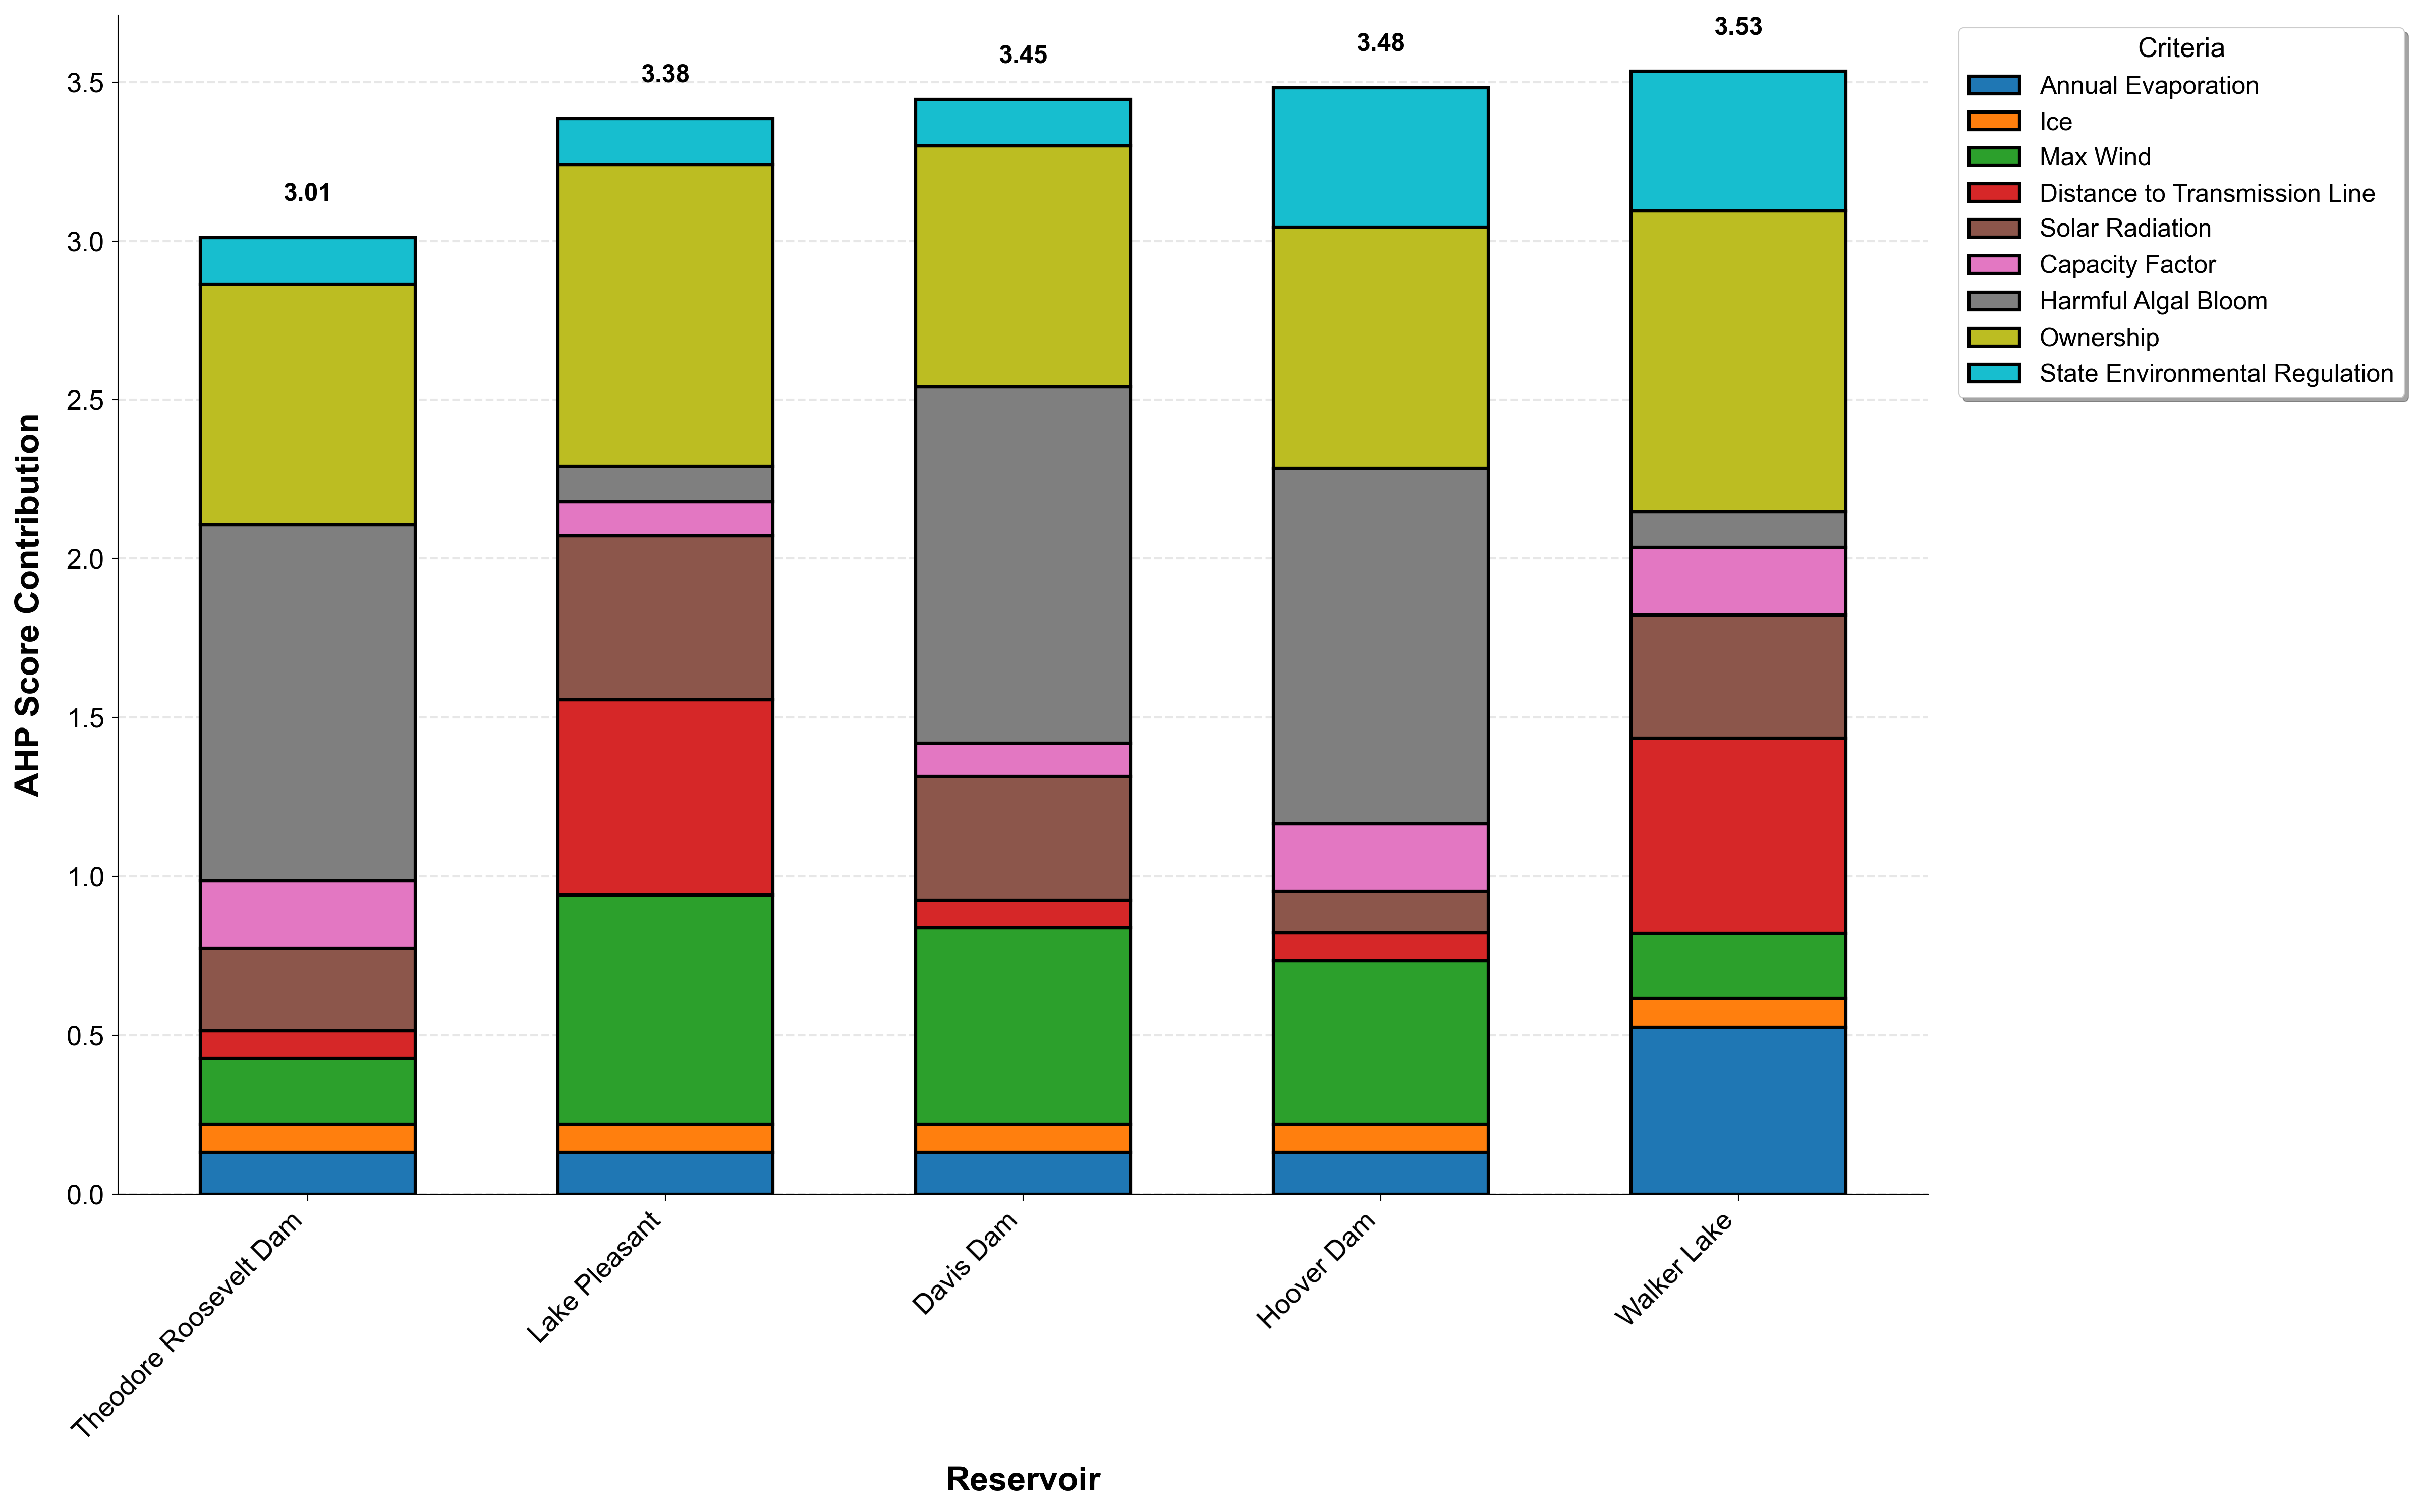

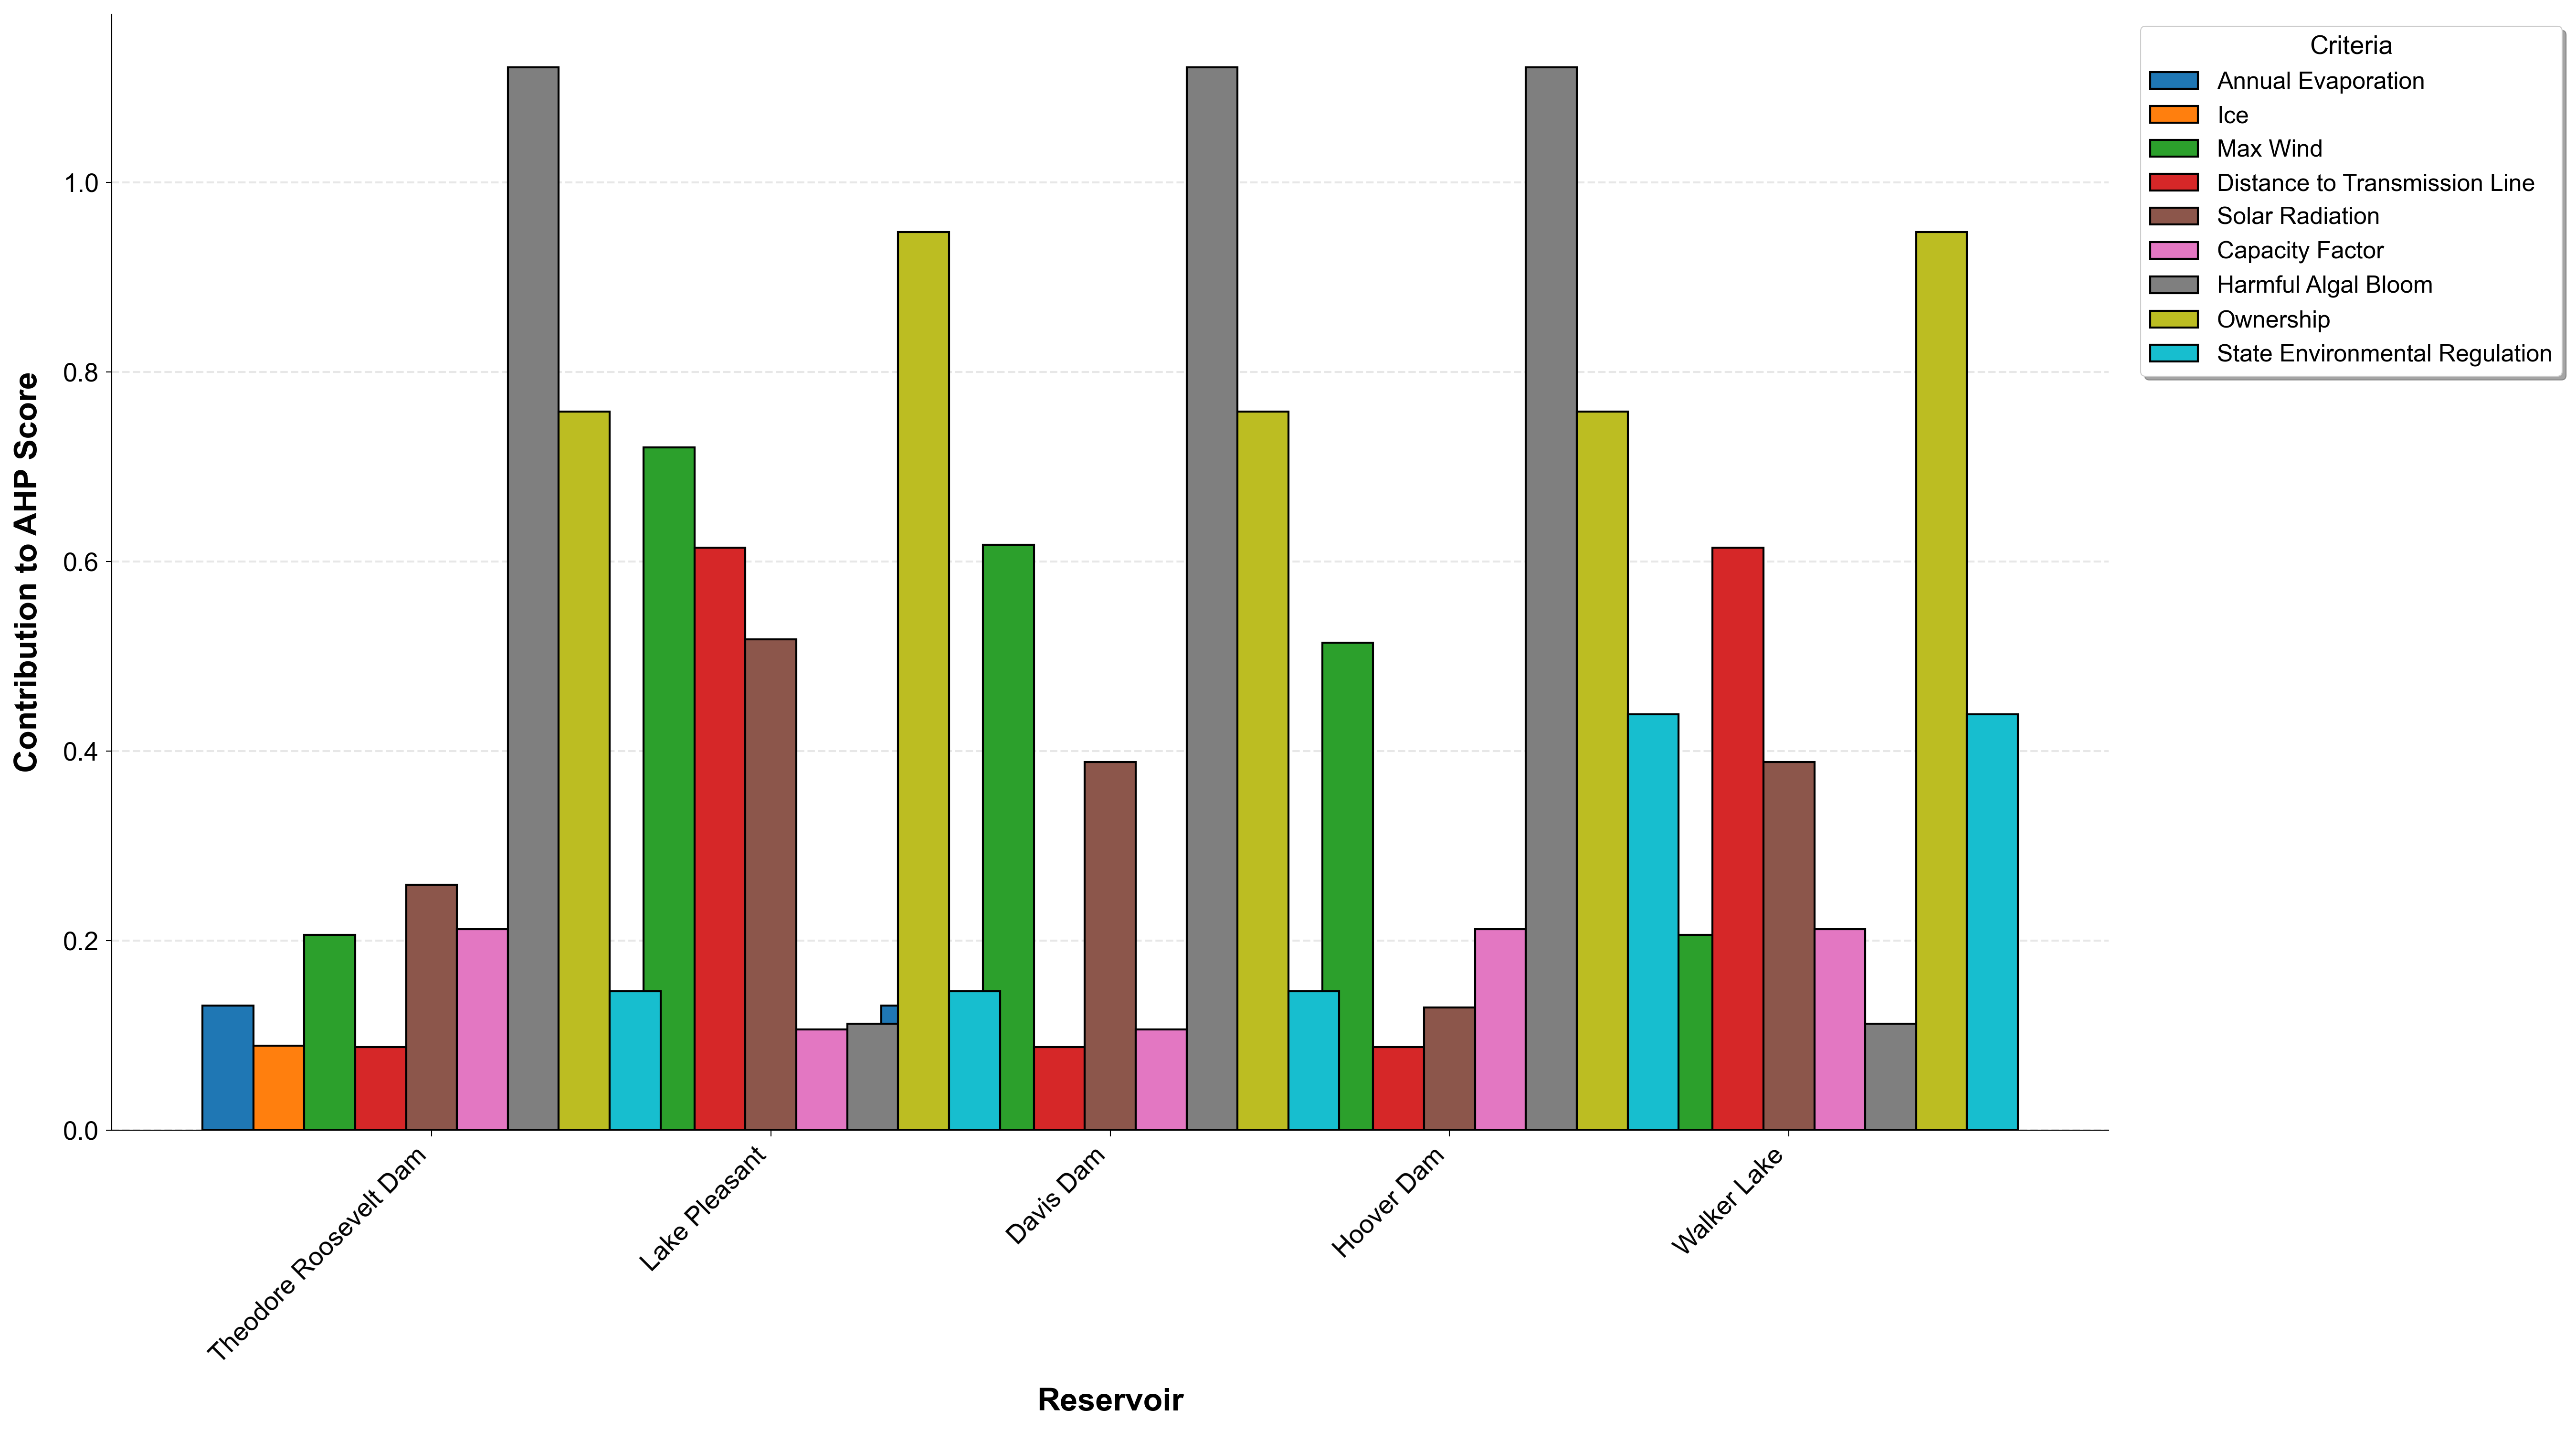

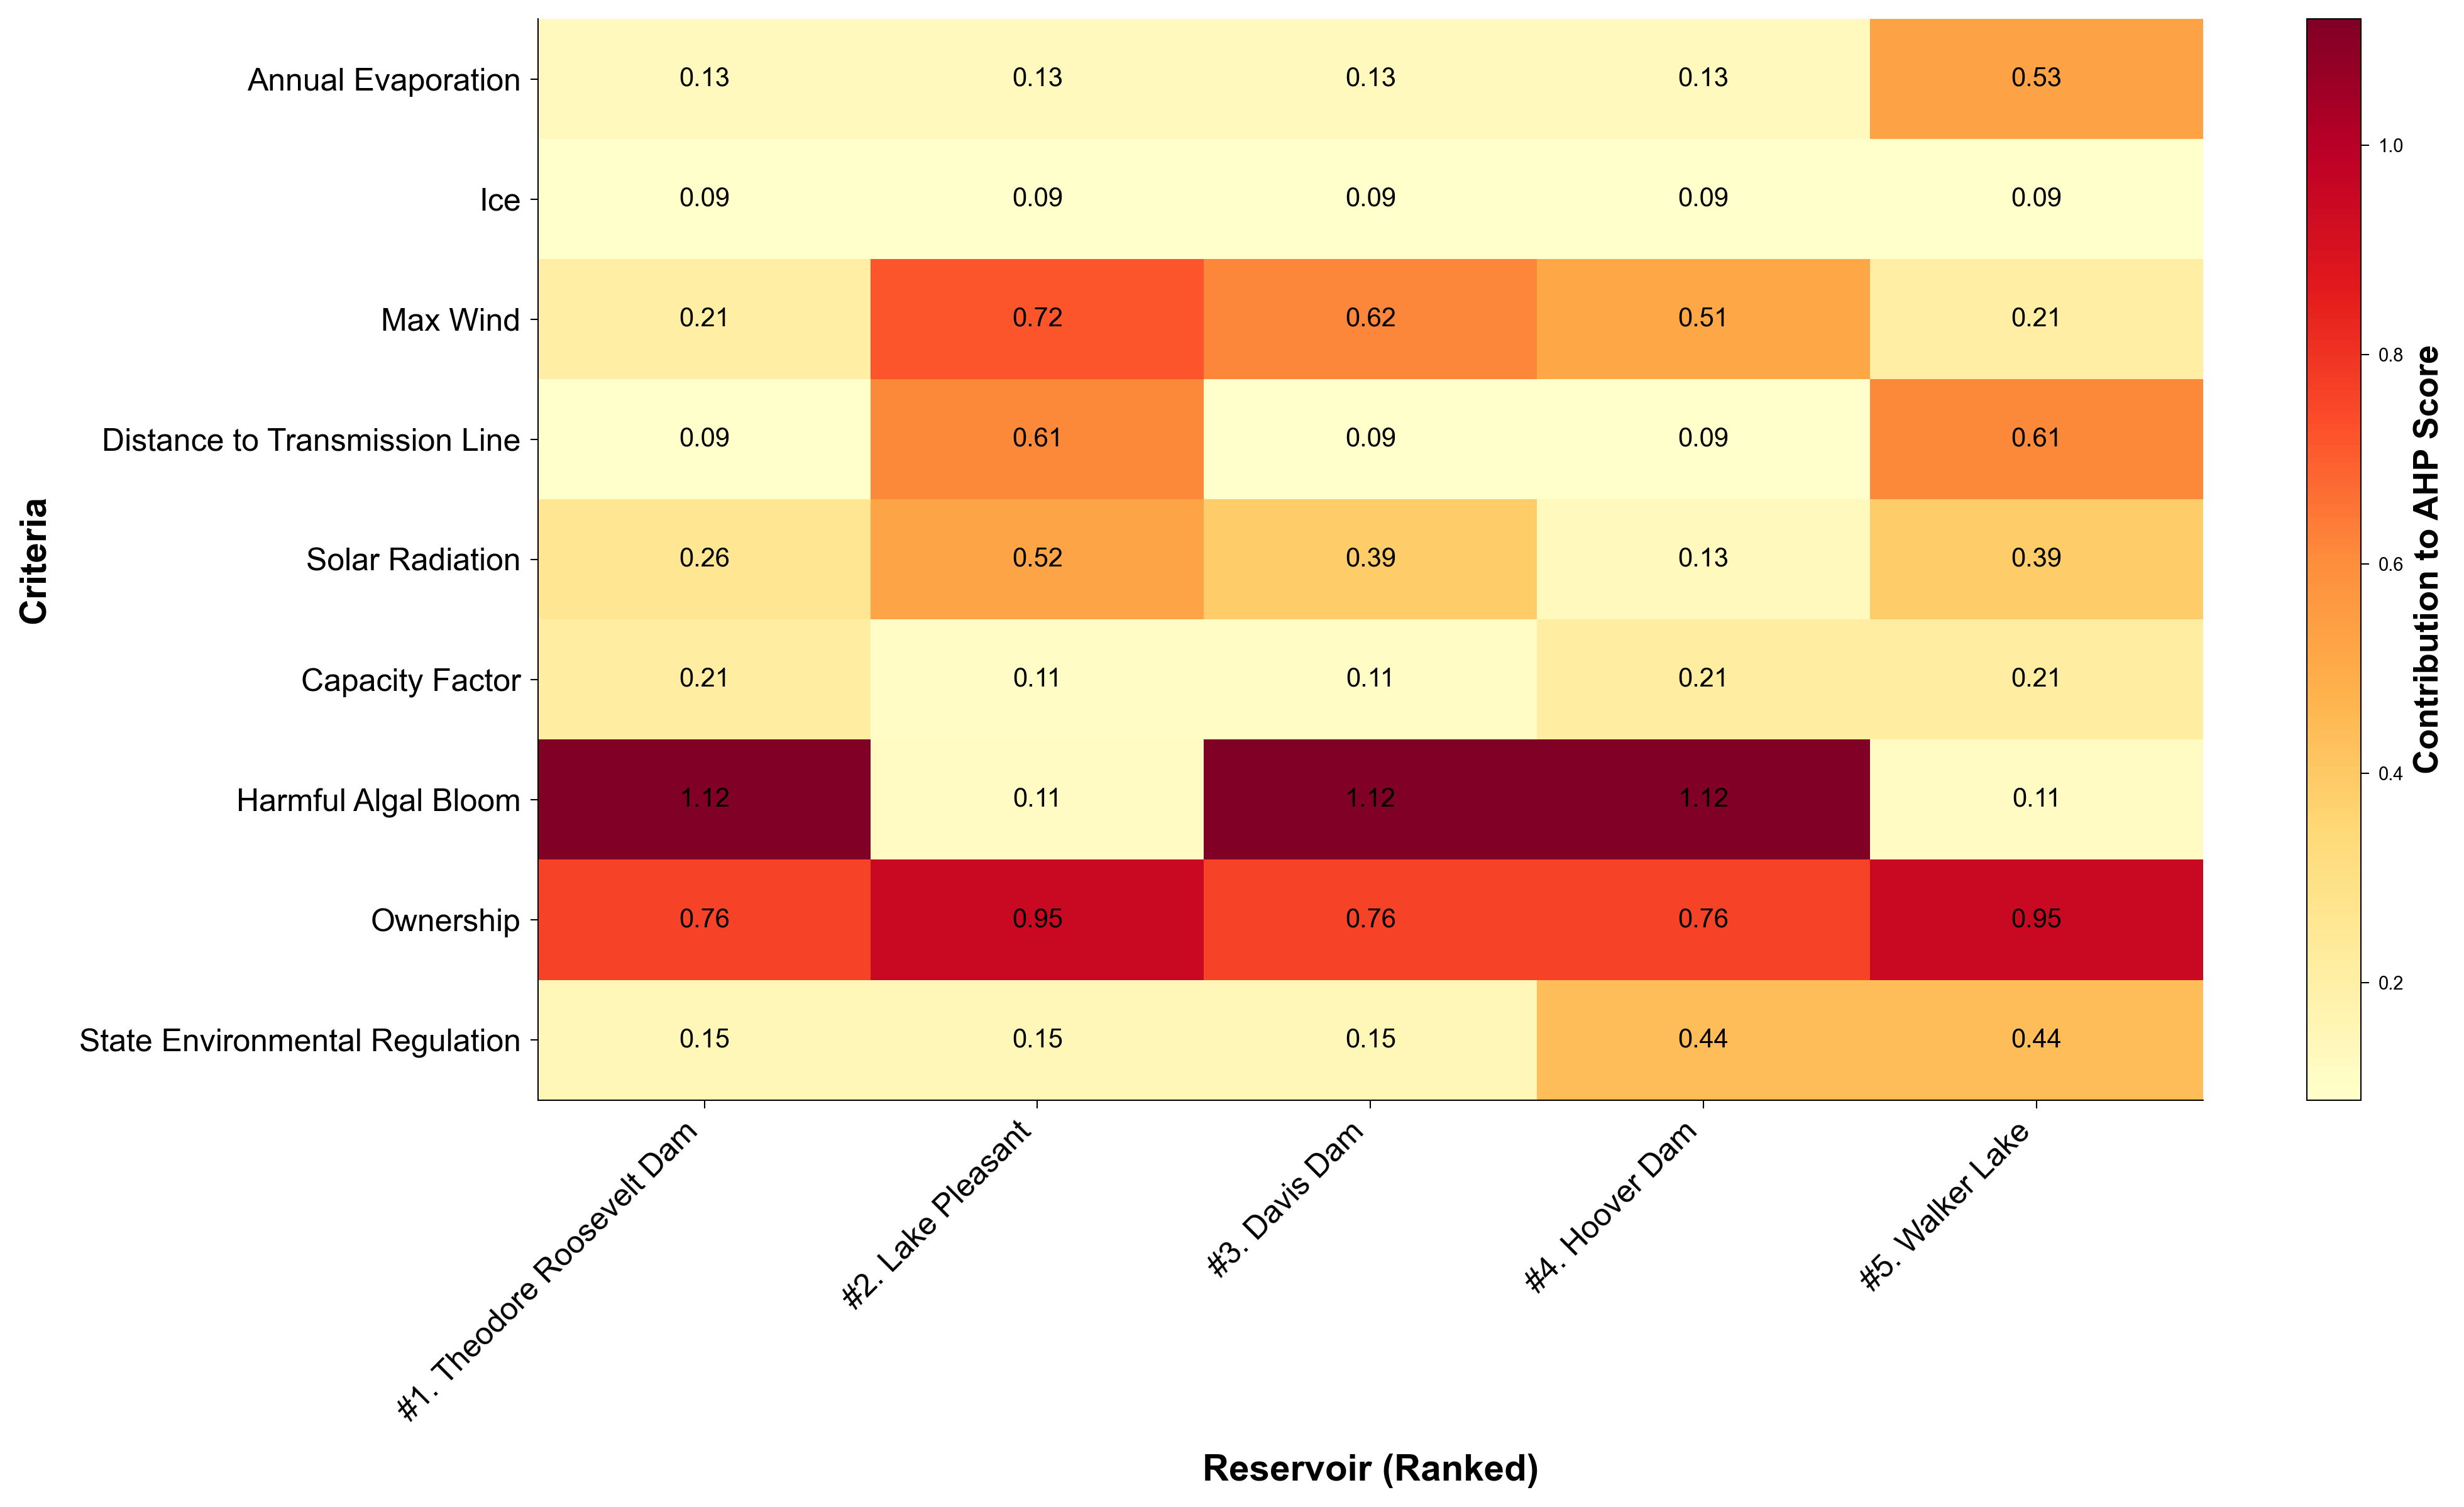


SUMMARY STATISTICS

Average contribution by criterion (across top 5):
--------------------------------------------------------------------------------
  Annual evaporation                 : 0.2104 (weight: 0.1315)
  Ice binary                         : 0.0893 (weight: 0.0893)
  max wind ms                        : 0.4527 (weight: 0.1029)
  nearest dist m                     : 0.2983 (weight: 0.0877)
  log Annual solar GWh               : 0.3365 (weight: 0.1294)
  Capacity Factor                    : 0.1698 (weight: 0.1061)
  HAB flag 20k                       : 0.7175 (weight: 0.1121)
  Ownership                          : 0.8339 (weight: 0.0948)
  State Regulation                   : 0.2633 (weight: 0.1463)

Dominant criteria for each reservoir:
--------------------------------------------------------------------------------
  #1. Theodore Roosevelt Dam
      1. HAB flag 20k                  : 1.1211 (37.2% of total)
      2. Ownership                     : 0.7581 (25.2% of total)
  

In [31]:
# ========================================================================
# TOP 5 RESERVOIRS: CRITERIA CONTRIBUTIONS TO AHP SCORES
# ========================================================================

print("\n" + "="*80)
print("TOP 5 RESERVOIRS: CRITERIA CONTRIBUTION ANALYSIS")
print("="*80 + "\n")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ========================================================================
# GET TOP 5 RESERVOIRS
# ========================================================================

top_5 = df_ranked.nsmallest(5, 'AHP_Score').copy()

print("Top 5 Reservoirs:")
print("-"*80)
for idx, row in top_5.iterrows():
    print(f"  #{int(row['Rank']):2d}. {row['Name']:<40s} - AHP Score: {row['AHP_Score']:.4f}")
print("-"*80 + "\n")

# ========================================================================
# CALCULATE CONTRIBUTION OF EACH CRITERION TO AHP SCORE
# ========================================================================

print("Calculating criteria contributions to AHP scores...\n")

contributions = []

for idx, row in top_5.iterrows():
    reservoir_contributions = {
        'Reservoir':       row['Name'],
        'Rank':            int(row['Rank']),
        'Total_AHP_Score': row['AHP_Score']
    }
    for var in variables:
        category_col = f'{var}_category'
        if category_col in row.index:
            contribution = row[category_col] * weights[var]
            reservoir_contributions[var] = contribution
        else:
            reservoir_contributions[var] = 0
    contributions.append(reservoir_contributions)

df_contributions = pd.DataFrame(contributions)

print("Criteria Contributions to AHP Scores:")
print("="*80)
for idx, row in df_contributions.iterrows():
    print(f"{row['Reservoir'][:28]:<30s} #{row['Rank']:>4.0f} {row['Total_AHP_Score']:>12.4f}")
    for var in variables:
        print(f"    {var.replace('_', ' '):<26s}: {row[var]:>8.4f}")
    print()

# ========================================================================
# PLOT 1: STACKED BAR CHART
# ========================================================================

print("Creating stacked bar chart...\n")

fig, ax = plt.subplots(figsize=(16, 10), facecolor='white')

reservoir_names = [name[:30] for name in df_contributions['Reservoir']]
criterion_names = [
    'Annual Evaporation',               # Annual evaporation
    'Ice',                              # Ice binary
    'Max Wind',                         # max wind ms
    'Distance to Transmission Line',    # nearest dist m
    'Solar Radiation',                  # log Annual solar GWh
    'Capacity Factor',                  # Capacity Factor
    'Harmful Algal Bloom',              # HAB flag 20k
    'Ownership',                        # Ownership
    'State Environmental Regulation',   # State Regulation
]
colors          = plt.cm.tab10(np.linspace(0, 1, len(variables)))

x_positions = np.arange(len(reservoir_names))
bottom      = np.zeros(len(reservoir_names))

for var, color in zip(variables, colors):
    criterion_data = df_contributions[var].values
    ax.bar(x_positions, criterion_data, 0.6,
           bottom=bottom, label=var.replace('_', ' '),
           color=color, edgecolor='black', linewidth=1.5)
    bottom += criterion_data

ax.set_xlabel('Reservoir', fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel('AHP Score Contribution', fontsize=16, fontweight='bold', labelpad=10)
ax.set_xticks(x_positions)
ax.set_xticklabels(reservoir_names, rotation=45, ha='right', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=1, zorder=0)
ax.set_axisbelow(True)
ax.legend(criterion_names,
          loc='upper left', bbox_to_anchor=(1.01, 1),
          fontsize=12, frameon=True, fancybox=True, shadow=True,
          title='Criteria', title_fontsize=13)

for x, total in zip(x_positions, df_contributions['Total_AHP_Score']):
    ax.text(x, total + 0.1, f'{total:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('Top5_Criteria_Contributions_Stacked.png', dpi=300, bbox_inches='tight')
print("✓ Stacked bar chart saved: Top5_Criteria_Contributions_Stacked.png\n")

# ========================================================================
# PLOT 2: GROUPED BAR CHART
# ========================================================================

print("Creating grouped bar chart (alternative view)...\n")

fig2, ax2 = plt.subplots(figsize=(18, 10), facecolor='white')

n_criteria    = len(variables)
bar_width     = 0.12
x_positions   = np.arange(len(reservoir_names)) * 0.8

for i, (var, color) in enumerate(zip(variables, colors)):
    offset = (i - n_criteria/2) * bar_width + bar_width/2
    ax2.bar(x_positions + offset, df_contributions[var].values, bar_width,
            label=var.replace('_', ' '), color=color,
            edgecolor='black', linewidth=1)

ax2.set_xlabel('Reservoir', fontsize=16, fontweight='bold', labelpad=10)
ax2.set_ylabel('Contribution to AHP Score', fontsize=16, fontweight='bold', labelpad=10)
ax2.set_xticks(x_positions)
ax2.set_xticklabels(reservoir_names, rotation=45, ha='right', fontsize=13)
ax2.tick_params(axis='y', labelsize=13)
ax2.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=1, zorder=0)
ax2.set_axisbelow(True)
ax2.legend(criterion_names,
           loc='upper left', bbox_to_anchor=(1.01, 1),
           fontsize=12, frameon=True, fancybox=True, shadow=True,
           title='Criteria', title_fontsize=13)

plt.tight_layout()
plt.savefig('Top5_Criteria_Contributions_Grouped.png', dpi=300, bbox_inches='tight')
print("✓ Grouped bar chart saved: Top5_Criteria_Contributions_Grouped.png\n")

# ========================================================================
# PLOT 3: HEATMAP
# ========================================================================

print("Creating heatmap visualization...\n")

fig3, ax3 = plt.subplots(figsize=(14, 8), facecolor='white')

heatmap_data      = df_contributions[variables].values
reservoir_labels  = [f"#{int(r['Rank'])}. {r['Reservoir'][:25]}"
                     for _, r in df_contributions.iterrows()]

im   = ax3.imshow(heatmap_data.T, cmap='YlOrRd', aspect='auto')
cbar = plt.colorbar(im, ax=ax3)
cbar.set_label('Contribution to AHP Score', fontsize=13, fontweight='bold')

ax3.set_xticks(np.arange(len(reservoir_labels)))
ax3.set_yticks(np.arange(len(criterion_names)))
ax3.set_xticklabels(reservoir_labels, rotation=45, ha='right', fontsize=12)
ax3.set_yticklabels(criterion_names, fontsize=12)
ax3.set_xlabel('Reservoir (Ranked)', fontsize=14, fontweight='bold', labelpad=10)
ax3.set_ylabel('Criteria',           fontsize=14, fontweight='bold', labelpad=10)

for i in range(len(criterion_names)):
    for j in range(len(reservoir_labels)):
        ax3.text(j, i, f'{heatmap_data[j, i]:.2f}',
                 ha='center', va='center', color='black', fontsize=10)

plt.tight_layout()
plt.savefig('Top5_Criteria_Contributions_Heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Heatmap saved: Top5_Criteria_Contributions_Heatmap.png\n")

plt.show()

# ========================================================================
# SUMMARY STATISTICS
# ========================================================================

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80 + "\n")

print("Average contribution by criterion (across top 5):")
print("-"*80)
for var in variables:
    print(f"  {var.replace('_', ' '):<35s}: {df_contributions[var].mean():.4f} (weight: {weights[var]:.4f})")
print()

print("Dominant criteria for each reservoir:")
print("-"*80)
for idx, row in df_contributions.iterrows():
    top_3 = sorted({var: row[var] for var in variables}.items(),
                   key=lambda x: x[1], reverse=True)[:3]
    print(f"  #{int(row['Rank'])}. {row['Reservoir'][:35]}")
    for i, (var, contrib) in enumerate(top_3, 1):
        pct = (contrib / row['Total_AHP_Score']) * 100
        print(f"      {i}. {var.replace('_', ' '):<30s}: {contrib:.4f} ({pct:.1f}% of total)")
    print()

print("="*80)
print("✓ Analysis complete!")
print("="*80)

In [30]:
print(criterion_names)

['Annual evaporation', 'Ice binary', 'max wind ms', 'nearest dist m', 'log Annual solar GWh', 'Capacity Factor', 'HAB flag 20k', 'Ownership', 'State Regulation']


In [29]:
# ============================================================================
# DIAGNOSTIC: OWNERSHIP SCORING FOR TOP 5 RESERVOIRS
# ============================================================================

print("\n" + "="*80)
print("DIAGNOSTIC: OWNERSHIP CATEGORIZATION CHECK")
print("="*80 + "\n")

import pandas as pd

# ============================================================================
# CHECK TOP 5 RESERVOIRS
# ============================================================================

top_5 = df_ranked.nsmallest(5, 'AHP_Score').copy()

print("TOP 5 RESERVOIRS - OWNERSHIP ANALYSIS:")
print("="*80 + "\n")

for idx, row in top_5.iterrows():
    print(f"{'='*80}")
    print(f"#{int(row['Rank'])}. {row['Name']}")
    print(f"Total AHP Score: {row['AHP_Score']:.4f}")
    print(f"{'='*80}")
    
    # Get ownership information
    print("\nOWNERSHIP DATA:")
    print("-"*80)
    
    # Check if there's a raw ownership column
    if 'Ownership' in row.index:
        ownership_raw = row['Ownership']
        print(f"  Raw Ownership Value:      {ownership_raw}")
        print(f"  Raw Ownership Type:       {type(ownership_raw).__name__}")
    
    # Check ownership category
    if 'Ownership_category' in row.index:
        ownership_category = row['Ownership_category']
        print(f"  Ownership Category:       {ownership_category} (1=best, 10=worst)")
    else:
        print("  ⚠ WARNING: No Ownership_category column found!")
        ownership_category = None
    
    # Calculate ownership contribution
    if ownership_category is not None:
        ownership_weight = weights.get('Ownership', 0)
        ownership_contribution = ownership_category * ownership_weight
        contribution_pct = (ownership_contribution / row['AHP_Score']) * 100
        
        print(f"\nOWNERSHIP CONTRIBUTION CALCULATION:")
        print("-"*80)
        print(f"  Ownership Category:       {ownership_category}")
        print(f"  × Ownership Weight:       {ownership_weight:.4f}")
        print(f"  = Contribution:           {ownership_contribution:.4f}")
        print(f"  % of Total AHP Score:     {contribution_pct:.1f}%")
        
        # Determine if this is appropriate
        print(f"\nINTERPRETATION:")
        print("-"*80)
        
        if ownership_raw == 0 or ownership_raw == 'Federal':
            if ownership_category <= 2:
                print(f"  ✓ CORRECT: Federal ownership has low category ({ownership_category}) = good")
            else:
                print(f"  ✗ PROBLEM: Federal ownership has high category ({ownership_category}) = bad")
                print(f"    This seems WRONG - Federal should be favorable (category 1-2)")
        elif ownership_raw == 4 or ownership_raw == 'LocalGov':
            if ownership_category >= 6:
                print(f"  ✓ CORRECT: LocalGov ownership has high category ({ownership_category}) = less favorable")
            else:
                print(f"  ? LocalGov ownership has low category ({ownership_category})")
    
    print("\n")

# ============================================================================
# CHECK OWNERSHIP MAPPING
# ============================================================================

print("\n" + "="*80)
print("OWNERSHIP TYPE MAPPING ANALYSIS")
print("="*80 + "\n")

print("Checking how ownership values map to categories...\n")

# Get unique ownership values and their corresponding categories
ownership_mapping_check = df_ranked[['Ownership', 'Ownership_category']].drop_duplicates().sort_values('Ownership')

print("OWNERSHIP VALUE → CATEGORY MAPPING:")
print("-"*80)
print(f"{'Ownership Value':<30s} {'Category':<15s} {'Interpretation':<30s}")
print("-"*80)

for idx, row in ownership_mapping_check.iterrows():
    ownership_val = row['Ownership']
    category = row['Ownership_category']
    
    # Interpret
    if category <= 2:
        interp = "Excellent (most favorable)"
    elif category <= 4:
        interp = "Good"
    elif category <= 6:
        interp = "Fair"
    elif category <= 8:
        interp = "Poor"
    else:
        interp = "Worst (least favorable)"
    
    # Try to decode numeric ownership
    if isinstance(ownership_val, (int, float)):
        ownership_display = f"{int(ownership_val)} (numeric)"
    else:
        ownership_display = str(ownership_val)
    
    print(f"{ownership_display:<30s} {category:<15.0f} {interp:<30s}")

print("-"*80 + "\n")

# ============================================================================
# CHECK IF CATEGORIZATION IS INVERTED
# ============================================================================

print("="*80)
print("CHECKING IF OWNERSHIP CATEGORIZATION IS INVERTED")
print("="*80 + "\n")

# Hypothesis: Maybe ownership was categorized with higher_is_better=False when it should be True
# Or the numeric codes are backwards

print("Expected behavior:")
print("  Federal (0) → Should be BEST (category 1-2)")
print("  State (1) → Should be GOOD (category 2-3)")
print("  Private (2) → Should be WORSE (category 5-7)")
print("  Utility (3) → Should be FAIR (category 4-5)")
print("  LocalGov (4) → Should be WORSE (category 6-8)")
print("  Tribal (5) → Should be variable")
print()

# Check actual pattern
print("Actual pattern in data:")
print("-"*80)

for ownership_val in sorted(df_ranked['Ownership'].unique()):
    subset = df_ranked[df_ranked['Ownership'] == ownership_val]
    avg_category = subset['Ownership_category'].mean()
    count = len(subset)
    
    # Decode numeric
    ownership_names = {
        0: 'Federal',
        1: 'State', 
        2: 'Private',
        3: 'Utility',
        4: 'LocalGov',
        5: 'Tribal',
        6: 'Federal_State',
        7: 'Private_Utility'
    }
    
    if isinstance(ownership_val, (int, float)):
        ownership_display = f"{int(ownership_val)} ({ownership_names.get(int(ownership_val), 'Unknown')})"
    else:
        ownership_display = str(ownership_val)
    
    print(f"  {ownership_display:<30s}: Avg Category = {avg_category:.2f} (n={count})")

print("-"*80 + "\n")

# ============================================================================
# IDENTIFY THE PROBLEM
# ============================================================================

print("="*80)
print("DIAGNOSIS")
print("="*80 + "\n")

# Check if Federal has high categories
federal_sites = df_ranked[df_ranked['Ownership'] == 0]  # Assuming 0 = Federal
if len(federal_sites) > 0:
    federal_avg_cat = federal_sites['Ownership_category'].mean()
    
    if federal_avg_cat > 5:
        print("⚠ PROBLEM IDENTIFIED!")
        print("-"*80)
        print(f"Federal ownership sites have average category = {federal_avg_cat:.2f}")
        print("This is HIGH (bad), but Federal should be LOW (good)!")
        print()
        print("LIKELY CAUSE:")
        print("  The ownership categorization may be using 'higher_is_better=True'")
        print("  when it should be 'higher_is_better=False' (or vice versa)")
        print()
        print("SOLUTION:")
        print("  Need to check Step 3 where Ownership is categorized")
        print("  Look for: categorize_variable(df['Ownership'], higher_is_better=???)")
        print()
        
    elif federal_avg_cat < 3:
        print("✓ Federal ownership categorization looks CORRECT")
        print(f"  Average category = {federal_avg_cat:.2f} (low = good)")
        print()
        print("If ownership still contributes a lot, it's because:")
        print("  Even a good score (category 2) × weight (0.101) = noticeable contribution")
        print("  This is NORMAL and OK!")

# ============================================================================
# DETAILED BREAKDOWN FOR EACH TOP 5
# ============================================================================

print("\n" + "="*80)
print("DETAILED BREAKDOWN: ALL CRITERIA FOR TOP 5")
print("="*80 + "\n")

for idx, row in top_5.iterrows():
    print(f"\n{'='*80}")
    print(f"#{int(row['Rank'])}. {row['Name']} - Total Score: {row['AHP_Score']:.4f}")
    print(f"{'='*80}")
    print(f"{'Criterion':<30s} {'Weight':>8s} {'Category':>10s} {'Contribution':>13s} {'% of Score':>12s}")
    print("-"*80)
    
    contributions = []
    for var in variables:
        category_col = f'{var}_category'
        if category_col in row.index:
            weight = weights[var]
            category = row[category_col]
            contribution = category * weight
            pct = (contribution / row['AHP_Score']) * 100
            
            contributions.append({
                'var': var,
                'weight': weight,
                'category': category,
                'contribution': contribution,
                'pct': pct
            })
            
            # Highlight ownership
            if var == 'Ownership':
                marker = " ← OWNERSHIP"
            else:
                marker = ""
            
            print(f"{var.replace('_', ' '):<30s} {weight:>7.4f} {category:>8.0f}/10 {contribution:>10.4f} {pct:>10.1f}%{marker}")
    
    # Sort by contribution
    contributions.sort(key=lambda x: x['contribution'], reverse=True)
    
    print("\nRanked by contribution:")
    for i, c in enumerate(contributions[:5], 1):
        print(f"  {i}. {c['var'].replace('_', ' '):<30s}: {c['contribution']:.4f} ({c['pct']:.1f}%)")

print("\n" + "="*80)
print("✓ Diagnostic Complete!")
print("="*80)


DIAGNOSTIC: OWNERSHIP CATEGORIZATION CHECK

TOP 5 RESERVOIRS - OWNERSHIP ANALYSIS:

#1. Theodore Roosevelt Dam
Total AHP Score: 3.0107

OWNERSHIP DATA:
--------------------------------------------------------------------------------
  Raw Ownership Value:      5
  Raw Ownership Type:       int
  Ownership Category:       8 (1=best, 10=worst)

OWNERSHIP CONTRIBUTION CALCULATION:
--------------------------------------------------------------------------------
  Ownership Category:       8
  × Ownership Weight:       0.0948
  = Contribution:           0.7581
  % of Total AHP Score:     25.2%

INTERPRETATION:
--------------------------------------------------------------------------------


#2. Lake Pleasant
Total AHP Score: 3.3848

OWNERSHIP DATA:
--------------------------------------------------------------------------------
  Raw Ownership Value:      8
  Raw Ownership Type:       int
  Ownership Category:       10 (1=best, 10=worst)

OWNERSHIP CONTRIBUTION CALCULATION:
--------------